In [1]:
# ============================================================
# User settings
# ============================================================

TARGET_DATE = "2026-06-18"

# Treat only completed orders as actually done.
INCLUDE_STATUSES = {"completed"}

# Demand quantity rule
USE_PRODUCED_QUANTITY_IF_AVAILABLE = False

# Contract minimum demand rule
MIN_DEMAND_FRACTION = 0.60

# Default values for fields not available in the JSON
DEFAULT_PRINTING_REQUIREMENT = 0
DEFAULT_UNMET_DEMAND_PENALTY = 2

# Stable machine settings
NUM_LANES = 18
C_lane = 1250
C_grader = 25000

# Planning horizon.

T = list(range(1, 97))  # 96 time periods
T_end = list(range(1, 97))




# ============================================================
# Read supplier count CSV
# ============================================================
# S B S(BK)

import pandas as pd
from pathlib import Path
import gurobipy as gp
from gurobipy import GRB
from itertools import product
import time

supplier_file = Path("SupplierCountResults18June2026.csv")

supplier_raw = pd.read_csv(
    supplier_file,
    na_values=["NULL"]
)

# Parse date columns where available
date_columns = [
    "StiCreatedDate",
    "StiModifiedDate",
    "HscStartDate",
    "HscEndDate",
]

for col in date_columns:
    if col in supplier_raw.columns:
        supplier_raw[col] = pd.to_datetime(
            supplier_raw[col],
            errors="coerce"
        )

print("Supplier count file loaded.")
print(f"Rows:    {len(supplier_raw):,}")
print(f"Columns: {len(supplier_raw.columns):,}")
print(f"File:    {supplier_file}")


# ============================================================
# Aggregate raw supplier names into canonical supplier groups
# ============================================================

CANONICAL_SUPPLIERS = [
    "Farm Kelbra",
    "Geflügel Siemers Steinfel",
    "Geflügelfarm Welbsleben",
    "Hühnerhof Lohse",
    "Hühnerhof Quenstedt",
    "Hühnerhof Steuden",
    "Rainer Becker",
]

# Optional aliases make the matching a little more robust. (ChatGPT code!)
SUPPLIER_ALIASES = {
    "Farm Kelbra": [
        "Farm Kelbra",
    ],
    "Geflügel Siemers Steinfel": [
        "Geflügel Siemers Steinfel",
        "Gefluegel Siemers Steinfel",
    ],
    "Geflügelfarm Welbsleben": [
        "Geflügelfarm Welbsleben",
        "Gefluegelfarm Welbsleben",
    ],
    "Hühnerhof Lohse": [
        "Hühnerhof Lohse",
        "Huehnerhof Lohse",
    ],
    "Hühnerhof Quenstedt": [
        "Hühnerhof Quenstedt",
        "Huehnerhof Quenstedt",
    ],
    "Hühnerhof Steuden": [
        "Hühnerhof Steuden",
        "Huehnerhof Steuden",
    ],
    "Rainer Becker": [
        "Rainer Becker",
    ],
}


def map_to_supplier_group(raw_supplier_name):
    """
    Map the raw supplier/barn name from the CSV to one canonical supplier group.
    Raises an error if no match or multiple matches are found.
    """
    if pd.isna(raw_supplier_name):
        return None

    text = str(raw_supplier_name).casefold()

    matches = []

    for canonical_supplier, aliases in SUPPLIER_ALIASES.items():
        for alias in aliases:
            if alias.casefold() in text:
                matches.append(canonical_supplier)
                break

    matches = list(dict.fromkeys(matches))  # remove duplicates while preserving order

    if len(matches) == 1:
        return matches[0]

    if len(matches) == 0:
        return None

    raise ValueError(
        f"Ambiguous supplier mapping for raw supplier name "
        f"'{raw_supplier_name}'. Matches found: {matches}"
    )


supplier_raw["SupplierGroup"] = supplier_raw["StiSupplierName"].apply(
    map_to_supplier_group
)


# ------------------------------------------------------------
# Validate supplier mapping
# ------------------------------------------------------------

unmapped_suppliers = (
    supplier_raw.loc[
        supplier_raw["SupplierGroup"].isna(),
        "StiSupplierName"
    ]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

if unmapped_suppliers:
    raise ValueError(
        "Some supplier names could not be mapped to a canonical supplier group:\n"
        + "\n".join(f"- {supplier}" for supplier in unmapped_suppliers)
    )

invalid_supplier_groups = sorted(
    set(supplier_raw["SupplierGroup"].dropna()) - set(CANONICAL_SUPPLIERS)
)

if invalid_supplier_groups:
    raise ValueError(
        "Invalid supplier groups found:\n"
        + "\n".join(f"- {supplier}" for supplier in invalid_supplier_groups)
    )


# ------------------------------------------------------------
# Show raw-to-canonical mapping
# ------------------------------------------------------------

supplier_mapping_overview = (
    supplier_raw[["StiSupplierName", "SupplierGroup"]]
    .drop_duplicates()
    .sort_values(["SupplierGroup", "StiSupplierName"])
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("SUPPLIER MAPPING OVERVIEW")
print("=" * 80)

try:
    from IPython.display import display
    display(supplier_mapping_overview)
except Exception:
    print(supplier_mapping_overview.to_string(index=False))




# ============================================================
# Transform supplier count data into model supply input
# ============================================================

# Use HsdCount/HsdGradeName as the main grading result.

COUNT_COLUMN = "HsdCount"
GRADE_COLUMN = "HsdGradeName"

# Map supplier-count grades to the quality classes used in the model.
# The file does not contain all 9 size classes, so missing classes receive zero supply.
CSV_GRADE_TO_MODEL_SIZE = {
    "Small": "S",
    "Medi":  "M",
    "Large": "L",
    "XLarg": "XL",
    "XXL":   "XXL",
}

DEFECT_GRADES = [
    "Reject",
    "Crack",
    "Dirt",
    "Leakr",
    "Blood",
]

# Use compact real data size classes.
# These match the new JSON _size entries better than the old 9 fictitious classes.
K = ["S", "M", "L", "XL", "XXL"]

# ============================================================
# Create model batches aggregated by raw supplier name
# ============================================================
# One model batch per raw supplier name, not per StiId.
# Multiple pallets / stock items with different StiIds can therefore belong
# to the same model batch.
# ============================================================

# ------------------------------------------------------------
# Validate that raw supplier names are available
# ------------------------------------------------------------

if "StiSupplierName" not in supplier_raw.columns:
    raise ValueError("CSV is missing column 'StiSupplierName'.")

missing_raw_supplier_rows = supplier_raw[
    supplier_raw["StiSupplierName"].isna()
]

if len(missing_raw_supplier_rows) > 0:
    raise ValueError(
        f"{len(missing_raw_supplier_rows)} rows have missing StiSupplierName."
    )


# ------------------------------------------------------------
# Helper for compact metadata strings
# ------------------------------------------------------------

def unique_join(values):
    cleaned = [
        str(v)
        for v in values
        if pd.notna(v)
    ]

    return ", ".join(sorted(set(cleaned)))


# ------------------------------------------------------------
# Create one batch row per raw supplier name
# ------------------------------------------------------------

supplier_batches = (
    supplier_raw
    .groupby("StiSupplierName", as_index=False)
    .agg(
        SupplierGroup=("SupplierGroup", lambda x: unique_join(x)),
        StiIds=("StiId", unique_join),
        StiNumbers=("StiNumber", unique_join),
        StiDescriptions=("StiDescription", unique_join),
        StiSupplierNumbers=("StiSupplierNumber", unique_join),
        SuiIds=("SuiId", unique_join),
        SuiNames=("SuiName", unique_join),
        HscStartDate=("HscStartDate", "min"),
        HscEndDate=("HscEndDate", "max"),
    )
    .sort_values("StiSupplierName")
    .reset_index(drop=True)
)

B = [
    f"B{i+1}"
    for i in range(len(supplier_batches))
]

raw_supplier_to_batch = {
    row["StiSupplierName"]: B[i]
    for i, row in supplier_batches.iterrows()
}

batch_to_raw_supplier = {
    b: raw_supplier
    for raw_supplier, b in raw_supplier_to_batch.items()
}


# ------------------------------------------------------------
# Keep a StiId-to-batch mapping for compatibility with other code
# ------------------------------------------------------------
# Several StiIds may map to the same batch now.
# ------------------------------------------------------------

stiid_to_batch = {}

for _, row in supplier_raw[["StiId", "StiSupplierName"]].drop_duplicates().iterrows():
    stiid = row["StiId"]
    raw_supplier = row["StiSupplierName"]

    stiid_to_batch[stiid] = raw_supplier_to_batch[raw_supplier]

batch_to_stiids = {
    b: sorted(
        supplier_raw.loc[
            supplier_raw["StiSupplierName"] == batch_to_raw_supplier[b],
            "StiId"
        ]
        .dropna()
        .drop_duplicates()
        .tolist()
    )
    for b in B
}


# ------------------------------------------------------------
# Metadata dictionary for reporting and traceability
# ------------------------------------------------------------

batch_metadata = {}

for i, row in supplier_batches.iterrows():
    b = B[i]

    batch_metadata[b] = {
        # Main aggregation key
        "RawSupplierName": row["StiSupplierName"],

        # Canonical supplier group, still useful for compatibility checks
        "SupplierGroup": row["SupplierGroup"],

        # Aggregated pallet / stock-item metadata
        "StiIds": row["StiIds"],
        "StiNumbers": row["StiNumbers"],
        "StiDescriptions": row["StiDescriptions"],
        "StiSupplierNumbers": row["StiSupplierNumbers"],
        "SuiIds": row["SuiIds"],
        "SuiNames": row["SuiNames"],
        "HscStartDate": row["HscStartDate"],
        "HscEndDate": row["HscEndDate"],

        # Optional compatibility aliases, in case older reporting code expects these
        "StiId": row["StiIds"],
        "StiNumber": row["StiNumbers"],
        "StiDescription": row["StiDescriptions"],
        "StiSupplierNumber": row["StiSupplierNumbers"],
        "SuiId": row["SuiIds"],
        "SuiName": row["SuiNames"],
    }


# ------------------------------------------------------------
# Validate that every raw-supplier batch has exactly one canonical group
# ------------------------------------------------------------

invalid_supplier_group_rows = []

for b in B:
    supplier_group_text = batch_metadata[b]["SupplierGroup"]

    supplier_groups = [
        s.strip()
        for s in supplier_group_text.split(",")
        if s.strip()
    ]

    if len(supplier_groups) != 1:
        invalid_supplier_group_rows.append(
            (b, batch_metadata[b]["RawSupplierName"], supplier_groups)
        )

    elif supplier_groups[0] not in CANONICAL_SUPPLIERS:
        invalid_supplier_group_rows.append(
            (b, batch_metadata[b]["RawSupplierName"], supplier_groups)
        )

    else:
        # Store as clean scalar string instead of comma-joined text
        batch_metadata[b]["SupplierGroup"] = supplier_groups[0]

if invalid_supplier_group_rows:
    raise ValueError(
        "Some raw-supplier batches do not map to exactly one valid canonical supplier group:\n"
        + "\n".join(str(row) for row in invalid_supplier_group_rows)
    )

print("Batch supplier groups created successfully.")
print(f"Number of raw-supplier batches: {len(B)}")


# ============================================================
# Initialize and fill model supply S[b,k]
# ============================================================

S = {
    (b, k): 0
    for b in B
    for k in K
}

defect_counts_by_batch = {
    b: {
        defect_grade: 0
        for defect_grade in DEFECT_GRADES
    }
    for b in B
}


# ------------------------------------------------------------
# Add all egg counts from all pallets / StiIds belonging to each raw supplier
# ------------------------------------------------------------

for _, row in supplier_raw.iterrows():
    raw_supplier = row["StiSupplierName"]
    b = raw_supplier_to_batch[raw_supplier]

    raw_grade = row[GRADE_COLUMN]
    count = row[COUNT_COLUMN]

    if pd.isna(raw_grade) or pd.isna(count):
        continue

    count = int(round(count))

    if raw_grade in CSV_GRADE_TO_MODEL_SIZE:
        k = CSV_GRADE_TO_MODEL_SIZE[raw_grade]
        S[(b, k)] += count

    elif raw_grade in DEFECT_GRADES:
        defect_counts_by_batch[b][raw_grade] += count


# ------------------------------------------------------------
# eta[b] is not available in the CSV, so default to 0
# ------------------------------------------------------------

eta = {
    b: 0
    for b in B
}


# ============================================================
# Reporting / validation
# ============================================================

total_saleable_eggs = sum(S.values())

total_defect_eggs = sum(
    sum(defect_counts_by_batch[b].values())
    for b in B
)

print("\nBatch supply input created.")
print(f"Number of raw-supplier batches: {len(B)}")
print(f"Total saleable eggs: {total_saleable_eggs:,}")
print(f"Total defect/non-saleable eggs: {total_defect_eggs:,}")

# ============================================================
# Overview of supplier input
# ============================================================

def display_or_print(df, title=None, max_rows=20):
    if title is not None:
        print("\n" + "=" * 80)
        print(title)
        print("=" * 80)

    try:
        from IPython.display import display
        display(df.head(max_rows))
    except Exception:
        print(df.head(max_rows).to_string())


# ------------------------------------------------------------
# File-level overview
# ------------------------------------------------------------

file_overview = pd.DataFrame(
    {
        "Metric": [
            "Rows in raw file",
            "Columns in raw file",
            "Number of stock items / batches",
            "Number of suppliers",
            "Total saleable eggs",
            "Total defect/non-saleable eggs",
            "Earliest count start",
            "Latest count end",
        ],
        "Value": [
            len(supplier_raw),
            len(supplier_raw.columns),
            len(B),
            supplier_raw["StiSupplierName"].nunique(),
            sum(S.values()),
            sum(sum(v.values()) for v in defect_counts_by_batch.values()),
            supplier_raw["HscStartDate"].min(),
            supplier_raw["HscEndDate"].max(),
        ],
    }
)

display_or_print(file_overview, "SUPPLIER COUNT FILE OVERVIEW")


# ------------------------------------------------------------
# Total counts by raw grade
# ------------------------------------------------------------

grade_overview = (
    supplier_raw
    .groupby(GRADE_COLUMN, dropna=False)
    .agg(
        EggCount=(COUNT_COLUMN, "sum"),
        TotalWeight=("HsdWeight", "sum"),
        Rows=(COUNT_COLUMN, "size"),
    )
    .reset_index()
    .sort_values("EggCount", ascending=False)
)

grade_overview["Share"] = (
    grade_overview["EggCount"] / grade_overview["EggCount"].sum()
)

display_or_print(grade_overview, "RAW GRADE OVERVIEW")


# ------------------------------------------------------------
# Model supply by quality class
# ------------------------------------------------------------

model_quality_overview = pd.DataFrame(
    {
        "QualityClass": K,
        "EggCount": [
            sum(S[(b, k)] for b in B)
            for k in K
        ],
    }
)

model_quality_overview["ShareOfSaleableSupply"] = (
    model_quality_overview["EggCount"]
    / model_quality_overview["EggCount"].sum()
)

display_or_print(model_quality_overview, "MODEL QUALITY-CLASS SUPPLY OVERVIEW")


# ------------------------------------------------------------
# Batch-level overview
# ------------------------------------------------------------

batch_overview_rows = []

for b in B:
    total_saleable = sum(
        S[(b, k)]
        for k in K
    )

    total_defect = sum(
        defect_counts_by_batch[b].values()
    )

    meta = batch_metadata[b]

    row = {
    "Batch": b,
    "StiId": meta["StiId"],
    "StiNumber": meta["StiNumber"],
    "Description": meta["StiDescription"],
    "SupplierGroup": meta["SupplierGroup"],
    "RawSupplierName": meta["RawSupplierName"],
    "SupplierNumber": meta["StiSupplierNumber"],
    "TotalSaleable": total_saleable,
    "TotalDefect": total_defect,
    "TotalEggs": total_saleable + total_defect,
}

    for k in K:
        row[k] = S[(b, k)]

    batch_overview_rows.append(row)

batch_overview = pd.DataFrame(batch_overview_rows)

display_or_print(
    batch_overview.sort_values("TotalEggs", ascending=False),
    "BATCH-LEVEL SUPPLY OVERVIEW",
    max_rows=50
)


# ============================================================
# Supplier-level overview using canonical supplier groups
# ============================================================

supplier_overview = (
    batch_overview
    .groupby("SupplierGroup", dropna=False)
    .agg(
        Batches=("Batch", "count"),
        SaleableEggs=("TotalSaleable", "sum"),
        DefectEggs=("TotalDefect", "sum"),
        TotalEggs=("TotalEggs", "sum"),
        RawSupplierNames=("RawSupplierName", lambda x: ", ".join(sorted(set(str(v) for v in x)))),
    )
    .reset_index()
    .sort_values("TotalEggs", ascending=False)
)

supplier_overview["DefectShare"] = (
    supplier_overview["DefectEggs"]
    / supplier_overview["TotalEggs"]
)

print("\n" + "=" * 80)
print("AGGREGATED SUPPLIER-LEVEL OVERVIEW")
print("=" * 80)

try:
    from IPython.display import display
    display(supplier_overview)
except Exception:
    print(supplier_overview.to_string(index=False))

Supplier count file loaded.
Rows:    420
Columns: 54
File:    SupplierCountResults18June2026.csv

SUPPLIER MAPPING OVERVIEW


,StiSupplierName,SupplierGroup
0,Farm Kelbra GmbH - 62,Farm Kelbra
1,Farm Kelbra GmbH - 63,Farm Kelbra
2,Farm Kelbra GmbH - 64,Farm Kelbra
3,Farm Kelbra GmbH - 65,Farm Kelbra
4,Geflügel Siemers Steinfel - 13,Geflügel Siemers Steinfel
5,Geflügel Siemers Steinfel - 14,Geflügel Siemers Steinfel
6,Geflügel Siemers Steinfel - 15,Geflügel Siemers Steinfel
7,Geflügelfarm Welbsleben G - 16,Geflügelfarm Welbsleben
8,Geflügelfarm Welbsleben G - 17,Geflügelfarm Welbsleben
9,Geflügelfarm Welbsleben G - 6,Geflügelfarm Welbsleben


Batch supplier groups created successfully.
Number of raw-supplier batches: 15

Batch supply input created.
Number of raw-supplier batches: 15
Total saleable eggs: 406,250
Total defect/non-saleable eggs: 16,940

SUPPLIER COUNT FILE OVERVIEW


,Metric,Value
0,Rows in raw file,420
1,Columns in raw file,55
2,Number of stock items / batches,15
3,Number of suppliers,15
4,Total saleable eggs,406250
5,Total defect/non-saleable eggs,16940
6,Earliest count start,2026-06-17 13:13:15.497000
7,Latest count end,2026-06-18 13:04:55.430000



RAW GRADE OVERVIEW


...

,QualityClass,EggCount,ShareOfSaleableSupply
0,S,16026,0.039449
1,M,275469,0.678078
2,L,108621,0.267375
3,XL,6056,0.014907
4,XXL,78,0.000192



BATCH-LEVEL SUPPLY OVERVIEW


,Batch,StiId,StiNumber,Description,SupplierGroup,RawSupplierName,SupplierNumber,TotalSaleable,TotalDefect,TotalEggs,S,M,L,XL,XXL
13,B14,"48397, 48398, 48407, 48408, 48409, 48410, 48411","IP00011GW0278488, IP00011GW0278489, IP00011GW0...","ST-B375-26-01, ST-B375-26-02, ST-B375-26-03, S...",Hühnerhof Steuden,Hühnerhof Steuden eGbR - 1,0,70916,4102,75018,351,69285,1276,4,0
6,B7,"48426, 48427, 48429, 48430, 48433, 48434","IP00011GW0278359, IP00011GW0278362, IP00011GW0...","GS-B366-26-06, GS-B366-26-07, GS-B368-26-06, G...",Geflügel Siemers Steinfel,Geflügel Siemers Steinfel - 15,2-DE-1504113,60724,3913,64637,1581,31337,26551,1255,0
0,B1,"48401, 48403, 48416, 48417","IP00011GW0278403, IP00011GW0278404, IP00011GW0...","KE-368-26-01, KE-368-26-02, KE-374-26-01, KE-3...",Farm Kelbra,Farm Kelbra GmbH - 62,2-DE-1505801,42358,764,43122,984,31640,9672,50,12
1,B2,"48400, 48404, 48412, 48414","IP00011GW0278405, IP00011GW0278406, IP00011GW0...","KE-368-26-03, KE-368-26-04, KE-374-26-04, KE-3...",Farm Kelbra,Farm Kelbra GmbH - 63,2-DE-1505801,42368,724,43092,1145,32101,9040,62,20
8,B9,"48420, 48421, 48422, 48423, 48424","IP00011GW0278419, IP00011GW0278420, IP00011GW0...","W2-370-26-02, W2-374-26-01, W2-374-26-02, W2-3...",Geflügelfarm Welbsleben,Geflügelfarm Welbsleben G - 17,2-DE-1500602,40960,1330,42290,297,17603,21240,1806,14
12,B13,"48436, 48437, 48438","IP00011GW0278471, IP00011GW0278472, IP00011GW0...","Q-374-26-01, Q-374-26-02, Q-374-26-03",Hühnerhof Quenstedt,Hühnerhof Quenstedt GmbH - 9,2-DE-1516801,31226,1132,32358,489,17469,12776,483,9
4,B5,"48425, 48431, 48432","IP00011GW0278256, IP00011GW0278506","GS-B364-26-09, GS-B374-26-05, GS-B374-26-06",Geflügel Siemers Steinfel,Geflügel Siemers Steinfel - 13,2-DE-1504111,22760,901,23661,4009,17864,578,306,3
5,B6,"48428, 48435","IP00011GW0278439, IP00011GW0278507","GS-B368-26-05, GS-B374-26-09",Geflügel Siemers Steinfel,Geflügel Siemers Steinfel - 14,2-DE-1504112,20802,683,21485,829,13782,5019,1172,0
3,B4,"48413, 48415","IP00011GW0278463, IP00011GW0278466","KE-374-26-09, KE-374-26-11",Farm Kelbra,Farm Kelbra GmbH - 65,2-DE-1505801,20700,784,21484,526,14563,5553,50,8
7,B8,48419,IP00011GW0278422,W2-370-26-01,Geflügelfarm Welbsleben,Geflügelfarm Welbsleben G - 16,2-DE-1500601,10428,362,10790,81,4697,5239,407,4



AGGREGATED SUPPLIER-LEVEL OVERVIEW


,SupplierGroup,Batches,SaleableEggs,DefectEggs,TotalEggs,RawSupplierNames,DefectShare
0,Farm Kelbra,4,115951,2499,118450,"Farm Kelbra GmbH - 62, Farm Kelbra GmbH - 63, ...",0.021098
1,Geflügel Siemers Steinfel,3,104286,5497,109783,"Geflügel Siemers Steinfel - 13, Geflügel Sieme...",0.050072
5,Hühnerhof Steuden,1,70916,4102,75018,Hühnerhof Steuden eGbR - 1,0.054680
2,Geflügelfarm Welbsleben,3,55579,1814,57393,"Geflügelfarm Welbsleben G - 16, Geflügelfarm W...",0.031607
4,Hühnerhof Quenstedt,2,41785,1355,43140,"Hühnerhof Quenstedt GmbH - 12, Hühnerhof Quens...",0.031409
3,Hühnerhof Lohse,1,9599,1178,10777,Hühnerhof Lohse KG - 3,0.109307
6,Rainer Becker,1,8134,495,8629,Rainer Becker - 44,0.057365


In [2]:
# ============================================================
# Read and flatten order JSON
# ============================================================
import json
import pandas as pd
from pathlib import Path

order_json_file = Path("20260622-WelbslebenOrderFrom18June2026.json")
with open(order_json_file, "r", encoding="utf-8") as f:
    raw_orders = json.load(f)

order_rows = []

for order in raw_orders:
    order_rows.append({
        "id": order.get("id"),
        "erpId": order.get("erpId"),
        "status": order.get("status"),
        "comment": order.get("comment"),
        "version": order.get("version"),
        "graderId": order.get("graderId"),
        "createdAt": order.get("createdAt"),
        "updatedAt": order.get("updatedAt"),
        "pickupDate": order.get("pickupDate"),
        "deliveryDate": order.get("deliveryDate"),
        "description": order.get("description"),
        "productRecipeId": order.get("productRecipeId"),
        "graderOrderTemplateId": order.get("graderOrderTemplateId"),
    
        # New JSON field
        "carton_type": order.get("carton_type"),
    
        "amountOfEggsProduced": order.get("amountOfEggsProduced"),
        "amountOfEggsToProduce": order.get("amountOfEggsToProduce"),
        "_size": order.get("_size"),
        "_supplier": order.get("_supplier"),
        "numSegments": len(order.get("segments", [])),
    })

orders_raw = pd.DataFrame(order_rows)

segment_rows = []

for order in raw_orders:
    for segment in order.get("segments", []):
        segment_rows.append({
            "orderId": order.get("id"),
            "erpId": order.get("erpId"),
            "status": order.get("status"),
            "description": order.get("description"),
            "productRecipeId": order.get("productRecipeId"),
            "graderOrderTemplateId": order.get("graderOrderTemplateId"),
            "amountOfEggsProduced": order.get("amountOfEggsProduced"),
            "amountOfEggsToProduce": order.get("amountOfEggsToProduce"),
            "_size": order.get("_size"),
            "_supplier": order.get("_supplier"),
            "carton_type": order.get("carton_type"),
            "segmentId": segment.get("id"),
            "lane": segment.get("lane"),
            "segmentComment": segment.get("comment"),
            "segmentGraderId": segment.get("graderId"),
            "scheduledStartTime": segment.get("scheduledStartTime"),
            "scheduledEndTime": segment.get("scheduledEndTime"),
        })

segments_raw = pd.DataFrame(segment_rows)

order_datetime_cols = [
    "createdAt",
    "updatedAt",
    "pickupDate",
    "deliveryDate",
]

segment_datetime_cols = [
    "scheduledStartTime",
    "scheduledEndTime",
]

for col in order_datetime_cols:
    if col in orders_raw.columns:
        orders_raw[col] = pd.to_datetime(
            orders_raw[col],
            errors="coerce"
        )

for col in segment_datetime_cols:
    if col in segments_raw.columns:
        segments_raw[col] = pd.to_datetime(
            segments_raw[col],
            errors="coerce"
        )

print("\nOrder JSON loaded.")
print(f"Top-level orders: {len(orders_raw)}")
print(f"Schedule segments: {len(segments_raw)}")


# ============================================================
# Extract orders scheduled on target date
# ============================================================

day_start = pd.Timestamp(TARGET_DATE)
day_end = day_start + pd.Timedelta(days=1)

segments_on_day = segments_raw[
    (segments_raw["scheduledStartTime"] < day_end)
    & (segments_raw["scheduledEndTime"] > day_start)
].copy()

if INCLUDE_STATUSES is not None:
    segments_on_day = segments_on_day[
        segments_on_day["status"].isin(INCLUDE_STATUSES)
    ].copy()

segments_on_day["clippedStart"] = segments_on_day["scheduledStartTime"].clip(
    lower=day_start,
    upper=day_end
)

segments_on_day["clippedEnd"] = segments_on_day["scheduledEndTime"].clip(
    lower=day_start,
    upper=day_end
)

segments_on_day["scheduledMinutesOnDay"] = (
    segments_on_day["clippedEnd"] - segments_on_day["clippedStart"]
).dt.total_seconds() / 60

segment_agg = (
    segments_on_day
    .groupby("erpId", as_index=False)
    .agg(
        firstStart=("scheduledStartTime", "min"),
        lastEnd=("scheduledEndTime", "max"),
        lanesUsed=("lane", lambda x: sorted(set(x))),
        numSegmentsOnDay=("segmentId", "count"),
        scheduledMinutesOnDay=("scheduledMinutesOnDay", "sum"),
    )
)

segment_agg["lanesUsedText"] = segment_agg["lanesUsed"].apply(
    lambda lanes: ", ".join(str(l) for l in lanes)
)

orders_on_day = (
    orders_raw
    .merge(segment_agg, on="erpId", how="inner")
    .sort_values(["firstStart", "erpId"])
    .reset_index(drop=True)
)

print(f"\nOrders extracted for {TARGET_DATE}: {len(orders_on_day)}")


# ============================================================
# Normalize allowed sizes and allowed suppliers from JSON
# ============================================================

ORDER_SIZE_TO_MODEL_SIZE = {
    "S": "S",
    "SMALL": "S",
    "M": "M",
    "MEDI": "M",
    "MEDIUM": "M",
    "L": "L",
    "LARGE": "L",
    "XL": "XL",
    "XLARG": "XL",
    "XXL": "XXL",
}

def normalize_size_list(raw_size_list):
    if raw_size_list is None:
        return []

    if isinstance(raw_size_list, str):
        raw_size_list = [raw_size_list]

    normalized = []

    for size in raw_size_list:
        if pd.isna(size):
            continue

        key = str(size).strip().upper()
        if key not in ORDER_SIZE_TO_MODEL_SIZE:
            raise ValueError(
                f"Unknown order size '{size}'. "
                f"Add it to ORDER_SIZE_TO_MODEL_SIZE."
            )

        normalized.append(ORDER_SIZE_TO_MODEL_SIZE[key])

    return sorted(set(normalized), key=K.index)


def normalize_supplier_list(raw_supplier_list):
    if raw_supplier_list is None:
        return []

    if isinstance(raw_supplier_list, str):
        raw_supplier_list = [raw_supplier_list]

    normalized = []

    for supplier in raw_supplier_list:
        if pd.isna(supplier):
            continue

        mapped_supplier = map_to_supplier_group(supplier)

        if mapped_supplier is None:
            raise ValueError(
                f"Could not map order supplier '{supplier}' "
                f"to a canonical supplier group."
            )

        normalized.append(mapped_supplier)

    return sorted(set(normalized))


orders_on_day["allowedSizes"] = orders_on_day["_size"].apply(
    normalize_size_list
)

orders_on_day["allowedSuppliers"] = orders_on_day["_supplier"].apply(
    normalize_supplier_list
)

orders_on_day["allowedSizesText"] = orders_on_day["allowedSizes"].apply(
    lambda x: ", ".join(x)
)

orders_on_day["allowedSuppliersText"] = orders_on_day["allowedSuppliers"].apply(
    lambda x: ", ".join(x)
)

orders_missing_sizes = orders_on_day[
    orders_on_day["allowedSizes"].apply(len) == 0
]

orders_missing_suppliers = orders_on_day[
    orders_on_day["allowedSuppliers"].apply(len) == 0
]

if len(orders_missing_sizes) > 0:
    raise ValueError(
        "Some extracted orders have no allowed sizes:\n"
        + "\n".join(orders_missing_sizes["erpId"].astype(str).tolist())
    )

if len(orders_missing_suppliers) > 0:
    raise ValueError(
        "Some extracted orders have no allowed suppliers:\n"
        + "\n".join(orders_missing_suppliers["erpId"].astype(str).tolist())
    )


# ============================================================
# Transform extracted orders into model input data
# ============================================================

orders_on_day["modelOrder"] = [
    f"O{i+1}"
    for i in range(len(orders_on_day))
]

O = orders_on_day["modelOrder"].tolist()


def choose_order_quantity(row):
    produced = row.get("amountOfEggsProduced")
    planned = row.get("amountOfEggsToProduce")

    if USE_PRODUCED_QUANTITY_IF_AVAILABLE:
        if pd.notna(produced) and produced > 0:
            return int(round(produced))

    if pd.notna(planned):
        return int(round(planned))

    return 0


orders_on_day["demandQuantity"] = orders_on_day.apply(
    choose_order_quantity,
    axis=1
)

D = {
    row["modelOrder"]: int(row["demandQuantity"])
    for _, row in orders_on_day.iterrows()
}

D_min = {
    o: int(round(MIN_DEMAND_FRACTION * D[o]))
    for o in O
}


# ------------------------------------------------------------
# Carton types from JSON input
# ------------------------------------------------------------
# The JSON now contains a key "carton_type".
# Orders with the same carton_type value get the same model carton type.
# ------------------------------------------------------------

if "carton_type" not in orders_on_day.columns:
    raise ValueError(
        "orders_on_day does not contain column 'carton_type'. "
        "Make sure you added order.get('carton_type') when reading the JSON."
    )


def normalize_carton_type(value):
    """
    Normalize the carton_type value from the JSON.
    Keeps the value readable, but checks that it is not missing.
    """
    if pd.isna(value):
        return None

    text = str(value).strip()

    if text == "":
        return None

    return text


orders_on_day["cartonType"] = orders_on_day["carton_type"].apply(
    normalize_carton_type
)

orders_without_carton_type = orders_on_day[
    orders_on_day["cartonType"].isna()
]

if len(orders_without_carton_type) > 0:
    raise ValueError(
        "Some orders have no carton_type in the JSON:\n"
        + "\n".join(orders_without_carton_type["erpId"].astype(str).tolist())
    )


# Keep first-seen order of carton types
A = list(
    dict.fromkeys(
        orders_on_day["cartonType"].tolist()
    )
)

# Keep existing model variable name proxyCartonType for compatibility
# with the rest of the code, but it is no longer a proxy.
orders_on_day["proxyCartonType"] = orders_on_day["cartonType"]

orders_on_day["proxyCartonTypeDescription"] = orders_on_day["cartonType"]

a_order = {
    row["modelOrder"]: row["cartonType"]
    for _, row in orders_on_day.iterrows()
}

print("\nCarton types loaded from JSON.")
print(f"Number of carton types: {len(A)}")
print(f"Carton types: {A}")



print(a_order)


# ------------------------------------------------------------
# Final box type
# ------------------------------------------------------------
# This customer uses only one final box type.
# We keep the final-box-type structure in the model, but Q contains only one option.
# Therefore, all orders require the same final box type.

FINAL_BOX_TYPE = "box_standard"

Q = [FINAL_BOX_TYPE]

orders_on_day["proxyBoxType"] = FINAL_BOX_TYPE

q_order = {
    row["modelOrder"]: FINAL_BOX_TYPE
    for _, row in orders_on_day.iterrows()
}


# ------------------------------------------------------------
# Other order parameters
# ------------------------------------------------------------

rho = {
    o: DEFAULT_PRINTING_REQUIREMENT
    for o in O
}

c_pen = {
    o: DEFAULT_UNMET_DEMAND_PENALTY
    for o in O
}

allowed_sizes = {
    row["modelOrder"]: set(row["allowedSizes"])
    for _, row in orders_on_day.iterrows()
}

allowed_suppliers = {
    row["modelOrder"]: set(row["allowedSuppliers"])
    for _, row in orders_on_day.iterrows()
}

order_metadata = {}

for _, row in orders_on_day.iterrows():
    o = row["modelOrder"]

    order_metadata[o] = {
        "erpId": row["erpId"],
        "status": row["status"],
        "description": row["description"],
        "originalOrderId": row["id"],
        "productRecipeId": row["productRecipeId"],
        "graderOrderTemplateId": row["graderOrderTemplateId"],
        "proxyCartonType": row["proxyCartonType"],
        "proxyBoxType": row["proxyBoxType"],
        "amountOfEggsToProduce": row["amountOfEggsToProduce"],
        "amountOfEggsProduced": row["amountOfEggsProduced"],
        "allowedSizes": row["allowedSizes"],
        "allowedSuppliers": row["allowedSuppliers"],
        "firstStart": row["firstStart"],
        "lastEnd": row["lastEnd"],
        "lanesUsed": row["lanesUsed"],
        "numSegmentsOnDay": row["numSegmentsOnDay"],
        "scheduledMinutesOnDay": row["scheduledMinutesOnDay"],
    }

print("\nOrder input created.")
print(f"Number of model orders: {len(O)}")
print(f"Total demand: {sum(D.values()):,}")
print(f"Carton proxy types A: {A}")
print(f"Box proxy types Q: {Q}")


# ============================================================
# Compatibility matrix delta[b,k,o]
# ============================================================

delta = {}

for b in B:
    batch_supplier = batch_metadata[b]["SupplierGroup"]

    for k in K:
        for o in O:
            size_is_allowed = k in allowed_sizes[o]
            supplier_is_allowed = batch_supplier in allowed_suppliers[o]

            delta[(b, k, o)] = int(
                size_is_allowed
                and supplier_is_allowed
            )

# Downgrading cost.
# If an order allows multiple sizes, the smallest allowed size has cost 0.
# Each larger allowed size adds 0.1 cost per size step.
#
# Example:
# allowed sizes = ["S", "M", "L"]
# S -> 0.0
# M -> 0.1
# L -> 0.2

DOWNGRADE_COST_PER_SIZE_STEP = 0.05

size_rank = {
    k: i
    for i, k in enumerate(K)
}

c_down = {}

for b in B:
    for k in K:
        for o in O:

            if delta[(b, k, o)] == 1:
                allowed_order_sizes = sorted(
                    allowed_sizes[o],
                    key=lambda size: size_rank[size]
                )

                smallest_allowed_size = allowed_order_sizes[0]

                size_steps_above_minimum = (
                    size_rank[k] - size_rank[smallest_allowed_size]
                )

                c_down[(b, k, o)] = (
                    DOWNGRADE_COST_PER_SIZE_STEP
                    * size_steps_above_minimum
                )

            else:
                # This value will normally not matter, because infeasible
                # x variables are not generated when delta[b,k,o] == 0.
                c_down[(b, k, o)] = 0

print("\nCompatibility matrix created.")
print(
    "Feasible batch-quality-order combinations: "
    f"{sum(delta.values()):,} / {len(delta):,}"
)


# ============================================================
# Stable machine sets and printer parameters
# ============================================================

L = [f"L{i}" for i in range(1, NUM_LANES + 1)]

# Default: no printers.
# Replace this with actual machine data if available.
pi = {
    l:  0
    for l in L
}


# ============================================================
# Changeover-duration parameters
# ============================================================

Gamma_lane = {
    (a_prev, a_new): 0 if a_prev == a_new else 1
    for a_prev in A
    for a_new in A
}

Gamma_grader = {
    (q_prev, q_new): 0 if q_prev == q_new else 1
    for q_prev in Q
    for q_new in Q
}


# ============================================================
# Cost parameters
# ============================================================

c_lane = 100
c_grader = 500
c_makespan = 50

c_scrap = {
    "S":   0.001,
    "M":   0.0015,
    "L":   0.0015,
    "XL":  0.002,
    "XXL": 0.002,
}

# c_time_period := tiny cost for using later production periods
# This encourages earlier production within the same makespan.
# This should much smaller than changeover, downgrading, and unmet-demand costs.
c_time_period = 0.1

# ============================================================
# Helper sets
# ============================================================

t_min = min(T)
t_max = max(T)

T_not_first = [t for t in T if t != t_min]
T_not_last = [t for t in T if t != t_max]
T_not_end = [t for t in T if t not in T_end]

BK = list(product(B, K))
BO = list(product(B, O))
KO = list(product(K, O))
OL = list(product(O, L))
LT = list(product(L, T))
OT = list(product(O, T))
BT = list(product(B, T))


# ============================================================
# Input validation checks
# ============================================================

assert all((b, k) in S for b in B for k in K), "S is missing batch-quality keys."
assert all((b, k, o) in delta for b in B for k in K for o in O), "delta is incomplete."
assert all(o in D for o in O), "D is missing some orders."
assert all(o in D_min for o in O), "D_min is missing some orders."
assert all(o in a_order for o in O), "a_order is missing some orders."
assert all(o in q_order for o in O), "q_order is missing some orders."
assert all(o in rho for o in O), "rho is missing some orders."
assert all(o in c_pen for o in O), "c_pen is missing some orders."
assert all(b in eta for b in B), "eta is missing some batches."

for o in O:
    if D_min[o] > D[o]:
        raise ValueError(f"D_min[{o}] exceeds D[{o}].")

for b in B:
    if batch_metadata[b]["SupplierGroup"] not in CANONICAL_SUPPLIERS:
        raise ValueError(f"Invalid supplier group for batch {b}.")

print("\nInput validation passed.")


# ============================================================
# Input overview tables
# ============================================================

# ------------------------------------------------------------
# Supplier mapping overview
# ------------------------------------------------------------

supplier_mapping_overview = (
    supplier_raw[["StiSupplierName", "SupplierGroup"]]
    .drop_duplicates()
    .sort_values(["SupplierGroup", "StiSupplierName"])
    .reset_index(drop=True)
)

display_or_print(
    supplier_mapping_overview,
    "RAW SUPPLIER TO CANONICAL SUPPLIER MAPPING",
    max_rows=100
)


# ------------------------------------------------------------
# Batch overview
# ------------------------------------------------------------

batch_overview_rows = []

for b in B:
    total_saleable = sum(S[(b, k)] for k in K)
    total_defect = sum(defect_counts_by_batch[b].values())
    meta = batch_metadata[b]

    row = {
        "Batch": b,
        "StiId": meta["StiId"],
        "StiNumber": meta["StiNumber"],
        "Description": meta["StiDescription"],
        "SupplierGroup": meta["SupplierGroup"],
        "RawSupplierName": meta["RawSupplierName"],
        "TotalSaleable": total_saleable,
        "TotalDefect": total_defect,
        "TotalEggs": total_saleable + total_defect,
    }

    for k in K:
        row[k] = S[(b, k)]

    batch_overview_rows.append(row)

batch_overview = pd.DataFrame(batch_overview_rows)

display_or_print(
    batch_overview.sort_values("TotalEggs", ascending=False),
    "BATCH SUPPLY OVERVIEW",
    max_rows=100
)


# ------------------------------------------------------------
# Order overview
# ------------------------------------------------------------

order_input_overview = orders_on_day[
    [
        "modelOrder",
        "erpId",
        "status",
        "description",
        "amountOfEggsToProduce",
        "amountOfEggsProduced",
        "demandQuantity",
        "allowedSizesText",
        "allowedSuppliersText",
        "firstStart",
        "lastEnd",
        "lanesUsedText",
        "proxyCartonType",
        "proxyBoxType",
    ]
].copy()

display_or_print(
    order_input_overview,
    f"EXTRACTED ORDER INPUT FOR {TARGET_DATE}",
    max_rows=100
)


# ------------------------------------------------------------
# Compatibility overview by order
# ------------------------------------------------------------

compatibility_overview_rows = []

for o in O:
    feasible_batches = sorted({
        b
        for b in B
        for k in K
        if delta[(b, k, o)] == 1
    })

    feasible_supplier_groups = sorted({
        batch_metadata[b]["SupplierGroup"]
        for b in feasible_batches
    })

    feasible_sizes = sorted({
        k
        for b in B
        for k in K
        if delta[(b, k, o)] == 1
    }, key=K.index)

    feasible_supply = sum(
        S[(b, k)]
        for b in B
        for k in K
        if delta[(b, k, o)] == 1
    )

    compatibility_overview_rows.append({
        "Order": o,
        "erpId": order_metadata[o]["erpId"],
        "Demand": D[o],
        "AllowedSizes": ", ".join(sorted(allowed_sizes[o], key=K.index)),
        "AllowedSuppliers": ", ".join(sorted(allowed_suppliers[o])),
        "FeasibleSizesWithSupply": ", ".join(feasible_sizes),
        "FeasibleSupplierGroupsWithSupply": ", ".join(feasible_supplier_groups),
        "FeasibleBatches": len(feasible_batches),
        "FeasibleSupply": feasible_supply,
        "DemandCoveredByFeasibleSupply": feasible_supply >= D_min[o],
    })

compatibility_overview = pd.DataFrame(compatibility_overview_rows)

display_or_print(
    compatibility_overview,
    "ORDER COMPATIBILITY OVERVIEW",
    max_rows=100
)


# ------------------------------------------------------------
# Model input summary
# ------------------------------------------------------------

model_input_summary = pd.DataFrame(
    {
        "Metric": [
            "Batches",
            "Orders",
            "Quality classes",
            "Canonical supplier groups",
            "Total saleable supply",
            "Total demand",
            "Total minimum demand",
            "Carton proxy types",
            "Box proxy types",
            "Feasible delta entries",
            "Total delta entries",
        ],
        "Value": [
            len(B),
            len(O),
            len(K),
            len(CANONICAL_SUPPLIERS),
            sum(S.values()),
            sum(D.values()),
            sum(D_min.values()),
            len(A),
            len(Q),
            sum(delta.values()),
            len(delta),
        ],
    }
)

display_or_print(
    model_input_summary,
    "MODEL INPUT SUMMARY",
    max_rows=100
)


Order JSON loaded.
Top-level orders: 11
Schedule segments: 63

Orders extracted for 2026-06-18: 9

Carton types loaded from JSON.
Number of carton types: 2
Carton types: ['Box5', 'Box6']
{'O1': 'Box5', 'O2': 'Box6', 'O3': 'Box5', 'O4': 'Box6', 'O5': 'Box6', 'O6': 'Box5', 'O7': 'Box5', 'O8': 'Box5', 'O9': 'Box6'}

Order input created.
Number of model orders: 9
Total demand: 399,040
Carton proxy types A: ['Box5', 'Box6']
Box proxy types Q: ['box_standard']

Compatibility matrix created.
Feasible batch-quality-order combinations: 264 / 675

Input validation passed.

RAW SUPPLIER TO CANONICAL SUPPLIER MAPPING


,StiSupplierName,SupplierGroup
0,Farm Kelbra GmbH - 62,Farm Kelbra
1,Farm Kelbra GmbH - 63,Farm Kelbra
2,Farm Kelbra GmbH - 64,Farm Kelbra
3,Farm Kelbra GmbH - 65,Farm Kelbra
4,Geflügel Siemers Steinfel - 13,Geflügel Siemers Steinfel
5,Geflügel Siemers Steinfel - 14,Geflügel Siemers Steinfel
6,Geflügel Siemers Steinfel - 15,Geflügel Siemers Steinfel
7,Geflügelfarm Welbsleben G - 16,Geflügelfarm Welbsleben
8,Geflügelfarm Welbsleben G - 17,Geflügelfarm Welbsleben
9,Geflügelfarm Welbsleben G - 6,Geflügelfarm Welbsleben



BATCH SUPPLY OVERVIEW


,Batch,StiId,StiNumber,Description,SupplierGroup,RawSupplierName,TotalSaleable,TotalDefect,TotalEggs,S,M,L,XL,XXL
13,B14,"48397, 48398, 48407, 48408, 48409, 48410, 48411","IP00011GW0278488, IP00011GW0278489, IP00011GW0...","ST-B375-26-01, ST-B375-26-02, ST-B375-26-03, S...",Hühnerhof Steuden,Hühnerhof Steuden eGbR - 1,70916,4102,75018,351,69285,1276,4,0
6,B7,"48426, 48427, 48429, 48430, 48433, 48434","IP00011GW0278359, IP00011GW0278362, IP00011GW0...","GS-B366-26-06, GS-B366-26-07, GS-B368-26-06, G...",Geflügel Siemers Steinfel,Geflügel Siemers Steinfel - 15,60724,3913,64637,1581,31337,26551,1255,0
0,B1,"48401, 48403, 48416, 48417","IP00011GW0278403, IP00011GW0278404, IP00011GW0...","KE-368-26-01, KE-368-26-02, KE-374-26-01, KE-3...",Farm Kelbra,Farm Kelbra GmbH - 62,42358,764,43122,984,31640,9672,50,12
1,B2,"48400, 48404, 48412, 48414","IP00011GW0278405, IP00011GW0278406, IP00011GW0...","KE-368-26-03, KE-368-26-04, KE-374-26-04, KE-3...",Farm Kelbra,Farm Kelbra GmbH - 63,42368,724,43092,1145,32101,9040,62,20
8,B9,"48420, 48421, 48422, 48423, 48424","IP00011GW0278419, IP00011GW0278420, IP00011GW0...","W2-370-26-02, W2-374-26-01, W2-374-26-02, W2-3...",Geflügelfarm Welbsleben,Geflügelfarm Welbsleben G - 17,40960,1330,42290,297,17603,21240,1806,14
12,B13,"48436, 48437, 48438","IP00011GW0278471, IP00011GW0278472, IP00011GW0...","Q-374-26-01, Q-374-26-02, Q-374-26-03",Hühnerhof Quenstedt,Hühnerhof Quenstedt GmbH - 9,31226,1132,32358,489,17469,12776,483,9
4,B5,"48425, 48431, 48432","IP00011GW0278256, IP00011GW0278506","GS-B364-26-09, GS-B374-26-05, GS-B374-26-06",Geflügel Siemers Steinfel,Geflügel Siemers Steinfel - 13,22760,901,23661,4009,17864,578,306,3
5,B6,"48428, 48435","IP00011GW0278439, IP00011GW0278507","GS-B368-26-05, GS-B374-26-09",Geflügel Siemers Steinfel,Geflügel Siemers Steinfel - 14,20802,683,21485,829,13782,5019,1172,0
3,B4,"48413, 48415","IP00011GW0278463, IP00011GW0278466","KE-374-26-09, KE-374-26-11",Farm Kelbra,Farm Kelbra GmbH - 65,20700,784,21484,526,14563,5553,50,8
7,B8,48419,IP00011GW0278422,W2-370-26-01,Geflügelfarm Welbsleben,Geflügelfarm Welbsleben G - 16,10428,362,10790,81,4697,5239,407,4



EXTRACTED ORDER INPUT FOR 2026-06-18


,modelOrder,erpId,status,description,amountOfEggsToProduce,amountOfEggsProduced,demandQuantity,allowedSizesText,allowedSuppliersText,firstStart,lastEnd,lanesUsedText,proxyCartonType,proxyBoxType
0,O1,EPP1105608,completed,10.07.-G&G Eier aus Boden-4704,47040,NaN,47040,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",2026-06-18 02:29:52,2026-06-18 02:40:19,"1, 2, 3, 4, 5, 6, 7, 8",Box5,box_standard
1,O2,EPP1105615,completed,10.07.-G&G Eier aus Boden-8812,88128,NaN,88128,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",2026-06-18 02:29:53,2026-06-18 04:07:41,"9, 10, 11, 12, 13, 14, 15",Box6,box_standard
2,O3,EPP1105614,completed,10.07.-G&G Eier aus Bodenhaltung OKT XL/L/M/S,40960,0.0,40960,"S, M, L, XL","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",2026-06-18 02:40:19,2026-06-18 03:42:50,"1, 2, 3, 4, 5, 6, 7, 8",Box5,box_standard
3,O4,EPP1105708,completed,13.07.-G&G Eier aus Boden-3110,93312,31176.0,93312,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",2026-06-18 04:08:55,2026-06-18 10:07:12,"9, 10, 11, 12, 13, 14, 15",Box6,box_standard
4,O5,EPP1105610,completed,10.07.-HL Bodenhaltung OK-1728,17280,NaN,17280,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",2026-06-18 06:31:19,2026-06-18 08:14:43,"11, 12",Box6,box_standard
5,O6,EPP1105606,completed,10.07.-HL Bodenhaltung OK-3360,33600,NaN,33600,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",2026-06-18 06:33:38,2026-06-18 09:58:55,"8, 9, 10",Box5,box_standard
6,O7,EPP1105605,completed,"10.07.-HL Bodenhaltung, O-1344",13440,NaN,13440,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",2026-06-18 06:34:06,2026-06-18 07:12:46,"3, 4, 5",Box5,box_standard
7,O8,EPP1105709,completed,13.07.-G&G Eier aus Boden-5376,53760,NaN,53760,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",2026-06-18 06:35:29,2026-06-18 10:34:48,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10",Box5,box_standard
8,O9,EPP1105702,completed,13.07.-HL Bodenhaltung OK-1152,11520,NaN,11520,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",2026-06-18 08:17:12,2026-06-18 09:55:59,"11, 12",Box6,box_standard



ORDER COMPATIBILITY OVERVIEW


,Order,erpId,Demand,AllowedSizes,AllowedSuppliers,FeasibleSizesWithSupply,FeasibleSupplierGroupsWithSupply,FeasibleBatches,FeasibleSupply,DemandCoveredByFeasibleSupply
0,O1,EPP1105608,47040,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...","S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",14,392015,True
1,O2,EPP1105615,88128,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...","S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",14,392015,True
2,O3,EPP1105614,40960,"S, M, L, XL","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...","S, M, L, XL","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",14,398039,True
3,O4,EPP1105708,93312,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...","S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",14,392015,True
4,O5,EPP1105610,17280,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",10,80209,True
5,O6,EPP1105606,33600,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",10,80209,True
6,O7,EPP1105605,13440,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",10,80209,True
7,O8,EPP1105709,53760,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...","S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",14,392015,True
8,O9,EPP1105702,11520,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",10,80209,True



MODEL INPUT SUMMARY


,Metric,Value
0,Batches,15
1,Orders,9
2,Quality classes,5
3,Canonical supplier groups,7
4,Total saleable supply,406250
5,Total demand,399040
6,Total minimum demand,239424
7,Carton proxy types,2
8,Box proxy types,1
9,Feasible delta entries,264


In [3]:
pd.set_option(
    'display.max_colwidth', 400
)
# ------------------------------------------------------------
# Compatibility overview by order
# ------------------------------------------------------------

compatibility_overview_rows = []

for o in O:
    feasible_batches = sorted({
        b
        for b in B
        for k in K
        if delta[(b, k, o)] == 1
    })

    feasible_supplier_groups = sorted({
        batch_metadata[b]["SupplierGroup"]
        for b in feasible_batches
    })

    feasible_sizes = sorted({
        k
        for b in B
        for k in K
        if delta[(b, k, o)] == 1
    }, key=K.index)

    feasible_supply = sum(
        S[(b, k)]
        for b in B
        for k in K
        if delta[(b, k, o)] == 1
    )

    compatibility_overview_rows.append({
        "Order": o,
        "erpId": order_metadata[o]["erpId"],
        "Demand": D[o],
        "AllowedSizes": ", ".join(sorted(allowed_sizes[o], key=K.index)),
        "AllowedSuppliers": ", ".join(sorted(allowed_suppliers[o])),
    })

compatibility_overview = pd.DataFrame(compatibility_overview_rows)

display_or_print(
    compatibility_overview,
    "ORDER COMPATIBILITY OVERVIEW",
    max_rows=100
)

pd.reset_option(
    'display.max_colwidth'
)


ORDER COMPATIBILITY OVERVIEW


,Order,erpId,Demand,AllowedSizes,AllowedSuppliers
0,O1,EPP1105608,47040,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Hühnerhof Steuden"
1,O2,EPP1105615,88128,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Hühnerhof Steuden"
2,O3,EPP1105614,40960,"S, M, L, XL","Farm Kelbra, Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Hühnerhof Steuden"
3,O4,EPP1105708,93312,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Hühnerhof Steuden"
4,O5,EPP1105610,17280,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Rainer Becker"
5,O6,EPP1105606,33600,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Rainer Becker"
6,O7,EPP1105605,13440,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Rainer Becker"
7,O8,EPP1105709,53760,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Hühnerhof Steuden"
8,O9,EPP1105702,11520,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Rainer Becker"


In [4]:
# Keep original order data for visualization expansion later
O_before_order_combination = list(O)
D_before_order_combination = D.copy()
D_min_before_order_combination = D_min.copy()



# ============================================================
# Preprocessing: combine equivalent orders
# ============================================================
# Orders are combined if they have identical operational requirements.
#
# Combined orders:
# - demand is summed
# - minimum demand is summed
# - compatibility delta is copied from the representative order
# - c_down is copied from the representative order
# - order metadata is merged for traceability
# ============================================================

from collections import defaultdict


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

COMBINE_ORDER_SEPARATOR = "&"

# Include these in the equivalence check for objective correctness.
INCLUDE_UNMET_PENALTY_IN_SIGNATURE = True
INCLUDE_DOWNGRADING_COST_IN_SIGNATURE = True


# ------------------------------------------------------------
# Helper: create an order signature
# ------------------------------------------------------------

def make_order_signature(o):
    """
    Return a hashable signature describing the operational requirements
    of order o.
    """

    # Feasible batch-quality combinations for this order
    feasible_batch_quality = tuple(
        sorted(
            (b, k)
            for b in B
            for k in K
            if delta[(b, k, o)] == 1
        )
    )

    signature_parts = [
        ("feasible_batch_quality", feasible_batch_quality),
        ("printing", rho[o]),
        ("carton_type", a_order[o]),
        ("final_box_type", q_order[o]),
    ]

    if INCLUDE_UNMET_PENALTY_IN_SIGNATURE:
        signature_parts.append(
            ("unmet_penalty", c_pen[o])
        )

    if INCLUDE_DOWNGRADING_COST_IN_SIGNATURE:
        downgrading_pattern = tuple(
            sorted(
                ((b, k), c_down[(b, k, o)])
                for b in B
                for k in K
            )
        )

        signature_parts.append(
            ("downgrading_pattern", downgrading_pattern)
        )

    return tuple(signature_parts)


# ------------------------------------------------------------
# Group orders by signature
# ------------------------------------------------------------

orders_by_signature = defaultdict(list)

for o in O:
    signature = make_order_signature(o)
    orders_by_signature[signature].append(o)


# ------------------------------------------------------------
# Build new order set and mapping
# ------------------------------------------------------------

old_to_new_order = {}
new_to_old_orders = {}

O_new = []

for order_group in orders_by_signature.values():

    # Keep original order if it is alone
    if len(order_group) == 1:
        new_o = order_group[0]

    # Combine multiple equivalent orders
    else:
        new_o = COMBINE_ORDER_SEPARATOR.join(order_group)

    O_new.append(new_o)
    new_to_old_orders[new_o] = order_group

    for old_o in order_group:
        old_to_new_order[old_o] = new_o


# Keep deterministic order based on first old order appearance
O_new = sorted(
    O_new,
    key=lambda new_o: O.index(new_to_old_orders[new_o][0])
)


# ------------------------------------------------------------
# Print which orders are combined
# ------------------------------------------------------------

combined_groups = {
    new_o: old_orders
    for new_o, old_orders in new_to_old_orders.items()
    if len(old_orders) > 1
}

print("\n" + "=" * 80)
print("ORDER COMBINATION PREPROCESSING")
print("=" * 80)

print(f"Original number of orders: {len(O)}")
print(f"New number of orders:      {len(O_new)}")
print(f"Orders removed:            {len(O) - len(O_new)}")

if combined_groups:
    print("\nCombined order groups:")

    for new_o, old_orders in combined_groups.items():
        total_demand = sum(D[o] for o in old_orders)
        total_min = sum(D_min[o] for o in old_orders)

        print(
            f"  {new_o}: {old_orders} "
            f"| demand = {total_demand:,.0f} "
            f"| min = {total_min:,.0f}"
        )
else:
    print("\nNo equivalent orders found. Nothing was combined.")


# ------------------------------------------------------------
# Create new aggregated order parameters
# ------------------------------------------------------------

D_new = {}
D_min_new = {}
rho_new = {}
a_order_new = {}
q_order_new = {}
c_pen_new = {}

for new_o in O_new:
    old_orders = new_to_old_orders[new_o]
    representative = old_orders[0]

    D_new[new_o] = sum(
        D[old_o]
        for old_o in old_orders
    )

    D_min_new[new_o] = sum(
        D_min[old_o]
        for old_o in old_orders
    )

    rho_new[new_o] = rho[representative]
    a_order_new[new_o] = a_order[representative]
    q_order_new[new_o] = q_order[representative]
    c_pen_new[new_o] = c_pen[representative]


# ------------------------------------------------------------
# Create new delta and c_down
# ------------------------------------------------------------

delta_new = {}

for b in B:
    for k in K:
        for new_o in O_new:
            representative = new_to_old_orders[new_o][0]
            delta_new[(b, k, new_o)] = delta[(b, k, representative)]


c_down_new = {}

for b in B:
    for k in K:
        for new_o in O_new:
            representative = new_to_old_orders[new_o][0]
            c_down_new[(b, k, new_o)] = c_down[(b, k, representative)]


# ------------------------------------------------------------
# Optional: aggregate allowed_sizes and allowed_suppliers if they exist
# ------------------------------------------------------------

if "allowed_sizes" in globals():
    allowed_sizes_new = {}

    for new_o in O_new:
        representative = new_to_old_orders[new_o][0]
        allowed_sizes_new[new_o] = set(allowed_sizes[representative])

if "allowed_suppliers" in globals():
    allowed_suppliers_new = {}

    for new_o in O_new:
        representative = new_to_old_orders[new_o][0]
        allowed_suppliers_new[new_o] = set(allowed_suppliers[representative])


# ------------------------------------------------------------
# Create new metadata
# ------------------------------------------------------------

order_metadata_new = {}

if "order_metadata" in globals():
    for new_o in O_new:
        old_orders = new_to_old_orders[new_o]

        erp_ids = [
            str(order_metadata[old_o].get("erpId", old_o))
            for old_o in old_orders
        ]

        descriptions = [
            str(order_metadata[old_o].get("description", ""))
            for old_o in old_orders
        ]

        order_metadata_new[new_o] = {
            "combinedOrder": len(old_orders) > 1,
            "originalOrders": old_orders,
            "erpId": COMBINE_ORDER_SEPARATOR.join(erp_ids),
            "description": " | ".join(descriptions),
            "totalDemand": sum(D[old_o] for old_o in old_orders),
            "totalMinimumDemand": sum(D_min[old_o] for old_o in old_orders),
            "cartonType": a_order_new[new_o],
            "finalBoxType": q_order_new[new_o],
            "printing": rho_new[new_o],
        }


# ------------------------------------------------------------
# Replace old order data with aggregated data
# ------------------------------------------------------------

O = O_new
D = D_new
D_min = D_min_new
rho = rho_new
a_order = a_order_new
q_order = q_order_new
c_pen = c_pen_new
delta = delta_new
c_down = c_down_new

if "allowed_sizes" in globals():
    allowed_sizes = allowed_sizes_new

if "allowed_suppliers" in globals():
    allowed_suppliers = allowed_suppliers_new

if "order_metadata" in globals():
    order_metadata = order_metadata_new


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert all(o in D for o in O), "D is missing aggregated orders."
assert all(o in D_min for o in O), "D_min is missing aggregated orders."
assert all(o in rho for o in O), "rho is missing aggregated orders."
assert all(o in a_order for o in O), "a_order is missing aggregated orders."
assert all(o in q_order for o in O), "q_order is missing aggregated orders."
assert all(o in c_pen for o in O), "c_pen is missing aggregated orders."

assert all(
    (b, k, o) in delta
    for b in B
    for k in K
    for o in O
), "delta is missing aggregated order keys."

assert all(
    (b, k, o) in c_down
    for b in B
    for k in K
    for o in O
), "c_down is missing aggregated order keys."

print("\nAggregated order preprocessing completed successfully.")
print(f"Total demand after aggregation: {sum(D.values()):,.0f}")
print(f"Total minimum demand after aggregation: {sum(D_min.values()):,.0f}")


ORDER COMBINATION PREPROCESSING
Original number of orders: 9
New number of orders:      5
Orders removed:            4

Combined order groups:
  O1&O8: ['O1', 'O8'] | demand = 100,800 | min = 60,480
  O2&O4: ['O2', 'O4'] | demand = 181,440 | min = 108,864
  O5&O9: ['O5', 'O9'] | demand = 28,800 | min = 17,280
  O6&O7: ['O6', 'O7'] | demand = 47,040 | min = 28,224

Aggregated order preprocessing completed successfully.
Total demand after aggregation: 399,040
Total minimum demand after aggregation: 239,424


In [5]:
# ============================================================
# Project SmartPlanner - SANOVO
# MILP model in PuLP

# ============================================================
# Imports
# ============================================================

import gurobipy as gp
from gurobipy import GRB
from itertools import product
import time




# ============================================================
# Create optimization model
# ============================================================

model = gp.Model("Sanovo_SmartPlanner")
model.ModelSense = GRB.MINIMIZE


# ============================================================
# Aggregate identical lanes into lane groups
# ============================================================

printer_lanes = [l for l in L if pi[l] == 1]
non_printer_lanes = [l for l in L if pi[l] == 0]

G = []

N_group = {}
group_has_printer = {}

if len(printer_lanes) > 0:
    G.append("printer")
    N_group["printer"] = len(printer_lanes)
    group_has_printer["printer"] = 1

if len(non_printer_lanes) > 0:
    G.append("non_printer")
    N_group["non_printer"] = len(non_printer_lanes)
    group_has_printer["non_printer"] = 0

print("Lane groups:")
for g in G:
    print(f"  {g}: {N_group[g]} lanes, printer capability = {group_has_printer[g]}")

# ============================================================
# Basic parameter checks
# ============================================================

# Check that all orders have valid carton and box types
assert all(a_order[o] in A for o in O), "Some orders have invalid carton types."
assert all(q_order[o] in Q for o in O), "Some orders have invalid box types."

# Check that minimum demand does not exceed total demand
assert all(0 <= D_min[o] <= D[o] for o in O), "Invalid minimum demand values."

# Check that end-of-day periods are valid time periods
assert all(t in T for t in T_end), "T_end contains periods not in T."

# Check that all lane capacities are nonnegative
assert C_lane >= 0, "Lane capacity must be nonnegative."

# Check that grader capacity is nonnegative
assert C_grader >= 0, "Grader capacity must be nonnegative."


# ============================================================
# Feasible index sets for aggregated lane model
# ============================================================

# y[o,g,t] exists if order o can be processed by lane group g.
# Printing orders can only use the printer group.
Y_INDEX = [
    (o, g, t)
    for o in O
    for g in G
    for t in T
    if group_has_printer[g] + (1 - rho[o]) >= 1
]

Y_INDEX_SET = set(Y_INDEX)


# x[b,k,o,g,t] exists only if it could feasibly be positive.
X_INDEX = [
    (b, k, o, g, t)
    for b in B
    for k in K
    for o in O
    for g in G
    for t in T
    if S[(b, k)] > 0
    and delta[(b, k, o)] == 1
    and (o, g, t) in Y_INDEX_SET
    and not (eta[b] == 1 and t not in T_end)
]

X_INDEX_SET = set(X_INDEX)

print("Reduced aggregated variable index sizes:")
print(f"  y variables: {len(Y_INDEX):,}")
print(f"  x variables: {len(X_INDEX):,}")
print(f"  Compared with lane-level y: {len(O) * len(L) * len(T):,}")
print(f"  Compared with lane-level x: {len(B) * len(K) * len(O) * len(L) * len(T):,}")


# ============================================================
# Precompute x-keys and y-keys for faster constraint generation
# Aggregated lane-group version
# ============================================================

x_by_order = {o: [] for o in O}
x_by_batch_class = {(b, k): [] for b in B for k in K}
x_by_group_time = {(g, t): [] for g in G for t in T}
x_by_time = {t: [] for t in T}
x_by_batch_time = {(b, t): [] for b in B for t in T}
x_by_ogt = {(o, g, t): [] for (o, g, t) in Y_INDEX}

for key in X_INDEX:
    b, k, o, g, t = key

    x_by_order[o].append(key)
    x_by_batch_class[(b, k)].append(key)
    x_by_group_time[(g, t)].append(key)
    x_by_time[t].append(key)
    x_by_batch_time[(b, t)].append(key)
    x_by_ogt[(o, g, t)].append(key)


y_by_group_time = {(g, t): [] for g in G for t in T}
y_by_carton_group_time = {(a, g, t): [] for a in A for g in G for t in T}

for key in Y_INDEX:
    o, g, t = key

    y_by_group_time[(g, t)].append(key)
    y_by_carton_group_time[(a_order[o], g, t)].append(key)


print("Precomputed aggregated index groups:")
print(f"  x_by_order:             {sum(len(v) for v in x_by_order.values()):,} keys")
print(f"  x_by_batch_class:       {sum(len(v) for v in x_by_batch_class.values()):,} keys")
print(f"  x_by_group_time:        {sum(len(v) for v in x_by_group_time.values()):,} keys")
print(f"  x_by_time:              {sum(len(v) for v in x_by_time.values()):,} keys")
print(f"  x_by_batch_time:        {sum(len(v) for v in x_by_batch_time.values()):,} keys")
print(f"  x_by_ogt:               {sum(len(v) for v in x_by_ogt.values()):,} keys")
print(f"  y_by_group_time:        {sum(len(v) for v in y_by_group_time.values()):,} keys")
print(f"  y_by_carton_group_time: {sum(len(v) for v in y_by_carton_group_time.values()):,} keys")



# ============================================================
# Decision Variables - Gurobi aggregated lane-group model
# ============================================================

# x[b,k,o,g,t] >= 0
x = model.addVars(
    X_INDEX,
    lb=0.0,
    vtype=GRB.CONTINUOUS,
    name="x"
)

# y[o,g,t] integer
# Number of lanes in group g assigned to order o in period t
y = model.addVars(
    Y_INDEX,
    lb=0.0,
    vtype=GRB.INTEGER,
    name="y"
)

for (o, g, t) in Y_INDEX:
    y[(o, g, t)].UB = N_group[g]

# s[b,t] binary
s = model.addVars(
    product(B, T),
    vtype=GRB.BINARY,
    name="s"
)

# e[b,t] binary
e = model.addVars(
    product(B, T),
    vtype=GRB.BINARY,
    name="e"
)

# r[q,t] binary
r = model.addVars(
    product(Q, T),
    vtype=GRB.BINARY,
    name="r"
)

# z_grader[t] binary
z_grader = model.addVars(
    T,
    vtype=GRB.BINARY,
    name="z_grader"
)

# u[o] >= 0
u = model.addVars(
    O,
    lb=0.0,
    vtype=GRB.CONTINUOUS,
    name="u"
)

# scrap[b,k] >= 0
scrap = model.addVars(
    BK,
    lb=0.0,
    vtype=GRB.CONTINUOUS,
    name="scrap"
)

# makespan >= 0
# Last period in which production occurs
makespan = model.addVar(
    lb=0,
    ub=t_max,
    vtype=GRB.CONTINUOUS,
    name="makespan"
)


# carton_use[a,g,t] continuous
carton_use = model.addVars(
    product(A, G, T),
    lb=0.0,
    vtype=GRB.CONTINUOUS,
    name="carton_use"
)

# carton_increase[a,g,t] continuous
carton_increase = model.addVars(
    product(A, G, T_not_first),
    lb=0.0,
    vtype=GRB.CONTINUOUS,
    name="carton_increase"
)

# lane_chg[g,t] continuous
lane_chg = model.addVars(
    product(G, T),
    lb=0.0,
    vtype=GRB.CONTINUOUS,
    name="lane_chg"
)

# production_active[t] binary
# 1 if any production occurs in period t
production_active = model.addVars(
    T,
    vtype=GRB.BINARY,
    name="production_active"
)

# ============================================================
# Estimated lane-changeover variables
# ============================================================

carton_active = model.addVars(
    A, G, T,
    vtype=GRB.BINARY,
    name="carton_active"
)

carton_start = model.addVars(
    A, G, T,
    vtype=GRB.BINARY,
    name="carton_start"
)

print("DECISION VARIABLES GENERATED")

# ============================================================
# Safe variable access helpers
# ============================================================

def X(b, k, o, g, t):
    """Return x[b,k,o,g,t] if it exists; otherwise return 0."""
    return x[(b, k, o, g, t)] if (b, k, o, g, t) in X_INDEX_SET else 0


def Y(o, g, t):
    """Return y[o,g,t] if it exists; otherwise return 0."""
    return y[(o, g, t)] if (o, g, t) in Y_INDEX_SET else 0


def value_or_zero(var):
    """Return Gurobi variable value if available, otherwise 0."""
    if isinstance(var, (int, float)):
        return var

    try:
        return var.X
    except Exception:
        return 0
# ============================================================
# Minimum estimated lane changeovers from carton-count changes
# ============================================================
# Logic:
# - Count increases in each carton type between t-1 and t.
# - Subtract increases in total active lanes, because those can come from idle lanes.
#
# Examples:
# A A A       -> A A A       = 0
# A A A       -> A A B       = 1
# A A A       -> B B B       = 3
# A idle idle -> A A A       = 0
# A B B       -> A A B       = 1
# ============================================================

# ============================================================
# Prevent fake lane assignments
# ============================================================
# If y[o,g,t] > 0, then there must be actual production x for that order/group/period.
# This is essential before any lane-changeover logic based on y can work.
# ============================================================

Y_INDEX_SET = set(Y_INDEX)

x_by_ogt_real = {
    (o, g, t): []
    for (o, g, t) in Y_INDEX
}

for key in X_INDEX:
    b, k, o, g, t = key

    if (o, g, t) in x_by_ogt_real:
        x_by_ogt_real[(o, g, t)].append(key)

MIN_QTY_PER_ASSIGNED_LANE = 1.0

for (o, g, t) in Y_INDEX:
    model.addConstr(
        gp.quicksum(x[key] for key in x_by_ogt_real[(o, g, t)])
        >= MIN_QTY_PER_ASSIGNED_LANE * y[(o, g, t)],
        name=f"No_Fake_Y_{o}_{g}_{t}"
    )

print("NO-FAKE-Y CONSTRAINTS ADDED")

# ============================================================
# Force y to represent the minimum required number of lanes
# ============================================================
# Together with:
#     quantity[o,g,t] <= C_lane * y[o,g,t]
#
# this makes y[o,g,t] equal to the smallest number of lanes
# required for the produced quantity.
#
# Example with C_lane = 1250:
# quantity = 0      -> y = 0
# quantity = 1      -> y = 1
# quantity = 1250   -> y = 1
# quantity = 1251   -> y = 2
# ============================================================

MIN_QTY_ON_LAST_ASSIGNED_LANE = 1.0

for (o, g, t) in Y_INDEX:

    quantity_ogt = gp.quicksum(
        x[key]
        for key in x_by_ogt[(o, g, t)]
    )

    model.addConstr(
        quantity_ogt
        >= C_lane * (y[(o, g, t)] - 1)
        + MIN_QTY_ON_LAST_ASSIGNED_LANE,
        name=f"Tight_Minimum_Lane_Count_{o}_{g}_{t}"
    )

print("TIGHT MINIMUM-LANE-COUNT CONSTRAINTS ADDED")





# ============================================================
# Aggregate lane setup-state changeovers
# ============================================================
# Tracks how many lanes in each group are configured for each carton type.
# Idle lanes keep their carton setup.
#
# This avoids physical lane-level variables, but prevents idle periods from
# resetting changeovers to zero.
# ============================================================


T_sorted = sorted(T)
T_not_first = T_sorted[1:]

previous_period = {
    T_sorted[i]: T_sorted[i - 1]
    for i in range(1, len(T_sorted))
}

A = list(dict.fromkeys(a_order[o] for o in O))

orders_by_carton = {
    a: [o for o in O if a_order[o] == a]
    for a in A
}


def y_carton_expr(a, g, t):
    return gp.quicksum(
        y[(o, g, t)]
        for o in orders_by_carton[a]
        if (o, g, t) in Y_INDEX_SET
    )


carton_state = model.addVars(
    A, G, T,
    lb=0,
    vtype=GRB.INTEGER,
    name="carton_state"
)

carton_state_increase = model.addVars(
    A, G, T_not_first,
    lb=0,
    vtype=GRB.CONTINUOUS,
    name="carton_state_increase"
)

lane_setup_chg = model.addVars(
    G, T_not_first,
    lb=0,
    vtype=GRB.CONTINUOUS,
    name="lane_setup_chg"
)


for g in G:
    for t in T:

        # All lanes always have some carton setup state,
        # even when they are idle.
        model.addConstr(
            gp.quicksum(carton_state[(a, g, t)] for a in A) == N_group[g],
            name=f"CartonState_Total_{g}_{t}"
        )

        # The setup state must cover the cartons actually used in this period.
        for a in A:
            model.addConstr(
                carton_state[(a, g, t)] >= y_carton_expr(a, g, t),
                name=f"CartonState_CoversUse_{a}_{g}_{t}"
            )


for g in G:
    for t in T_not_first:
        t_prev = previous_period[t]

        for a in A:
            model.addConstr(
                carton_state_increase[(a, g, t)]
                >= carton_state[(a, g, t)] - carton_state[(a, g, t_prev)],
                name=f"CartonStateIncrease_{a}_{g}_{t}"
            )

        model.addConstr(
            lane_setup_chg[(g, t)]
            ==
            gp.quicksum(
                carton_state_increase[(a, g, t)]
                for a in A
            ),
            name=f"LaneSetupChangeovers_{g}_{t}"
        )

print("AGGREGATE LANE SETUP-STATE CHANGEOVER MODEL CREATED")


# ============================================================
# Objective Function - Gurobi aggregated lane-group model
# ============================================================

model.setObjective(
    c_lane * gp.quicksum(
        lane_setup_chg[(g, t)]
        for g in G
        for t in T_not_first
    )
    + c_grader * gp.quicksum(
        z_grader[t]
        for t in T
    )
    + gp.quicksum(
        c_down[(b, k, o)] * x[(b, k, o, g, t)]
        for (b, k, o, g, t) in X_INDEX
    )
    + gp.quicksum(
        c_pen[o] * u[o]
        for o in O
    )
    + c_makespan * makespan
    + c_time_period * gp.quicksum(
        t * production_active[t]
        for t in T
    )
    - gp.quicksum(
        c_scrap[k] * scrap[(b, k)]
        for b in B
        for k in K
    ),
    GRB.MINIMIZE
)

print("OBJECTIVE FUNCTION GENERATED")

# ============================================================
# Constraints - Gurobi aggregated lane-group model
# ============================================================

# ------------------------------------------------------------
# (1) Demand Fulfillment
# ------------------------------------------------------------

for o in O:
    model.addConstr(
        gp.quicksum(
            x[key]
            for key in x_by_order[o]
        )
        + u[o]
        == D[o],
        name=f"Demand_Fulfillment_{o}"
    )

print("CONSTRAINT 1 GENERATED")


# ------------------------------------------------------------
# (2) Minimum Demand
# ------------------------------------------------------------

for o in O:
    model.addConstr(
        gp.quicksum(
            x[key]
            for key in x_by_order[o]
        )
        >= D_min[o],
        name=f"Minimum_Demand_{o}"
    )

print("CONSTRAINT 2 GENERATED")


# ------------------------------------------------------------
# (3) Batch-Class Balance with Scrapping
# ------------------------------------------------------------

for b in B:
    for k in K:
        model.addConstr(
            gp.quicksum(
                x[key]
                for key in x_by_batch_class[(b, k)]
            )
            + scrap[(b, k)]
            == S[(b, k)],
            name=f"Batch_Class_Balance_With_Scrap_{b}_{k}"
        )

print("CONSTRAINT 3 GENERATED")


# ------------------------------------------------------------
# (4) Group Lane Capacity
# No lane assignments during full grader changeover periods.
# ------------------------------------------------------------

for g in G:
    for t in T:
        model.addConstr(
            gp.quicksum(
                y[key]
                for key in y_by_group_time[(g, t)]
            )
            <= N_group[g] * (1 - z_grader[t]),
            name=f"Group_Lane_Capacity_{g}_{t}"
        )

print("CONSTRAINT 4 GENERATED")


# ------------------------------------------------------------
# (5) Grader Capacity
# No production during full grader changeover periods.
# ------------------------------------------------------------

for t in T:
    model.addConstr(
        gp.quicksum(
            x[key]
            for key in x_by_time[t]
        )
        <= C_grader * (1 - z_grader[t]),
        name=f"Grader_Capacity_{t}"
    )

print("CONSTRAINT 5 GENERATED")


# ------------------------------------------------------------
# (7) Linking Allocation to Group Assignment
# Production for order o in group g during period t cannot exceed
# C_lane times the number of lanes assigned to that order.
# ------------------------------------------------------------

for (o, g, t) in Y_INDEX:
    model.addConstr(
        gp.quicksum(
            x[key]
            for key in x_by_ogt[(o, g, t)]
        )
        <= C_lane * y[(o, g, t)],
        name=f"Link_Allocation_Group_Assignment_{o}_{g}_{t}"
    )

print("CONSTRAINT 7 GENERATED")


# ------------------------------------------------------------
# (8) Linking Allocation to Active Batch
# ------------------------------------------------------------

for b in B:
    for t in T:
        model.addConstr(
            gp.quicksum(
                x[key]
                for key in x_by_batch_time[(b, t)]
            )
            <= C_grader * s[(b, t)],
            name=f"Link_Allocation_Active_Batch_{b}_{t}"
        )

print("CONSTRAINT 8 GENERATED")


# ------------------------------------------------------------
# (9) Single Batch Processed at a Time
# ------------------------------------------------------------

for t in T:
    model.addConstr(
        gp.quicksum(
            s[(b, t)]
            for b in B
        )
        <= 1,
        name=f"Single_Batch_Processed_{t}"
    )

print("CONSTRAINT 9 GENERATED")


# ------------------------------------------------------------
# (10) Batch Completion Tracking
# ------------------------------------------------------------

for b in B:
    for t in T_not_last:
        model.addConstr(
            e[(b, t + 1)] >= e[(b, t)],
            name=f"Batch_Completion_Monotone_{b}_{t}"
        )

        model.addConstr(
            e[(b, t + 1)] >= s[(b, t)] - s[(b, t + 1)],
            name=f"Batch_Completion_Stop_Detection_{b}_{t}"
        )

for b in B:
    for t in T:
        model.addConstr(
            s[(b, t)] <= 1 - e[(b, t)],
            name=f"Batch_No_Restart_After_Finished_{b}_{t}"
        )

for b in B:
    model.addConstr(
        e[(b, t_min)] == 0,
        name=f"Initial_Batch_Not_Finished_{b}"
    )

for b in B:
    for t in T_not_last:
        model.addConstr(
            e[(b, t + 1)] <= e[(b, t)] + s[(b, t)],
            name=f"Batch_Completion_Only_After_Active_{b}_{t}"
        )

print("CONSTRAINT 10 GENERATED")


# ------------------------------------------------------------
# Aggregate Carton Use
# ------------------------------------------------------------

for a in A:
    for g in G:
        for t in T:
            model.addConstr(
                carton_use[(a, g, t)]
                == gp.quicksum(
                    y[key]
                    for key in y_by_carton_group_time[(a, g, t)]
                ),
                name=f"Aggregate_Carton_Use_{a}_{g}_{t}"
            )

print("AGGREGATE CARTON USE GENERATED")


# ------------------------------------------------------------
# Aggregate Lane Changeover Proxy
# ------------------------------------------------------------

for g in G:
    model.addConstr(
        lane_chg[(g, t_min)] == 0,
        name=f"Initial_Aggregate_Lane_Changeover_{g}"
    )

    for t in T_not_first:
        for a in A:
            model.addConstr(
                carton_increase[(a, g, t)]
                >= carton_use[(a, g, t)] - carton_use[(a, g, t - 1)],
                name=f"Carton_Increase_{a}_{g}_{t}"
            )

        model.addConstr(
            lane_chg[(g, t)]
            == gp.quicksum(
                carton_increase[(a, g, t)]
                for a in A
            ),
            name=f"Aggregate_Lane_Changeover_Count_{g}_{t}"
        )

print("AGGREGATE LANE CHANGEOVER PROXY GENERATED")


# ------------------------------------------------------------
# (10.2) Makespan definition
#
# If batch b is active in period t, then production may occur in period t.
# Therefore, the makespan must be at least t.
# Since actual production from batch b in period t forces s[b,t] = 1,
# this captures the last production period without needing production_active[t].
# ------------------------------------------------------------

for b in B:
    for t in T:
        model.addConstr(
            makespan >= t * s[(b, t)],
            name=f"Makespan_Active_Batch_{b}_{t}"
        )

print("CONSTRAINT 10.2 GENERATED")

# ------------------------------------------------------------
# (18) Grader Box-Type Configuration
# ------------------------------------------------------------

for (o, g, t) in Y_INDEX:
    model.addConstr(
        y[(o, g, t)]
        <= N_group[g] * r[(q_order[o], t)],
        name=f"Grader_Box_Type_Config_{o}_{g}_{t}"
    )

print("CONSTRAINT 18 GENERATED")


# ------------------------------------------------------------
# (19) Single Box Type per Period
# ------------------------------------------------------------

for t in T:
    model.addConstr(
        gp.quicksum(
            r[(q, t)]
            for q in Q
        )
        == 1,
        name=f"Single_Box_Type_{t}"
    )

print("CONSTRAINT 19 GENERATED")


# ------------------------------------------------------------
# (20) Full Grader Changeover Duration
# ------------------------------------------------------------

for t in T_not_first:
    for q_prev in Q:
        for q_new in Q:
            duration = Gamma_grader[(q_prev, q_new)]

            if duration > 0 and t + duration - 1 <= t_max:
                model.addConstr(
                    gp.quicksum(
                        z_grader[s_period]
                        for s_period in range(t, t + duration)
                    )
                    >= duration * (
                        r[(q_prev, t - 1)]
                        + r[(q_new, t)]
                        - 1
                    ),
                    name=f"Grader_Changeover_Duration_{q_prev}_to_{q_new}_{t}"
                )

print("CONSTRAINT 20 GENERATED")

# ------------------------------------------------------------
# Production activity indicator
#
# production_active[t] = 1 if any production occurs in period t.
# This is used only for the small time-index penalty.
# ------------------------------------------------------------

for t in T:
    model.addConstr(
        gp.quicksum(
            x[key]
            for key in x_by_time[t]
        )
        <= C_grader * production_active[t],
        name=f"Production_Active_Link_{t}"
    )

print("PRODUCTION ACTIVE CONSTRAINTS GENERATED")






# ============================================================
# Model size diagnostics
# ============================================================

model.update()

num_variables = model.NumVars
num_constraints = model.NumConstrs

print("\n" + "=" * 80)
print("MODEL SIZE AFTER LANE AGGREGATION")
print("=" * 80)
print(f"Variables:   {num_variables:,}")
print(f"Constraints: {num_constraints:,}")
print(f"X_INDEX:     {len(X_INDEX):,}")
print(f"Y_INDEX:     {len(Y_INDEX):,}")

print("\nLane groups:")
for g in G:
    print(f"  {g}: {N_group[g]} lanes")

num_binary = sum(1 for v in model.getVars() if v.VType == GRB.BINARY)
num_integer = sum(1 for v in model.getVars() if v.VType == GRB.INTEGER)
num_continuous = sum(1 for v in model.getVars() if v.VType == GRB.CONTINUOUS)

print("\nVariable type counts:")
print(f"  Binary:     {num_binary:,}")
print(f"  Integer:    {num_integer:,}")
print(f"  Continuous: {num_continuous:,}")


# ============================================================
# Solve the model with Gurobi
# ============================================================

model.Params.TimeLimit = 28800
model.Params.MIPGap = 0.01
model.Params.OutputFlag = 1

# Optional but useful:
model.Params.LogFile = "gurobi_sanovo.log"

start_time = time.perf_counter()
print("START SOLVING")

model.optimize()

end_time = time.perf_counter()
print("END SOLVING")

runtime = end_time - start_time

# ============================================================
# Solver status and objective value
# ============================================================

print("\n" + "=" * 80)
print("SOLVER SUMMARY")
print("=" * 80)

print(f"Runtime: {runtime:.2f} seconds")
print(f"Runtime: {runtime / 60:.2f} minutes")

status = model.Status

if status == GRB.OPTIMAL:
    print("Status: OPTIMAL")
    print("Gurobi proved optimality within the specified tolerances.")
elif status == GRB.TIME_LIMIT:
    print("Status: TIME_LIMIT")
    print("Gurobi stopped because the time limit was reached.")
elif status == GRB.INFEASIBLE:
    print("Status: INFEASIBLE")
    print("Model is infeasible.")
elif status == GRB.UNBOUNDED:
    print("Status: UNBOUNDED")
    print("Model is unbounded.")
elif status == GRB.INF_OR_UNBD:
    print("Status: INF_OR_UNBD")
    print("Model is infeasible or unbounded.")
else:
    print(f"Status code: {status}")

if model.SolCount > 0:
    print(f"Objective value: {model.ObjVal:,.2f}")

    try:
        print(f"Best bound:      {model.ObjBound:,.2f}")
        print(f"MIP gap:         {model.MIPGap:.4%}")
    except Exception:
        pass
else:
    print("No feasible solution found.")

# ============================================================
# Cost breakdown - Gurobi aggregated lane-group model
# ============================================================

if model.SolCount > 0:
    lane_changeovers = sum(
        value_or_zero(lane_setup_chg[(g, t)])
        for g in G
        for t in T_not_first
    )

    
    lane_changeover_cost = c_lane * lane_changeovers
    
    print(f"Lane changeovers: {lane_changeovers:,.0f}")
    print(f"Lane changeover cost:       {lane_changeover_cost:,.2f}")

    grader_changeover_cost = c_grader * sum(
        value_or_zero(z_grader[t])
        for t in T
    )

    downgrading_cost = sum(
        c_down[(b, k, o)] * value_or_zero(x[(b, k, o, g, t)])
        for (b, k, o, g, t) in X_INDEX
    )

    unmet_demand_cost = sum(
        c_pen[o] * value_or_zero(u[o])
        for o in O
    )

    makespan_value = value_or_zero(makespan)
    makespan_cost = c_makespan * makespan_value

    time_period_cost = c_time_period * sum(
    t * value_or_zero(production_active[t])
    for t in T
    )

    scrap_salvage_value = sum(
        c_scrap[k] * value_or_zero(scrap[(b, k)])
        for b in B
        for k in K
    )

    print("\n" + "=" * 80)
    print("COST BREAKDOWN")
    print("=" * 80)
    print(f"Lane changeover cost:       {lane_changeover_cost:,.2f}")
    print(f"Grader changeover cost:     {grader_changeover_cost:,.2f}")
    print(f"Downgrading cost:           {downgrading_cost:,.2f}")
    print(f"Unmet demand cost:          {unmet_demand_cost:,.2f}")
    print(f"Makespan:                   {makespan_value:,.0f} period(s)")
    print(f"Makespan cost:              {makespan_cost:,.2f}")
    print(f"Time-period cost:           {time_period_cost:,.6f}")
    print(f"Scrap salvage value:      -{scrap_salvage_value:,.6f}")
    print(f"Total objective value:      {model.ObjVal:,.2f}")
    
# ============================================================
# Order fulfillment summary - Gurobi aggregated lane-group model
# ============================================================


if model.SolCount > 0:
    actual_last_production_period = max(
        [
            t for t in T
            if sum(value_or_zero(x[key]) for key in x_by_time[t]) > 1e-6
        ],
        default=0
    )

    print("\n" + "=" * 80)
    print("MAKESPAN CHECK")
    print("=" * 80)
    print(f"Model makespan:              {value_or_zero(makespan):,.0f}")
    print(f"Actual last production t:    {actual_last_production_period}")




if model.SolCount > 0:
    print("\n" + "=" * 80)
    print("ORDER FULFILLMENT")
    print("=" * 80)

    for o in O:
        fulfilled = sum(
            value_or_zero(x[key])
            for key in x_by_order[o]
        )

        unmet = value_or_zero(u[o])
        demand = D[o]
        minimum = D_min[o]
        service_level = fulfilled / demand if demand > 0 else 0

        print(f"\nOrder {o}")
        print(f"  Demand:              {demand:,.0f}")
        print(f"  Minimum required:    {minimum:,.0f}")
        print(f"  Fulfilled:           {fulfilled:,.0f}")
        print(f"  Unmet demand:        {unmet:,.0f}")
        print(f"  Service level:       {service_level:.1%}")
        print(f"  Contract satisfied:  {'YES' if fulfilled + 1e-6 >= minimum else 'NO'}")


Set parameter Username
Set parameter LicenseID to value 2756163
Academic license - for non-commercial use only - expires 2026-12-17
Lane groups:
  non_printer: 18 lanes, printer capability = 0
Reduced aggregated variable index sizes:
  y variables: 480
  x variables: 15,360
  Compared with lane-level y: 8,640
  Compared with lane-level x: 648,000
Precomputed aggregated index groups:
  x_by_order:             15,360 keys
  x_by_batch_class:       15,360 keys
  x_by_group_time:        15,360 keys
  x_by_time:              15,360 keys
  x_by_batch_time:        15,360 keys
  x_by_ogt:               15,360 keys
  y_by_group_time:        480 keys
  y_by_carton_group_time: 480 keys
DECISION VARIABLES GENERATED
NO-FAKE-Y CONSTRAINTS ADDED
TIGHT MINIMUM-LANE-COUNT CONSTRAINTS ADDED
AGGREGATE LANE SETUP-STATE CHANGEOVER MODEL CREATED
OBJECTIVE FUNCTION GENERATED
CONSTRAINT 1 GENERATED
CONSTRAINT 2 GENERATED
CONSTRAINT 3 GENERATED
CONSTRAINT 4 GENERATED
CONSTRAINT 5 GENERATED
CONSTRAINT 7 GENERAT

In [6]:
# ============================================================
# Gurobi value helper
# ============================================================

def value_or_zero(var):
    """
    Return Gurobi variable value if available.
    Return numeric values directly.
    Return 0 if no solution value is available.
    """
    if isinstance(var, (int, float)):
        return var

    try:
        return var.X
    except Exception:
        return 0


# ============================================================
# Batch usage summary by order - Gurobi aggregated lane-group model
# ============================================================

if model.SolCount > 0:

    print("\n" + "=" * 80)
    print("BATCH USAGE BY ORDER")
    print("=" * 80)

    for b in B:
        total_available = sum(
            S[(b, k)]
            for k in K
        )

        total_used = sum(
            value_or_zero(x[key])
            for key in X_INDEX
            if key[0] == b
        )

        total_scrapped = sum(
            value_or_zero(scrap[(b, k)])
            for k in K
        )

        print(f"\nBatch {b}")
        print(f"  Available:               {total_available:,.0f}")
        print(f"  Used in production:      {total_used:,.0f}")
        print(f"  Scrapped / salvaged:     {total_scrapped:,.0f}")
        print(f"  Cleaning-required batch: {'YES' if eta[b] == 1 else 'NO'}")

        for k in K:
            available_k = S[(b, k)]

            used_k = sum(
                value_or_zero(x[key])
                for key in x_by_batch_class[(b, k)]
            )

            scrapped_k = value_or_zero(scrap[(b, k)])

            if available_k > 0 or used_k > 1e-6 or scrapped_k > 1e-6:
                print(f"\n    Quality class {k}")
                print(f"      Available:           {available_k:,.0f}")
                print(f"      Used in production:  {used_k:,.0f}")
                print(f"      Scrapped / salvaged: {scrapped_k:,.0f}")

                order_usage = {}

                for key in x_by_batch_class[(b, k)]:
                    bb, kk, o, g, t = key
                    qty = value_or_zero(x[key])

                    if qty > 1e-6:
                        order_usage[o] = order_usage.get(o, 0) + qty

                if order_usage:
                    print("      Used for orders:")

                    for o, qty in order_usage.items():
                        print(f"        {o}: {qty:,.0f}")
                else:
                    print("      Used for orders: none")

else:
    print("No feasible solution available, so batch usage cannot be reported.")


BATCH USAGE BY ORDER

Batch B1
  Available:               42,358
  Used in production:      42,346
  Scrapped / salvaged:     12
  Cleaning-required batch: NO

    Quality class S
      Available:           984
      Used in production:  984
      Scrapped / salvaged: 0
      Used for orders:
        O1&O8: 984

    Quality class M
      Available:           31,640
      Used in production:  31,640
      Scrapped / salvaged: 0
      Used for orders:
        O1&O8: 10,000
        O2&O4: 21,640

    Quality class L
      Available:           9,672
      Used in production:  9,672
      Scrapped / salvaged: 0
      Used for orders:
        O1&O8: 9,672

    Quality class XL
      Available:           50
      Used in production:  50
      Scrapped / salvaged: 0
      Used for orders:
        O3: 50

    Quality class XXL
      Available:           12
      Used in production:  0
      Scrapped / salvaged: 12
      Used for orders: none

Batch B2
  Available:               42,368
  Used i

In [7]:
# ============================================================
# Production schedule summary - Gurobi aggregated lane-group model
# ============================================================

if model.SolCount > 0:

    print("\n" + "=" * 80)
    print("PRODUCTION SCHEDULE BY PERIOD AND LANE GROUP")
    print("=" * 80)

    for t in T:
        print(f"\nPeriod {t}")

        active_batches = [
            b for b in B
            if value_or_zero(s[(b, t)]) > 0.5
        ]

        if active_batches:
            print(f"  Active batch: {active_batches[0]}")
        else:
            print("  Active batch: None")

        grader_box_type = [
            q for q in Q
            if value_or_zero(r[(q, t)]) > 0.5
        ]

        print(f"  Grader box type: {grader_box_type[0] if grader_box_type else 'None'}")

        if value_or_zero(z_grader[t]) > 0.5:
            print("  Grader changeover activity: YES")
        else:
            print("  Grader changeover activity: NO")

        for g in G:
            print(f"  Lane group {g} ({N_group[g]} lanes):")

            chg = value_or_zero(lane_chg[(g, t)])
            if chg > 1e-6:
                print(f"    Estimated carton switches: {chg:,.2f}")

            carton_summary = []

            for a in A:
                lanes_using_carton = value_or_zero(carton_use[(a, g, t)])

                if lanes_using_carton > 1e-6:
                    carton_summary.append(
                        f"{a}: {lanes_using_carton:.2f} lane(s)"
                    )

            if carton_summary:
                print("    Carton use:")
                for item in carton_summary:
                    print(f"      {item}")
            else:
                print("    Carton use: none")

            group_used_lanes = sum(
                value_or_zero(y[key])
                for key in y_by_group_time[(g, t)]
            )

            print(f"    Used lanes: {group_used_lanes:,.2f} / {N_group[g]}")

            order_rows = []

            for (o, gg, tt) in Y_INDEX:
                if gg == g and tt == t:
                    lanes_assigned = value_or_zero(y[(o, g, t)])

                    produced_qty = sum(
                        value_or_zero(x[key])
                        for key in x_by_ogt[(o, g, t)]
                    )

                    if lanes_assigned > 1e-6 or produced_qty > 1e-6:
                        order_rows.append((o, lanes_assigned, produced_qty))

            if order_rows:
                print("    Orders processed:")

                for o, lanes_assigned, produced_qty in order_rows:
                    print(
                        f"      {o}: {lanes_assigned:.2f} lane(s), "
                        f"{produced_qty:,.0f} eggs"
                    )
            else:
                print("    Orders processed: none")

else:
    print("No feasible solution available, so production schedule cannot be reported.")


PRODUCTION SCHEDULE BY PERIOD AND LANE GROUP

Period 1
  Active batch: B4
  Grader box type: box_standard
  Grader changeover activity: NO
  Lane group non_printer (18 lanes):
    Carton use:
      Box5: 9.00 lane(s)
      Box6: 9.00 lane(s)
    Used lanes: 18.00 / 18
    Orders processed:
      O1&O8: 8.00 lane(s), 9,719 eggs
      O2&O4: 9.00 lane(s), 10,923 eggs
      O3: 1.00 lane(s), 50 eggs

Period 2
  Active batch: B11
  Grader box type: box_standard
  Grader changeover activity: NO
  Lane group non_printer (18 lanes):
    Carton use:
      Box5: 5.00 lane(s)
      Box6: 4.00 lane(s)
    Used lanes: 9.00 / 18
    Orders processed:
      O1&O8: 4.00 lane(s), 4,512 eggs
      O3: 1.00 lane(s), 398 eggs
      O5&O9: 4.00 lane(s), 4,689 eggs

Period 3
  Active batch: B2
  Grader box type: box_standard
  Grader changeover activity: NO
  Lane group non_printer (18 lanes):
    Estimated carton switches: 8.00
    Carton use:
      Box5: 9.00 lane(s)
      Box6: 8.00 lane(s)
    Used la

Expanded O1&O8 into ['O1', 'O8'] for visualization | visual qty = 100,800
Expanded O2&O4 into ['O2', 'O4'] for visualization | visual qty = 181,440
Expanded O5&O9 into ['O5', 'O9'] for visualization | visual qty = 28,800
Expanded O6&O7 into ['O6', 'O7'] for visualization | visual qty = 47,040
Orders in deaggregated_lane_schedule:
Counter({'O4': 79, 'O2': 72, 'O8': 44, 'O3': 42, 'O1': 39, 'O6': 30, 'O5': 16, 'O7': 12, 'O9': 11})

Visualization horizon shortened.
Original horizon: 1 to 96
Visual horizon:   1 to 25
Visual makespan:  25


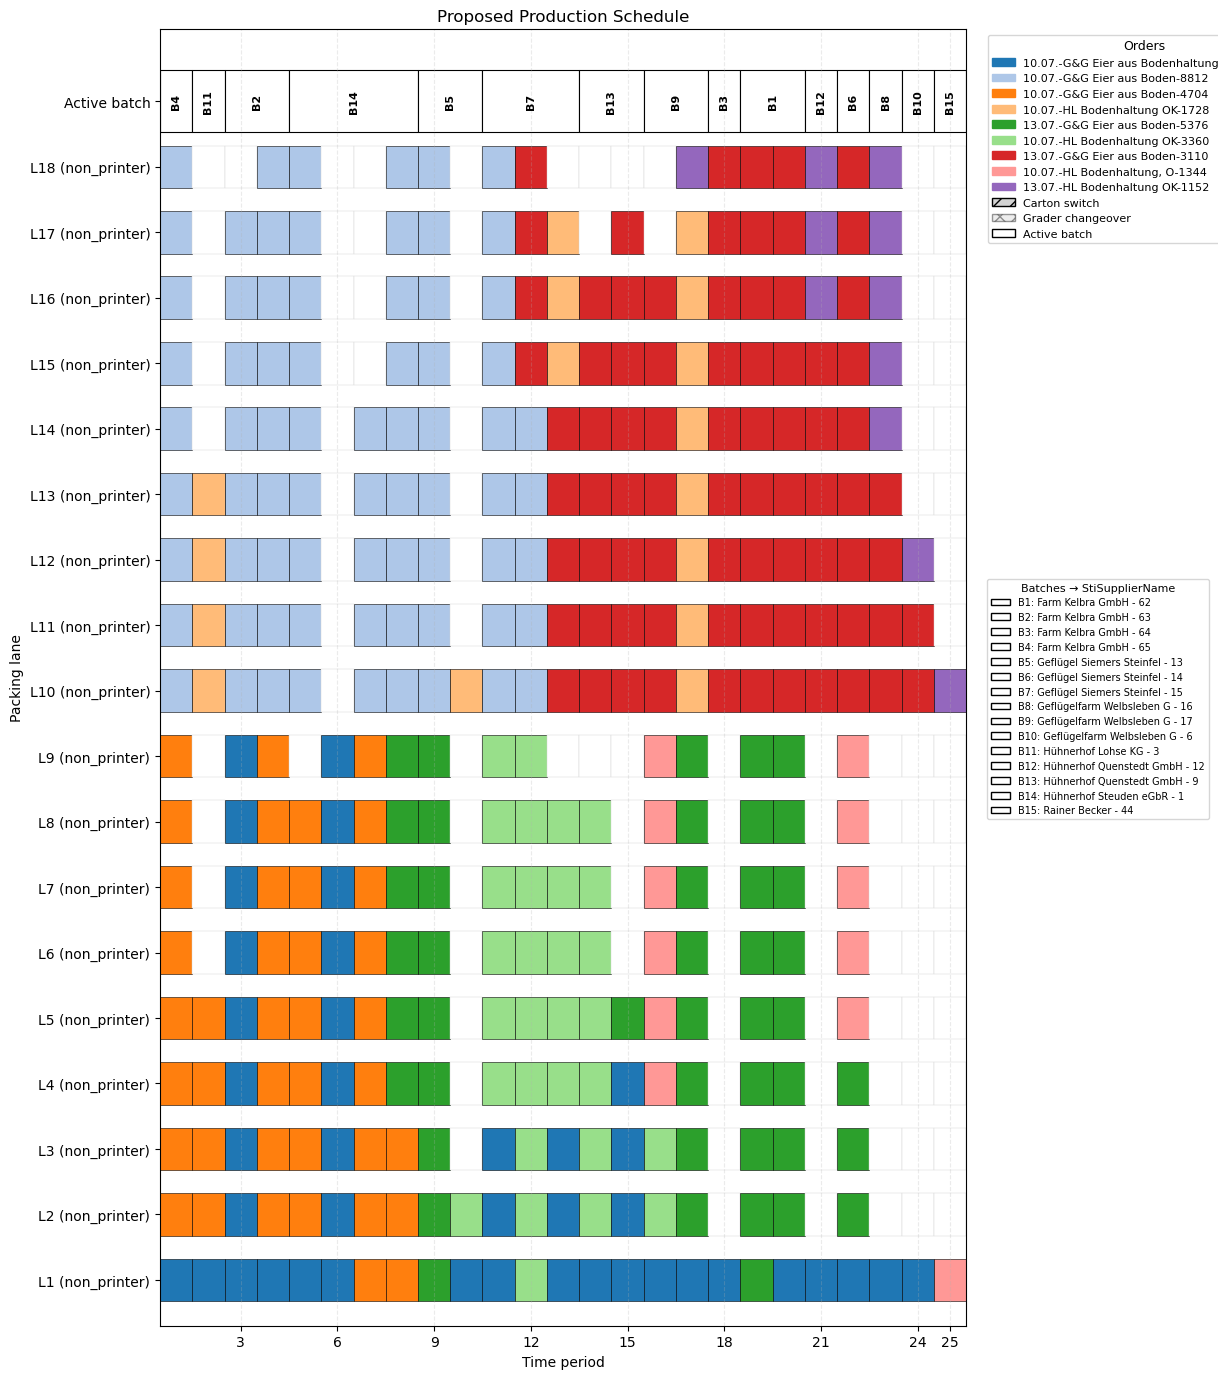

In [18]:
# ============================================================
# Visualize production schedule - Aggregated lane-group model
# active batch displayed once in a separate row
# ============================================================

if model.SolCount > 0:

    import math
    import copy
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib import colormaps


    # ------------------------------------------------------------
    # Helper functions
    # ------------------------------------------------------------

    def lane_number(l):
        """Extract numeric part of lane name such as L12 -> 12."""
        return int("".join(ch for ch in str(l) if ch.isdigit()))


    def order_number(o):
        """Extract numeric part of order name such as O12 -> 12."""
        digits = "".join(ch for ch in str(o) if ch.isdigit())
        return int(digits) if digits else 999999


    def batch_number(b):
        """Extract numeric part of batch name such as B12 -> 12."""
        digits = "".join(ch for ch in str(b) if ch.isdigit())
        return int(digits) if digits else 999999


    def get_order_legend_label(o):
        """
        Return order description for order legend.
        Falls back to O1/O2/... if description is unavailable.
        """
    
        def valid_value(value):
            return value is not None and str(value).strip() != ""
    
        def get_description_from_metadata(order, metadata):
            if order in metadata:
                description = metadata[order].get("description", None)
    
                if valid_value(description):
                    return str(description)
    
            return None
    
        # ------------------------------------------------------------
        # Main case
        # ------------------------------------------------------------
    
        if "order_metadata" in globals():
            description = get_description_from_metadata(o, order_metadata)
    
            if description is not None:
                return description
    
        # ------------------------------------------------------------
        # Optional backup metadata
        # ------------------------------------------------------------
    
        for backup_name in [
            "order_metadata_before_order_combination",
            "old_order_metadata",
            "original_order_metadata",
        ]:
            if backup_name in globals():
                backup_metadata = globals()[backup_name]
    
                description = get_description_from_metadata(
                    o,
                    backup_metadata
                )
    
                if description is not None:
                    return description
    
        # ------------------------------------------------------------
        # DataFrame fallback
        # ------------------------------------------------------------
    
        if "orders_on_day" in globals():
            if (
                "modelOrder" in orders_on_day.columns
                and "description" in orders_on_day.columns
            ):
                matches = orders_on_day.loc[
                    orders_on_day["modelOrder"] == o,
                    "description"
                ]
    
                if len(matches) > 0:
                    description = matches.iloc[0]
    
                    if valid_value(description):
                        return str(description)
    
        # ------------------------------------------------------------
        # Combined-order fallback
        # Example: O1&O2&O4&O8
        # Returns unique descriptions joined together.
        # ------------------------------------------------------------
    
        if "&" in str(o):
            original_orders = str(o).split("&")
            descriptions = []
    
            for original_o in original_orders:
                label = get_order_legend_label(original_o)
    
                if label != original_o:
                    descriptions.append(label)
    
            descriptions = list(dict.fromkeys(descriptions))
    
            if len(descriptions) > 0:
                return " + ".join(descriptions)
    
        return str(o)


    def get_batch_supplier_label(b):
        """
        Return original raw supplier name for batch legend.
        Falls back to other metadata if RawSupplierName is unavailable.
        """

        if "batch_metadata" in globals() and b in batch_metadata:

            for key in [
                "RawSupplierName",
                "StiSupplierName",
                "StiSupplierNames",
                "RawSupplierNames",
                "SupplierName",
            ]:
                value = batch_metadata[b].get(key, None)

                if value is not None and str(value).strip() != "":
                    return str(value)

        return "Unknown supplier"


    def get_group_of_lane(l):
        """Return the lane group of lane l."""
        if pi[l] == 1:
            return "printer"
        return "non_printer"


    def get_lanes_in_group(g):
        """Return lanes belonging to group g, sorted by lane index."""
        if g == "printer":
            return sorted([l for l in L if pi[l] == 1], key=lane_number)

        if g == "non_printer":
            return sorted([l for l in L if pi[l] == 0], key=lane_number)

        return []


    def get_active_batch_in_period(t):
        """Return active batch in period t, or None."""
        active_batches = [
            b for b in B
            if value_or_zero(s[(b, t)]) > 0.5
        ]

        return active_batches[0] if active_batches else None


    def get_total_quantity_for_group_order(g, t, o):
        """Return total quantity produced for order o in group g and period t."""
        return sum(
            value_or_zero(x[key])
            for key in x_by_ogt[(o, g, t)]
        )


    def build_lane_level_schedule():
        """
        Convert aggregated y[o,g,t] and x[b,k,o,g,t] values to a lane-level schedule.
    
        Important:
        - If carton_state exists, the visualization respects the model's hidden
          lane setup state.
        - Idle lanes keep their carton setup.
        - Carton switch markers are based on setup changes, not on arbitrary
          reconstructed order changes.
        """
    
        local_y_index_set = set(Y_INDEX)
    
        carton_types = list(dict.fromkeys(a_order[o] for o in O))
    
        orders_by_carton = {
            a: [o for o in O if a_order[o] == a]
            for a in carton_types
        }
    
        schedule = {
            (l, t): {
                "order": None,
                "qty": 0,
                "group": get_group_of_lane(l),
                "setup_carton": None,
                "carton_switch_boundary": False,
            }
            for l in L
            for t in T
        }
    
        def y_carton_value(a, g, t):
            return sum(
                value_or_zero(y[(o, g, t)])
                for o in orders_by_carton[a]
                if (o, g, t) in local_y_index_set
            )
    
        def get_setup_counts(g, t):
            """
            Number of lanes in group g configured for each carton type in period t.
            Prefer optimized carton_state. Fallback: use active carton usage.
            """
    
            if "carton_state" in globals():
                counts = {
                    a: int(round(value_or_zero(carton_state[(a, g, t)])))
                    for a in carton_types
                }
            else:
                counts = {
                    a: int(round(y_carton_value(a, g, t)))
                    for a in carton_types
                }
    
                # Put remaining idle lanes on the first carton type as fallback.
                used = sum(counts.values())
                if used < N_group[g] and len(carton_types) > 0:
                    counts[carton_types[0]] += N_group[g] - used
    
            return counts
    
        # --------------------------------------------------------
        # Step 1: assign carton setup state to physical lanes
        # --------------------------------------------------------
    
        for g in G:
            lanes_g = get_lanes_in_group(g)
            previous_setup = {l: None for l in lanes_g}
    
            for t in sorted(T):
                target_counts = get_setup_counts(g, t)
                remaining_need = target_counts.copy()
    
                new_setup = {}
                unused_lanes = lanes_g.copy()
    
                # First keep as many previous carton setups as possible
                for a in carton_types:
                    lanes_already_on_a = [
                        l for l in lanes_g
                        if previous_setup.get(l) == a
                    ]
    
                    keep_count = min(
                        len(lanes_already_on_a),
                        remaining_need.get(a, 0)
                    )
    
                    for l in lanes_already_on_a[:keep_count]:
                        new_setup[l] = a
                        unused_lanes.remove(l)
                        remaining_need[a] -= 1
    
                # Then assign remaining setup requirements
                for a in carton_types:
                    while remaining_need.get(a, 0) > 0 and len(unused_lanes) > 0:
                        l = unused_lanes.pop(0)
                        new_setup[l] = a
                        remaining_need[a] -= 1
    
                # Safety fallback for any leftover lanes
                for l in unused_lanes:
                    new_setup[l] = carton_types[0] if len(carton_types) > 0 else None
    
                # Store setup state and setup-switch markers
                for l in lanes_g:
                    schedule[(l, t)]["setup_carton"] = new_setup[l]
    
                    if (
                        previous_setup.get(l) is not None
                        and new_setup[l] != previous_setup.get(l)
                    ):
                        schedule[(l, t)]["carton_switch_boundary"] = True
    
                previous_setup = new_setup
    
        # --------------------------------------------------------
        # Step 2: assign actual production to lanes with matching setup
        # --------------------------------------------------------
    
        for t in sorted(T):
            for g in G:
                lanes_g = get_lanes_in_group(g)
    
                free_lanes_by_carton = {
                    a: [
                        l for l in lanes_g
                        if schedule[(l, t)]["setup_carton"] == a
                    ]
                    for a in carton_types
                }
    
                active_orders = []
    
                for o in O:
                    if (o, g, t) not in local_y_index_set:
                        continue
    
                    produced_qty = get_total_quantity_for_group_order(g, t, o)
    
                    if produced_qty <= 1e-6:
                        continue
    
                    y_value = value_or_zero(y[(o, g, t)])
    
                    lanes_needed_from_qty = math.ceil(produced_qty / C_lane)
                    lanes_allowed_by_y = max(1, round(y_value))
    
                    displayed_lanes = min(
                        lanes_needed_from_qty,
                        lanes_allowed_by_y
                    )
    
                    active_orders.append({
                        "order": o,
                        "carton": a_order[o],
                        "displayed_lanes": displayed_lanes,
                        "produced_qty": produced_qty,
                    })
    
                active_orders.sort(key=lambda row: order_number(row["order"]))
    
                for row in active_orders:
                    o = row["order"]
                    a = row["carton"]
                    displayed_lanes = row["displayed_lanes"]
                    produced_qty = row["produced_qty"]
    
                    qty_per_lane = (
                        produced_qty / displayed_lanes
                        if displayed_lanes > 0
                        else 0
                    )
    
                    for _ in range(displayed_lanes):
                        if len(free_lanes_by_carton.get(a, [])) == 0:
                            print(
                                f"Warning: not enough setup lanes for carton {a} "
                                f"in group {g}, period {t}."
                            )
                            break
    
                        l = free_lanes_by_carton[a].pop(0)
    
                        schedule[(l, t)]["order"] = o
                        schedule[(l, t)]["qty"] = qty_per_lane
    
        return schedule


    def get_batch_runs():
        """
        Return contiguous active-batch runs for the separate batch row.

        Each item is:
            (batch, start_period, end_period)

        where end_period is inclusive.
        """

        runs = []

        current_batch = None
        run_start = None

        for t in T:
            b = get_active_batch_in_period(t)

            if b != current_batch:
                if current_batch is not None:
                    runs.append((current_batch, run_start, t - 1))

                current_batch = b
                run_start = t if b is not None else None

        if current_batch is not None:
            runs.append((current_batch, run_start, max(T)))

        return runs


    def get_limited_xticks(T_values, max_ticks=12):
        """
        Return at most max_ticks x-axis tick labels.
        For 96 periods and max_ticks=12, this returns roughly 8,16,24,...,96.
        """

        t_min_local = min(T_values)
        t_max_local = max(T_values)
        n_periods = len(T_values)

        if n_periods <= max_ticks:
            return T_values

        step = math.ceil(n_periods / max_ticks)

        ticks = [
            t for t in T_values
            if t % step == 0
        ]

        if t_max_local not in ticks:
            ticks.append(t_max_local)

        return ticks[:max_ticks] if len(ticks) > max_ticks else ticks


    lane_schedule = build_lane_level_schedule()


    # ============================================================
    # Visualization preprocessing: expand combined orders back
    # ============================================================
    # Model may contain combined orders such as O1&O3&O5.
    # For visualization, we assign production cells back to the original orders.
    #
    # Assignment order:
    # 1. low lane number first
    # 2. then low time period
    #
    # Example:
    # If model order is O1&O3&O5, the visualization first assigns cells to O1,
    # then O3, then O5.
    # ============================================================

    def expand_combined_orders_for_visualization(lane_schedule):
        """
        Returns a copy of lane_schedule where combined model orders are expanded
        into original visual order labels.

        The original model order is kept in cell["modelOrder"].
        The visual order is written to cell["order"].
        """

        expanded_schedule = copy.deepcopy(lane_schedule)

        # If no order aggregation was done, do nothing
        if "new_to_old_orders" not in globals():
            print("No combined-order mapping found. Visualization orders unchanged.")
            return expanded_schedule

        # If original demand backup is missing, fall back to equal splitting
        has_original_demands = "D_before_order_combination" in globals()

        if not has_original_demands:
            print(
                "Warning: D_before_order_combination not found. "
                "Combined orders will be split approximately equally for visualization."
            )

        # --------------------------------------------------------
        # Make original orders usable in visualization dictionaries
        # --------------------------------------------------------
        # This prevents KeyErrors later if plotting code looks up a_order[o],
        # q_order[o], rho[o], etc. using the visual order name.
        # --------------------------------------------------------

        for model_o, original_orders in new_to_old_orders.items():
            for original_o in original_orders:

                if "a_order" in globals() and original_o not in a_order:
                    a_order[original_o] = a_order[model_o]

                if "q_order" in globals() and original_o not in q_order:
                    q_order[original_o] = q_order[model_o]

                if "rho" in globals() and original_o not in rho:
                    rho[original_o] = rho[model_o]

        # --------------------------------------------------------
        # Expand each combined order separately
        # --------------------------------------------------------

        for model_o, original_orders in new_to_old_orders.items():

            # Nothing to expand for normal single orders
            if len(original_orders) == 1:
                continue

            # All occupied visualization cells for this combined model order
            cells_for_model_order = []

            for (l, t), cell in expanded_schedule.items():
                if cell["order"] == model_o:
                    cells_for_model_order.append((l, t, cell))

            if len(cells_for_model_order) == 0:
                continue

            # Sort low lane first, then low time period
            cells_for_model_order = sorted(
                cells_for_model_order,
                key=lambda item: (item[1], item[0])
            )

            total_visual_qty = sum(
                cell.get("qty", 0)
                for _, _, cell in cells_for_model_order
            )

            # Target quantity per original order
            if has_original_demands:
                target_qty_by_original_order = {
                    original_o: D_before_order_combination[original_o]
                    for original_o in original_orders
                }
            else:
                equal_target = total_visual_qty / len(original_orders)

                target_qty_by_original_order = {
                    original_o: equal_target
                    for original_o in original_orders
                }

            # ----------------------------------------------------
            # Assign cells: first all required cells to first order,
            # then to second order, etc.
            # ----------------------------------------------------

            current_original_index = 0
            produced_for_current_original = 0

            for l, t, cell in cells_for_model_order:

                current_original_o = original_orders[current_original_index]
                current_target = target_qty_by_original_order[current_original_o]

                # Keep the aggregate/model order for traceability
                cell["modelOrder"] = model_o

                # Replace visible order with original order
                cell["order"] = current_original_o

                produced_for_current_original += cell.get("qty", 0)

                # Move to next original order once the current one is sufficiently filled
                if (
                    produced_for_current_original >= current_target
                    and current_original_index < len(original_orders) - 1
                ):
                    current_original_index += 1
                    produced_for_current_original = 0

            print(
                f"Expanded {model_o} into {original_orders} "
                f"for visualization | visual qty = {total_visual_qty:,.0f}"
            )

        return expanded_schedule


    # Apply expansion
    lane_schedule = expand_combined_orders_for_visualization(lane_schedule)


    deaggregated_lane_schedule = copy.deepcopy(lane_schedule)
    
    from collections import Counter
    print("Orders in deaggregated_lane_schedule:")
    print(Counter(
        cell["order"]
        for cell in deaggregated_lane_schedule.values()
        if cell.get("order") is not None
    ))

    # ============================================================
    # Cut visualization horizon at actual makespan
    # ============================================================
    # This removes idle time after the final production period.
    # ============================================================

    active_periods_in_visual_schedule = [
        t
        for (l, t), cell in lane_schedule.items()
        if cell["order"] is not None
    ]

    if len(active_periods_in_visual_schedule) == 0:
        raise ValueError("No active production periods found in lane_schedule.")

    visual_makespan = max(active_periods_in_visual_schedule)

    T_vis = [
        t for t in T
        if t <= visual_makespan
    ]

    print("\nVisualization horizon shortened.")
    print(f"Original horizon: {min(T)} to {max(T)}")
    print(f"Visual horizon:   {min(T_vis)} to {max(T_vis)}")
    print(f"Visual makespan:  {visual_makespan}")


    # ============================================================
    # Create colors for the actual orders shown in the visualization
    # ============================================================
    # Important:
    # After expanding combined orders, lane_schedule may contain original orders
    # such as O1, O2, O4, even if the model order was O1&2&4.
    # Therefore colors must be based on lane_schedule, not only on O.
    # ============================================================

    cmap = colormaps["tab20"]

    visual_orders = list(
        dict.fromkeys(
            cell["order"]
            for (l, t), cell in sorted(
                lane_schedule.items(),
                key=lambda item: (item[0][1], item[0][0])  # time first, then lane
            )
            if cell["order"] is not None
        )
    )

    order_colors = {
        o: cmap(i % cmap.N)
        for i, o in enumerate(visual_orders)
    }


    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    L_sorted = sorted(L, key=lane_number)

    # Wider figure to leave room for two legends on the right
    fig, ax = plt.subplots(figsize=(18, 0.55 * len(L_sorted) + 4))

    bar_height = 0.65

    # Leave one extra row at the top for active batch
    lane_positions = {
        l: i
        for i, l in enumerate(L_sorted)
    }

    batch_y_pos = len(L_sorted)
    all_y_positions = list(lane_positions.values()) + [batch_y_pos]


    # ------------------------------------------------------------
    # Draw production blocks
    # ------------------------------------------------------------

    for l in L_sorted:
        y_pos = lane_positions[l]

        for t in T_vis:
            cell = lane_schedule[(l, t)]
            o = cell["order"]

            # Production block
            if o is not None:
                ax.barh(
                    y=y_pos,
                    width=1,
                    left=t - 0.5,
                    height=bar_height,
                    color=order_colors[o],
                    edgecolor="black",
                    linewidth=0.4
                )

            # Idle block
            else:
                ax.barh(
                    y=y_pos,
                    width=1,
                    left=t - 0.5,
                    height=bar_height,
                    color="white",
                    edgecolor="lightgrey",
                    linewidth=0.3
                )

            # Inferred carton-switch marker.
            # This is not production downtime in the aggregate model.
            if cell["carton_switch_boundary"]:
                ax.barh(
                    y=y_pos,
                    width=0.12,
                    left=t - 0.56,
                    height=bar_height,
                    color="lightgrey",
                    edgecolor="black",
                    hatch="//",
                    linewidth=0.6
                )


    # ------------------------------------------------------------
    # Draw active-batch row
    # ------------------------------------------------------------

    batch_runs = get_batch_runs()

    batch_bar_height = 0.95
    batch_fontsize = 8

    for b, start_t, end_t in batch_runs:

        # Do not draw batch blocks beyond the visualization horizon
        if start_t > max(T_vis):
            continue

        clipped_start_t = max(start_t, min(T_vis))
        clipped_end_t = min(end_t, max(T_vis))

        width = clipped_end_t - clipped_start_t + 1
        left = clipped_start_t - 0.5
        center_x = left + width / 2

        batch_patch = ax.barh(
            y=batch_y_pos,
            width=width,
            left=left,
            height=batch_bar_height,
            color="white",
            edgecolor="black",
            linewidth=0.8
        )[0]

        batch_text = ax.text(
            x=center_x,
            y=batch_y_pos,
            s=b,
            ha="center",
            va="center",
            fontsize=batch_fontsize,
            fontweight="bold",
            rotation=90,
            rotation_mode="anchor",
            clip_on=True
        )

        batch_text.set_clip_path(batch_patch)


    # ------------------------------------------------------------
    # Add grader-level changeover markers
    # ------------------------------------------------------------

    for t in T_vis:
        if value_or_zero(z_grader[t]) > 0.5:
            ax.axvspan(
                t - 0.5,
                t + 0.5,
                facecolor="lightgrey",
                edgecolor="black",
                alpha=0.25,
                hatch="xx",
                linewidth=0.0
            )


    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------

    ax.set_yticks(all_y_positions)
    ax.set_yticklabels(
        [
            f"{l} ({get_group_of_lane(l)})"
            for l in L_sorted
        ]
        + ["Active batch"]
    )

    xticks = get_limited_xticks(T_vis, max_ticks=12)
    ax.set_xticks(xticks)

    ax.set_xlabel("Time period")
    ax.set_ylabel("Packing lane")
    ax.set_title("Proposed Production Schedule")

    ax.set_xlim(min(T_vis) - 0.5, max(T_vis) + 0.5)
    ax.set_ylim(-0.7, batch_y_pos + 1.1)

    ax.grid(axis="x", linestyle="--", alpha=0.25)


    # ------------------------------------------------------------
    # Legend 1: Orders
    # ------------------------------------------------------------

    order_patches = [
        mpatches.Patch(
            color=color,
            label=get_order_legend_label(o)
        )
        for o, color in order_colors.items()
    ]

    carton_switch_patch = mpatches.Patch(
        facecolor="lightgrey",
        edgecolor="black",
        hatch="//",
        label="Carton switch"
    )

    grader_changeover_patch = mpatches.Patch(
        facecolor="lightgrey",
        edgecolor="black",
        hatch="xx",
        alpha=0.4,
        label="Grader changeover"
    )

    active_batch_patch = mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        label="Active batch"
    )

    main_legend_handles = order_patches + [
        carton_switch_patch,
        grader_changeover_patch,
        active_batch_patch
    ]

    main_legend = ax.legend(
        handles=main_legend_handles,
        title="Orders",
        bbox_to_anchor=(1.02, 1.00),
        loc="upper left",
        fontsize=8,
        title_fontsize=9
    )

    ax.add_artist(main_legend)


    # ------------------------------------------------------------
    # Legend 2: Batches to original StiSupplierName
    # ------------------------------------------------------------

    batch_legend_handles = [
        mpatches.Patch(
            facecolor="white",
            edgecolor="black",
            label=f"{b}: {get_batch_supplier_label(b)}"
        )
        for b in sorted(B, key=batch_number)
    ]

    ax.legend(
        handles=batch_legend_handles,
        title="Batches → StiSupplierName",
        bbox_to_anchor=(1.02, 0.58),
        loc="upper left",
        fontsize=7,
        title_fontsize=8
    )


    # Leave room on the right for both legends
    plt.tight_layout(rect=[0, 0, 0.74, 1])
    plt.show()

else:
    print("No feasible solution available, so schedule visualization cannot be created.")

In [19]:
# ============================================================
# Concise KPI report
# Uses the setup-state-aware visualization logic
# ============================================================

if model.SolCount > 0:

    # ------------------------------------------------------------
    # Always rebuild lane schedule
    # Important: prevents using an old/stale visualization schedule
    # ------------------------------------------------------------

    lane_schedule = build_lane_level_schedule()



    
    # ------------------------------------------------------------
    # Makespan
    # ------------------------------------------------------------

    makespan_kpi = value_or_zero(makespan)

    # ------------------------------------------------------------
    # Demand satisfied
    # ------------------------------------------------------------

    total_demand = sum(D[o] for o in O)

    total_fulfilled = sum(
        value_or_zero(x[key])
        for key in X_INDEX
    )

    demand_satisfied_pct = (
        100 * total_fulfilled / total_demand
        if total_demand > 0
        else 0
    )

    # ------------------------------------------------------------
    # Scrap
    # ------------------------------------------------------------

    total_available_supply = sum(
        S[(b, k)]
        for b in B
        for k in K
    )

    total_scrap = sum(
        value_or_zero(scrap[(b, k)])
        for b in B
        for k in K
    )

    scrap_pct = (
        100 * total_scrap / total_available_supply
        if total_available_supply > 0
        else 0
    )

    # ------------------------------------------------------------
    # Lane changeovers
    # A lane changeover means a lane changes from one carton type to another.
    # ------------------------------------------------------------
    
    lane_changeovers = sum(
        value_or_zero(lane_setup_chg[(g, t)])
        for g in G
        for t in T_not_first
    )
    
    # Include initial setup changes only if you explicitly added them to the objective
    if "initial_lane_setup_chg" in globals():
        lane_changeovers += sum(
            value_or_zero(initial_lane_setup_chg[g])
            for g in G
        )

    # ------------------------------------------------------------
    # Full grader changeovers
    # ------------------------------------------------------------

    full_grader_changeovers = sum(
        value_or_zero(z_grader[t])
        for t in T
    )

    # ------------------------------------------------------------
    # Print KPI summary
    # ------------------------------------------------------------

    print("\n" + "=" * 50)
    print("KPI SUMMARY")
    print("=" * 50)
    print(f"Runtime:                         {runtime / 60:.2f} minutes")
    print(f"Makespan:                        {makespan_kpi:,.0f} periods")
    print(f"Demand satisfied:                {demand_satisfied_pct:,.2f}%")
    print(f"Scrap:                           {scrap_pct:,.2f}%")
    print(f"Lane Changeovers:                {lane_changeovers:,.0f}")
    print(f"Full grader changeovers:         {full_grader_changeovers:,.0f}")
    print(f"Norm. Downgrading:               {downgrading_cost / DOWNGRADE_COST_PER_SIZE_STEP:,.1f}")

else:
    print("No feasible solution available, so KPIs cannot be reported.")


KPI SUMMARY
Runtime:                         0.01 minutes
Makespan:                        25 periods
Demand satisfied:                99.77%
Scrap:                           2.00%
Lane Changeovers:                0
Full grader changeovers:         0
Norm. Downgrading:               355,913.0


In [20]:
from collections import Counter
print("Orders in deaggregated_lane_schedule:")
print(Counter(
    cell["order"]
    for cell in deaggregated_lane_schedule.values()
    if cell.get("order") is not None
))

Orders in deaggregated_lane_schedule:
Counter({'O4': 79, 'O2': 72, 'O8': 44, 'O3': 42, 'O1': 39, 'O6': 30, 'O5': 16, 'O7': 12, 'O9': 11})


In [21]:
# ============================================================
# Local-search polishing:
# improve ORIGINAL reconstructed lane-level schedule by local swaps/moves
# ============================================================
# Starting point:
# - original reconstructed lane-level schedule from the original MILP solution
#
# Main idea:
# - Move chronologically through batch-lane-group blocks
# - Try swapping/moving production cells inside each block
# - Accept a move only if:
#     1. carton changeovers do not increase
#     2. the lane-level order-continuity score improves
#
# This version uses BEST-IMPROVEMENT:
# - In each block pass, all candidate swaps are evaluated.
# - The best improving swap is applied.
# - Then the process repeats until no improving swap is found.
#
# Important:
# - This improves the lane-level schedule visualization / realization.
# - It does NOT change the original MILP objective value.
# - It preserves the visible production tokens inside each batch-lane-group block.
#
# Output variable names are kept unchanged:
# - v2_local_lane_schedule
# - local_search_lane_schedule
# - v2_local_search_summary
# - v2ls_global_summary
# ============================================================

import copy
import math
import time
from collections import defaultdict
import pandas as pd


# ============================================================
# User settings
# ============================================================

V2LS_EPS = 1e-6

# Set this manually if auto-detection selects the wrong schedule.
# Example:
# ORIGINAL_RECONSTRUCTED_SCHEDULE_NAME = "lane_schedule"
ORIGINAL_RECONSTRUCTED_SCHEDULE_NAME = "deaggregated_lane_schedule"

# Number of improvement passes over all batch-lane-group blocks
V2LS_MAX_GLOBAL_PASSES = 5

# Number of local best-improvement passes inside one batch-lane-group block
V2LS_MAX_BLOCK_PASSES = 50

# Limit number of candidate swaps tried per block pass.
# None means try all candidate pairs.
V2LS_MAX_CANDIDATES_PER_BLOCK_PASS = None

# Allow moving production into idle cells by swapping nonempty with empty.
V2LS_ALLOW_NONEMPTY_EMPTY_SWAPS = True

# Allow swapping two empty cells. Usually useless, so keep False.
V2LS_ALLOW_EMPTY_EMPTY_SWAPS = False

# Check capacities after candidate moves.
V2LS_CHECK_GRADER_CAPACITY = True
V2LS_CHECK_LANE_CAPACITY = True

# Optional time guard per batch-lane-group block.
# None means no block-level time limit.
V2LS_MAX_SECONDS_PER_BLOCK = None

# Candidate ordering. With best-improvement this mainly affects diagnostics
# and possible candidate truncation if V2LS_MAX_CANDIDATES_PER_BLOCK_PASS is used.
V2LS_PRIORITIZE_NEARBY_SWAPS = True

# Score weights.
# Higher-priority effects should have larger weights.
V2LS_WEIGHT_ORDER_SWITCH = 100000
V2LS_WEIGHT_SAME_CARTON_ORDER_SWITCH = 50000
V2LS_WEIGHT_ONE_PERIOD_RUN = 10000
V2LS_WEIGHT_ISOLATED_ACTIVE_CELL = 5000
V2LS_WEIGHT_TOTAL_RUN = 1000
V2LS_WEIGHT_NEAREST_SAME_ORDER_DISTANCE = 100
V2LS_WEIGHT_ACTIVE_CELL = 1

# Distance penalty cap for active cells.
# Lower is better. This rewards moving an order closer to other cells of the same order
# on the same physical lane.
V2LS_NEAREST_SAME_ORDER_DISTANCE_CAP = 6

# Print every accepted move.
V2LS_VERBOSE_ACCEPTED_MOVES = True


# ============================================================
# Helper functions
# ============================================================

def v2ls_val(value):
    if isinstance(value, (int, float)):
        return float(value)
    try:
        return float(value.X)
    except Exception:
        return 0.0


def v2ls_lane_number(l):
    digits = "".join(ch for ch in str(l) if ch.isdigit())
    return int(digits) if digits else 999999


def v2ls_order_number(o):
    digits = "".join(ch for ch in str(o) if ch.isdigit())
    return int(digits) if digits else 999999


def v2ls_batch_number(b):
    digits = "".join(ch for ch in str(b) if ch.isdigit())
    return int(digits) if digits else 999999


def v2ls_display(df, title, max_rows=100):
    if "display_or_print" in globals():
        display_or_print(df, title, max_rows=max_rows)
    else:
        print("\n" + title)
        print(df.head(max_rows).to_string(index=False))


def v2ls_valid_order_value(value):
    if value is None:
        return False

    try:
        if pd.isna(value):
            return False
    except Exception:
        pass

    return True


def v2ls_get_carton(order):
    if order is None:
        return None

    if "a_order" not in globals():
        return None

    try:
        return a_order[order]
    except Exception:
        return None


def v2ls_get_group_of_lane(l):
    if "L_g" in globals():
        for g, lanes_g in L_g.items():
            if l in lanes_g:
                return g

    if "lanes_by_group" in globals():
        for g, lanes_g in lanes_by_group.items():
            if l in lanes_g:
                return g

    if "lane_groups" in globals():
        for g, lanes_g in lane_groups.items():
            if l in lanes_g:
                return g

    if "pi" in globals() and l in pi:
        if v2ls_val(pi[l]) == 1:
            return "printer"
        return "non_printer"

    return "unknown"


def v2ls_get_lanes_in_group(g):
    if "L_g" in globals() and g in L_g:
        return sorted(list(L_g[g]), key=v2ls_lane_number)

    if "lanes_by_group" in globals() and g in lanes_by_group:
        return sorted(list(lanes_by_group[g]), key=v2ls_lane_number)

    if "lane_groups" in globals() and g in lane_groups:
        return sorted(list(lane_groups[g]), key=v2ls_lane_number)

    if "L" in globals() and "pi" in globals():
        if g == "printer":
            return sorted([l for l in L if v2ls_val(pi[l]) == 1], key=v2ls_lane_number)
        if g == "non_printer":
            return sorted([l for l in L if v2ls_val(pi[l]) == 0], key=v2ls_lane_number)

    return sorted([l for l in L if v2ls_get_group_of_lane(l) == g], key=v2ls_lane_number)


def v2ls_get_active_batch_by_t():
    """
    Get the active batch per period from the original MILP solution.
    Prefer active_batch_by_t if it exists; otherwise reconstruct from s[b,t].
    """
    if "active_batch_by_t" in globals():
        return dict(active_batch_by_t)

    active = {}

    for t in T:
        active_batches = []

        if "s" in globals():
            active_batches = [
                b for b in B
                if (b, t) in s and v2ls_val(s[(b, t)]) > 0.5
            ]

        if len(active_batches) == 1:
            active[t] = active_batches[0]
        elif len(active_batches) == 0:
            active[t] = None
        else:
            raise RuntimeError(f"Multiple active batches in period {t}: {active_batches}")

    return active


def v2ls_is_lane_schedule(obj):
    """
    Check whether an object looks like a lane-level schedule:
    dictionary with keys (lane, period) and cell dictionaries.
    """
    if not isinstance(obj, dict):
        return False

    if len(obj) == 0:
        return False

    sample_key = next(iter(obj.keys()))
    sample_val = obj[sample_key]

    if not isinstance(sample_key, tuple) or len(sample_key) != 2:
        return False

    if not isinstance(sample_val, dict):
        return False

    expected_fields = {"order", "modelOrder", "qty", "setup_carton", "group"}

    return any(field in sample_val for field in expected_fields)


def v2ls_find_original_reconstructed_schedule():
    """
    Find the original reconstructed lane-level schedule.

    This deliberately avoids post2 / PP3 / PP4 / local-search schedules.
    """

    if ORIGINAL_RECONSTRUCTED_SCHEDULE_NAME is not None:
        if ORIGINAL_RECONSTRUCTED_SCHEDULE_NAME not in globals():
            raise RuntimeError(
                f"ORIGINAL_RECONSTRUCTED_SCHEDULE_NAME is set to "
                f"'{ORIGINAL_RECONSTRUCTED_SCHEDULE_NAME}', but this variable does not exist."
            )

        obj = globals()[ORIGINAL_RECONSTRUCTED_SCHEDULE_NAME]

        if not v2ls_is_lane_schedule(obj):
            raise RuntimeError(
                f"'{ORIGINAL_RECONSTRUCTED_SCHEDULE_NAME}' exists, "
                "but it does not look like a lane-level schedule."
            )

        return ORIGINAL_RECONSTRUCTED_SCHEDULE_NAME, obj

    candidate_names = [
        "lane_schedule",
        "original_lane_schedule",
        "reconstructed_lane_schedule",
        "physical_lane_schedule",
        "lane_level_schedule",
        "schedule_lane_level",
        "schedule",
    ]

    excluded_names = {
        "post2_lane_schedule",
        "pp3_lane_schedule",
        "pp4_lane_schedule",
        "v2_local_lane_schedule",
        "local_search_lane_schedule",
        "v2ls_current_schedule",
        "v2ls_base_lane_schedule",
        "v2ls_polished_schedule_for_plot",
        "pp4_lane_schedule_for_plot",
    }

    for name in candidate_names:
        if name in excluded_names:
            continue

        if name in globals() and v2ls_is_lane_schedule(globals()[name]):
            return name, globals()[name]

    for name, obj in list(globals().items()):
        if name in excluded_names:
            continue

        lowered = name.lower()

        if any(bad in lowered for bad in ["post2", "pp3", "pp4", "local", "v2ls"]):
            continue

        if v2ls_is_lane_schedule(obj):
            return name, obj

    raise RuntimeError(
        "Could not find the original reconstructed lane-level schedule. "
        "Set ORIGINAL_RECONSTRUCTED_SCHEDULE_NAME manually near the top, for example:\n"
        "ORIGINAL_RECONSTRUCTED_SCHEDULE_NAME = 'lane_schedule'"
    )


def v2ls_repair_original_schedule_structure(schedule):
    """
    Make sure the original reconstructed schedule has the exact fields needed
    by the local-search code.

    Required cell fields:
    - order
    - modelOrder
    - qty
    - group
    - setup_carton
    - carton_switch_boundary
    """

    repaired = copy.deepcopy(schedule)

    for l in L:
        previous_carton = None

        for t in sorted(T):
            key = (l, t)

            if key not in repaired:
                repaired[key] = {}

            cell = repaired[key]

            raw_order = cell.get("order", None)
            model_order = cell.get("modelOrder", None)

            # Prefer modelOrder when order was expanded for visualization.
            if v2ls_valid_order_value(raw_order) and raw_order in a_order:
                order_to_use = raw_order
            elif v2ls_valid_order_value(model_order) and model_order in a_order:
                order_to_use = model_order
            else:
                order_to_use = None

            qty = cell.get("qty", 0.0)

            try:
                qty = float(qty)
            except Exception:
                qty = 0.0

            if order_to_use is None or qty <= V2LS_EPS:
                cell["order"] = None
                cell["modelOrder"] = None
                cell["qty"] = 0.0
            else:
                cell["order"] = order_to_use
                cell["modelOrder"] = order_to_use
                cell["qty"] = qty

            if "group" not in cell or cell["group"] is None:
                cell["group"] = v2ls_get_group_of_lane(l)

            if cell["order"] is not None and cell["order"] in a_order:
                current_carton = v2ls_get_carton(cell["order"])
            else:
                current_carton = cell.get("setup_carton", previous_carton)

            cell["setup_carton"] = current_carton

            cell["carton_switch_boundary"] = (
                previous_carton is not None
                and current_carton is not None
                and current_carton != previous_carton
            )

            if current_carton is not None:
                previous_carton = current_carton

    return repaired


def v2ls_is_active_cell(cell):
    return cell.get("order", None) is not None and cell.get("qty", 0.0) > V2LS_EPS


def v2ls_cell_signature(cell):
    return (
        cell.get("order", None),
        cell.get("modelOrder", None),
        round(cell.get("qty", 0.0), 6),
        cell.get("setup_carton", None),
    )


def v2ls_copy_prod_part(cell):
    return {
        "order": cell.get("order", None),
        "modelOrder": cell.get("modelOrder", None),
        "qty": cell.get("qty", 0.0),
    }


def v2ls_set_prod_part(cell, prod_part, fallback_setup_carton=None):
    """
    Assign only the production part of a cell.

    If the new cell is active, setup_carton becomes the order carton.
    If the new cell is idle, setup_carton is kept as fallback_setup_carton.
    """
    new_order = prod_part.get("order", None)

    cell["order"] = new_order
    cell["modelOrder"] = prod_part.get("modelOrder", None)
    cell["qty"] = prod_part.get("qty", 0.0)

    if new_order is not None:
        cell["setup_carton"] = v2ls_get_carton(new_order)
    else:
        cell["setup_carton"] = fallback_setup_carton


def v2ls_recalculate_carton_boundaries(schedule):
    """
    Recalculate carton_switch_boundary for the entire schedule based on setup_carton.
    Idle periods keep their setup_carton, so carton state can carry through idle time.
    """
    for l in L:
        previous_carton = None

        for t in sorted(T):
            current_carton = schedule[(l, t)].get("setup_carton", None)

            schedule[(l, t)]["carton_switch_boundary"] = (
                previous_carton is not None
                and current_carton is not None
                and current_carton != previous_carton
            )

            if current_carton is not None:
                previous_carton = current_carton


def v2ls_get_block_periods_with_boundary(periods_block):
    """
    Return block periods plus previous and next period if they exist.
    This lets the score account for:
    - last period of previous batch -> first period of current batch
    - within-batch switches
    - last period of current batch -> first period of next batch
    """
    periods_block = sorted(periods_block)

    if len(periods_block) == 0:
        return []

    all_periods = sorted(T)
    first_t = periods_block[0]
    last_t = periods_block[-1]

    out = set(periods_block)

    previous_periods = [t for t in all_periods if t < first_t]
    next_periods = [t for t in all_periods if t > last_t]

    if previous_periods:
        out.add(max(previous_periods))

    if next_periods:
        out.add(min(next_periods))

    return sorted(out)


def v2ls_score_schedule(schedule, lanes_scope=None, periods_scope=None):
    """
    Return a score dictionary for a schedule over selected lanes and periods.

    Lower is better.

    The score contains the original switching metrics plus visual-continuity terms:
    - isolated active cells
    - nearest same-order distance on the same lane
    """

    if lanes_scope is None:
        lanes_scope = list(L)

    if periods_scope is None:
        periods_scope = list(T)

    lanes_scope = sorted(lanes_scope, key=v2ls_lane_number)
    periods_scope = sorted(periods_scope)

    carton_switches = 0
    order_switches = 0
    same_carton_order_switches = 0
    different_carton_order_switches = 0
    active_cells = 0

    total_runs = 0
    one_period_runs = 0
    run_lengths = []

    isolated_active_cells = 0
    nearest_same_order_distance_penalty = 0

    for l in lanes_scope:
        prev_order = None
        prev_carton = None

        current_run_order = None
        current_run_length = 0

        order_by_t = {
            t: schedule[(l, t)].get("order", None)
            for t in periods_scope
        }

        active_periods_by_order = defaultdict(list)

        for t in periods_scope:
            o = order_by_t[t]
            if o is not None:
                active_periods_by_order[o].append(t)

        for t in periods_scope:
            cell = schedule[(l, t)]
            cur_order = cell.get("order", None)
            cur_carton = cell.get("setup_carton", None)

            if cur_order is not None:
                active_cells += 1

                prev_t_candidates = [tt for tt in periods_scope if tt < t]
                next_t_candidates = [tt for tt in periods_scope if tt > t]

                prev_t = max(prev_t_candidates) if prev_t_candidates else None
                next_t = min(next_t_candidates) if next_t_candidates else None

                same_prev = (
                    prev_t is not None
                    and schedule[(l, prev_t)].get("order", None) == cur_order
                )

                same_next = (
                    next_t is not None
                    and schedule[(l, next_t)].get("order", None) == cur_order
                )

                if not same_prev and not same_next:
                    isolated_active_cells += 1

                same_order_periods = [
                    tt for tt in active_periods_by_order[cur_order]
                    if tt != t
                ]

                if len(same_order_periods) == 0:
                    nearest_same_order_distance_penalty += V2LS_NEAREST_SAME_ORDER_DISTANCE_CAP
                else:
                    nearest_distance = min(abs(t - tt) for tt in same_order_periods)
                    nearest_same_order_distance_penalty += min(
                        nearest_distance,
                        V2LS_NEAREST_SAME_ORDER_DISTANCE_CAP
                    )

            # Carton switch: based on setup state
            if (
                prev_carton is not None
                and cur_carton is not None
                and cur_carton != prev_carton
            ):
                carton_switches += 1

            # Order switch: only when both periods have active but different orders
            if (
                prev_order is not None
                and cur_order is not None
                and cur_order != prev_order
            ):
                order_switches += 1

                if v2ls_get_carton(prev_order) == v2ls_get_carton(cur_order):
                    same_carton_order_switches += 1
                else:
                    different_carton_order_switches += 1

            # Run counting
            if cur_order is not None and cur_order == current_run_order:
                current_run_length += 1
            else:
                if current_run_order is not None:
                    total_runs += 1
                    run_lengths.append(current_run_length)

                    if current_run_length == 1:
                        one_period_runs += 1

                current_run_order = cur_order
                current_run_length = 1 if cur_order is not None else 0

            if cur_carton is not None:
                prev_carton = cur_carton

            prev_order = cur_order

        if current_run_order is not None:
            total_runs += 1
            run_lengths.append(current_run_length)

            if current_run_length == 1:
                one_period_runs += 1

    weighted_order_score = (
        V2LS_WEIGHT_ORDER_SWITCH * order_switches
        + V2LS_WEIGHT_SAME_CARTON_ORDER_SWITCH * same_carton_order_switches
        + V2LS_WEIGHT_ONE_PERIOD_RUN * one_period_runs
        + V2LS_WEIGHT_ISOLATED_ACTIVE_CELL * isolated_active_cells
        + V2LS_WEIGHT_TOTAL_RUN * total_runs
        + V2LS_WEIGHT_NEAREST_SAME_ORDER_DISTANCE * nearest_same_order_distance_penalty
        + V2LS_WEIGHT_ACTIVE_CELL * active_cells
    )

    avg_run_length = sum(run_lengths) / len(run_lengths) if run_lengths else 0.0

    return {
        "carton_switches": carton_switches,
        "order_switches": order_switches,
        "same_carton_order_switches": same_carton_order_switches,
        "different_carton_order_switches": different_carton_order_switches,
        "one_period_runs": one_period_runs,
        "total_runs": total_runs,
        "active_cells": active_cells,
        "isolated_active_cells": isolated_active_cells,
        "nearest_same_order_distance_penalty": nearest_same_order_distance_penalty,
        "avg_run_length": avg_run_length,
        "weighted_order_score": weighted_order_score,
    }


def v2ls_score_rank(score):
    """
    Rank used for best-improvement selection.
    Lower is better.

    Carton switches are not the first component because a candidate with fewer
    carton switches but much worse order continuity should not automatically win.
    Carton switches are instead enforced separately as a hard non-increase rule.
    """
    return (
        score["weighted_order_score"],
        score["carton_switches"],
        score["order_switches"],
        score["same_carton_order_switches"],
        score["different_carton_order_switches"],
        score["one_period_runs"],
        score["isolated_active_cells"],
        score["nearest_same_order_distance_penalty"],
        score["total_runs"],
        score["active_cells"],
    )


def v2ls_is_better_score(candidate, current):
    """
    Accept candidate if:
    - carton switches do not increase
    - ranked score improves
    """
    if candidate["carton_switches"] > current["carton_switches"]:
        return False

    return v2ls_score_rank(candidate) < v2ls_score_rank(current)


def v2ls_period_quantity(schedule, t):
    return sum(
        cell.get("qty", 0.0)
        for (l, tt), cell in schedule.items()
        if tt == t and cell.get("order", None) is not None
    )


def v2ls_lane_quantity(schedule, l, t):
    return (
        schedule[(l, t)].get("qty", 0.0)
        if schedule[(l, t)].get("order", None) is not None
        else 0.0
    )


def v2ls_capacity_ok(schedule, affected_periods=None, affected_lanes=None):
    """
    Check simple capacity feasibility after a candidate move.
    """
    if affected_periods is None:
        affected_periods = T

    if affected_lanes is None:
        affected_lanes = L

    if V2LS_CHECK_LANE_CAPACITY and "C_lane" in globals():
        for l in affected_lanes:
            for t in affected_periods:
                if v2ls_lane_quantity(schedule, l, t) > C_lane + 1e-5:
                    return False

    if V2LS_CHECK_GRADER_CAPACITY and "C_grader" in globals():
        for t in affected_periods:
            if v2ls_period_quantity(schedule, t) > C_grader + 1e-5:
                return False

    return True


def v2ls_apply_swap_inplace(schedule, key1, key2):
    """
    Apply a production-part swap in place.
    Return old cells so the move can be undone.
    """
    old1 = copy.deepcopy(schedule[key1])
    old2 = copy.deepcopy(schedule[key2])

    cell1 = schedule[key1]
    cell2 = schedule[key2]

    prod1 = v2ls_copy_prod_part(cell1)
    prod2 = v2ls_copy_prod_part(cell2)

    setup1 = cell1.get("setup_carton", None)
    setup2 = cell2.get("setup_carton", None)

    v2ls_set_prod_part(schedule[key1], prod2, fallback_setup_carton=setup1)
    v2ls_set_prod_part(schedule[key2], prod1, fallback_setup_carton=setup2)

    v2ls_recalculate_carton_boundaries(schedule)

    return old1, old2


def v2ls_undo_swap_inplace(schedule, key1, key2, old1, old2):
    """
    Undo a swap that was applied in place.
    """
    schedule[key1].clear()
    schedule[key1].update(old1)

    schedule[key2].clear()
    schedule[key2].update(old2)

    v2ls_recalculate_carton_boundaries(schedule)


def v2ls_get_block_keys(lanes_g, periods_b):
    return [
        (l, t)
        for t in sorted(periods_b)
        for l in sorted(lanes_g, key=v2ls_lane_number)
    ]


def v2ls_pair_allowed(schedule, key1, key2):
    if key1 == key2:
        return False

    cell1 = schedule[key1]
    cell2 = schedule[key2]

    active1 = v2ls_is_active_cell(cell1)
    active2 = v2ls_is_active_cell(cell2)

    if not active1 and not active2 and not V2LS_ALLOW_EMPTY_EMPTY_SWAPS:
        return False

    if active1 != active2 and not V2LS_ALLOW_NONEMPTY_EMPTY_SWAPS:
        return False

    if v2ls_cell_signature(cell1) == v2ls_cell_signature(cell2):
        return False

    return True


def v2ls_generate_candidate_pairs(schedule, block_keys):
    pairs = []

    for i in range(len(block_keys)):
        for j in range(i + 1, len(block_keys)):
            key1 = block_keys[i]
            key2 = block_keys[j]

            if not v2ls_pair_allowed(schedule, key1, key2):
                continue

            l1, t1 = key1
            l2, t2 = key2

            same_period = 0 if t1 == t2 else 1

            priority = (
                same_period,
                abs(t1 - t2),
                abs(v2ls_lane_number(l1) - v2ls_lane_number(l2)),
                t1,
                t2,
                v2ls_lane_number(l1),
                v2ls_lane_number(l2),
            )

            pairs.append((priority, key1, key2))

    if V2LS_PRIORITIZE_NEARBY_SWAPS:
        pairs.sort(key=lambda row: row[0])

    if V2LS_MAX_CANDIDATES_PER_BLOCK_PASS is not None:
        pairs = pairs[:V2LS_MAX_CANDIDATES_PER_BLOCK_PASS]

    return [(key1, key2) for _, key1, key2 in pairs]


# ============================================================
# Preparation
# ============================================================

print("\n" + "=" * 100)
print("LOCAL-SEARCH LANE-LEVEL POLISHING")
print("=" * 100)
print("Starting from the original reconstructed lane-level schedule.")
print("Using best-improvement local search.")

required_objects = ["B", "G", "L", "T", "a_order"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise RuntimeError(f"Missing required objects: {missing_objects}")

original_schedule_name, original_schedule_obj = v2ls_find_original_reconstructed_schedule()

print(f"Original reconstructed schedule found: {original_schedule_name}")

v2ls_base_lane_schedule = v2ls_repair_original_schedule_structure(original_schedule_obj)
v2ls_recalculate_carton_boundaries(v2ls_base_lane_schedule)

active_batch_by_t_v2ls = v2ls_get_active_batch_by_t()

periods_by_batch_v2ls = defaultdict(list)

for t, b in active_batch_by_t_v2ls.items():
    if b is not None:
        periods_by_batch_v2ls[b].append(t)

batch_sequence_v2ls = sorted(
    [b for b in B if len(periods_by_batch_v2ls[b]) > 0],
    key=lambda b: min(periods_by_batch_v2ls[b])
)

print("\nBatch sequence used for local search:")
for b in batch_sequence_v2ls:
    periods_b = periods_by_batch_v2ls[b]
    print(f"  {b:<8} periods {min(periods_b)}-{max(periods_b)}")

print("\nInitial schedule source:")
print(f"  Source variable: {original_schedule_name}")
print("  Local search will preserve visible production tokens inside each batch-lane-group block.")


# ============================================================
# Run local search
# ============================================================

v2ls_current_schedule = copy.deepcopy(v2ls_base_lane_schedule)
v2ls_recalculate_carton_boundaries(v2ls_current_schedule)

v2ls_start_time = time.time()

initial_global_score = v2ls_score_schedule(
    v2ls_current_schedule,
    lanes_scope=L,
    periods_scope=T
)

print("\nInitial global score:")
for key, value in initial_global_score.items():
    print(f"  {key:<45} {value}")

v2ls_block_rows = []
v2ls_total_accepted_moves = 0
v2ls_total_candidates_evaluated = 0

for global_pass in range(1, V2LS_MAX_GLOBAL_PASSES + 1):
    print("\n" + "=" * 100)
    print(f"GLOBAL LOCAL-SEARCH PASS {global_pass}")
    print("=" * 100)

    accepted_this_global_pass = 0

    for b in batch_sequence_v2ls:
        periods_b = sorted(periods_by_batch_v2ls[b])

        if len(periods_b) == 0:
            continue

        for g in G:
            lanes_g = v2ls_get_lanes_in_group(g)

            block_keys = v2ls_get_block_keys(lanes_g, periods_b)

            active_tokens_in_block = sum(
                1
                for key in block_keys
                if v2ls_is_active_cell(v2ls_current_schedule[key])
            )

            if active_tokens_in_block <= 1:
                continue

            periods_score = v2ls_get_block_periods_with_boundary(periods_b)

            before_score = v2ls_score_schedule(
                v2ls_current_schedule,
                lanes_scope=lanes_g,
                periods_scope=periods_score
            )

            block_accepted_moves = 0
            block_candidates_evaluated = 0
            block_start_time = time.time()

            print(
                f"\nBlock {b} / {g}: "
                f"{len(lanes_g)} lanes, periods {min(periods_b)}-{max(periods_b)}, "
                f"{active_tokens_in_block} active cells"
            )
            print(
                f"  Before: carton={before_score['carton_switches']}, "
                f"order={before_score['order_switches']}, "
                f"same-carton={before_score['same_carton_order_switches']}, "
                f"one-period-runs={before_score['one_period_runs']}, "
                f"isolated={before_score['isolated_active_cells']}, "
                f"distance={before_score['nearest_same_order_distance_penalty']}, "
                f"weighted={before_score['weighted_order_score']}"
            )

            for block_pass in range(1, V2LS_MAX_BLOCK_PASSES + 1):
                if (
                    V2LS_MAX_SECONDS_PER_BLOCK is not None
                    and time.time() - block_start_time > V2LS_MAX_SECONDS_PER_BLOCK
                ):
                    print("  Block time limit reached.")
                    break

                current_score = v2ls_score_schedule(
                    v2ls_current_schedule,
                    lanes_scope=lanes_g,
                    periods_scope=periods_score
                )

                candidate_pairs = v2ls_generate_candidate_pairs(
                    v2ls_current_schedule,
                    block_keys
                )

                best_pair = None
                best_score = None
                best_rank = None

                for key1, key2 in candidate_pairs:
                    affected_periods = sorted(set([key1[1], key2[1]]))
                    affected_lanes = sorted(set([key1[0], key2[0]]), key=v2ls_lane_number)

                    old1, old2 = v2ls_apply_swap_inplace(
                        v2ls_current_schedule,
                        key1,
                        key2
                    )

                    block_candidates_evaluated += 1
                    v2ls_total_candidates_evaluated += 1

                    capacity_ok = v2ls_capacity_ok(
                        v2ls_current_schedule,
                        affected_periods=affected_periods,
                        affected_lanes=affected_lanes
                    )

                    if capacity_ok:
                        candidate_score = v2ls_score_schedule(
                            v2ls_current_schedule,
                            lanes_scope=lanes_g,
                            periods_scope=periods_score
                        )

                        if v2ls_is_better_score(candidate_score, current_score):
                            candidate_rank = v2ls_score_rank(candidate_score)

                            if best_score is None or candidate_rank < best_rank:
                                best_pair = (key1, key2)
                                best_score = copy.deepcopy(candidate_score)
                                best_rank = candidate_rank

                    v2ls_undo_swap_inplace(
                        v2ls_current_schedule,
                        key1,
                        key2,
                        old1,
                        old2
                    )

                if best_pair is None:
                    break

                key1, key2 = best_pair

                old1, old2 = v2ls_apply_swap_inplace(
                    v2ls_current_schedule,
                    key1,
                    key2
                )

                # Safety check after applying the selected best move.
                new_score = v2ls_score_schedule(
                    v2ls_current_schedule,
                    lanes_scope=lanes_g,
                    periods_scope=periods_score
                )

                if not v2ls_is_better_score(new_score, current_score):
                    v2ls_undo_swap_inplace(
                        v2ls_current_schedule,
                        key1,
                        key2,
                        old1,
                        old2
                    )
                    break

                block_accepted_moves += 1
                accepted_this_global_pass += 1
                v2ls_total_accepted_moves += 1

                if V2LS_VERBOSE_ACCEPTED_MOVES:
                    print(
                        f"    Best swap {block_accepted_moves:>3}: "
                        f"{key1} <-> {key2} | "
                        f"weighted {current_score['weighted_order_score']} -> "
                        f"{new_score['weighted_order_score']} | "
                        f"carton {current_score['carton_switches']} -> "
                        f"{new_score['carton_switches']} | "
                        f"order {current_score['order_switches']} -> "
                        f"{new_score['order_switches']} | "
                        f"isolated {current_score['isolated_active_cells']} -> "
                        f"{new_score['isolated_active_cells']} | "
                        f"distance {current_score['nearest_same_order_distance_penalty']} -> "
                        f"{new_score['nearest_same_order_distance_penalty']}"
                    )

            after_score = v2ls_score_schedule(
                v2ls_current_schedule,
                lanes_scope=lanes_g,
                periods_scope=periods_score
            )

            block_runtime = time.time() - block_start_time

            print(
                f"  After:  carton={after_score['carton_switches']}, "
                f"order={after_score['order_switches']}, "
                f"same-carton={after_score['same_carton_order_switches']}, "
                f"one-period-runs={after_score['one_period_runs']}, "
                f"isolated={after_score['isolated_active_cells']}, "
                f"distance={after_score['nearest_same_order_distance_penalty']}, "
                f"weighted={after_score['weighted_order_score']}, "
                f"moves={block_accepted_moves}, "
                f"candidates={block_candidates_evaluated}, "
                f"runtime={block_runtime:.2f}s"
            )

            v2ls_block_rows.append({
                "GlobalPass": global_pass,
                "Batch": b,
                "LaneGroup": g,
                "PeriodStart": min(periods_b),
                "PeriodEnd": max(periods_b),
                "ActiveCells": active_tokens_in_block,
                "BeforeCartonSwitches": before_score["carton_switches"],
                "AfterCartonSwitches": after_score["carton_switches"],
                "BeforeOrderSwitches": before_score["order_switches"],
                "AfterOrderSwitches": after_score["order_switches"],
                "BeforeSameCartonOrderSwitches": before_score["same_carton_order_switches"],
                "AfterSameCartonOrderSwitches": after_score["same_carton_order_switches"],
                "BeforeOnePeriodRuns": before_score["one_period_runs"],
                "AfterOnePeriodRuns": after_score["one_period_runs"],
                "BeforeIsolatedActiveCells": before_score["isolated_active_cells"],
                "AfterIsolatedActiveCells": after_score["isolated_active_cells"],
                "BeforeNearestSameOrderDistancePenalty": before_score["nearest_same_order_distance_penalty"],
                "AfterNearestSameOrderDistancePenalty": after_score["nearest_same_order_distance_penalty"],
                "BeforeWeightedScore": before_score["weighted_order_score"],
                "AfterWeightedScore": after_score["weighted_order_score"],
                "AcceptedMoves": block_accepted_moves,
                "CandidatesEvaluated": block_candidates_evaluated,
                "RuntimeSeconds": block_runtime,
            })

    print(f"\nAccepted moves in global pass {global_pass}: {accepted_this_global_pass}")

    if accepted_this_global_pass == 0:
        print("No more improving local moves found. Stopping.")
        break


# ============================================================
# Final diagnostics
# ============================================================

v2ls_runtime = time.time() - v2ls_start_time

v2ls_recalculate_carton_boundaries(v2ls_current_schedule)

final_global_score = v2ls_score_schedule(
    v2ls_current_schedule,
    lanes_scope=L,
    periods_scope=T
)

print("\n" + "=" * 100)
print("LOCAL-SEARCH SUMMARY")
print("=" * 100)

print(f"Runtime:                         {v2ls_runtime:.2f} seconds")
print(f"Total accepted moves:             {v2ls_total_accepted_moves}")
print(f"Total candidates evaluated:        {v2ls_total_candidates_evaluated}")

print("\nGlobal score comparison:")
print(f"  {'Metric':<45}{'Before':>12}{'After':>12}{'Difference':>14}")
print("  " + "-" * 83)

for key in [
    "carton_switches",
    "order_switches",
    "same_carton_order_switches",
    "different_carton_order_switches",
    "one_period_runs",
    "total_runs",
    "active_cells",
    "isolated_active_cells",
    "nearest_same_order_distance_penalty",
    "weighted_order_score",
]:
    before_value = initial_global_score[key]
    after_value = final_global_score[key]
    difference = after_value - before_value

    print(
        f"  {key:<45}"
        f"{before_value:>12,.2f}"
        f"{after_value:>12,.2f}"
        f"{difference:>14,.2f}"
    )

print(f"\nAverage run length before:        {initial_global_score['avg_run_length']:.2f}")
print(f"Average run length after:         {final_global_score['avg_run_length']:.2f}")


# ============================================================
# Store output objects
# ============================================================

v2_local_lane_schedule = copy.deepcopy(v2ls_current_schedule)
local_search_lane_schedule = v2_local_lane_schedule

v2_local_search_summary = pd.DataFrame(v2ls_block_rows)

if len(v2_local_search_summary) > 0:
    v2ls_display(
        v2_local_search_summary.sort_values(
            ["GlobalPass", "PeriodStart", "Batch", "LaneGroup"]
        ),
        "LOCAL-SEARCH BLOCK SUMMARY",
        max_rows=300
    )

v2ls_global_summary = pd.DataFrame([
    {
        "Metric": key,
        "Before": initial_global_score[key],
        "After": final_global_score[key],
        "Difference": final_global_score[key] - initial_global_score[key],
    }
    for key in [
        "carton_switches",
        "order_switches",
        "same_carton_order_switches",
        "different_carton_order_switches",
        "one_period_runs",
        "total_runs",
        "active_cells",
        "isolated_active_cells",
        "nearest_same_order_distance_penalty",
        "weighted_order_score",
    ]
])

v2ls_display(
    v2ls_global_summary,
    "LOCAL-SEARCH GLOBAL SUMMARY",
    max_rows=100
)

print("\nCreated output objects:")
print("  v2_local_lane_schedule")
print("  local_search_lane_schedule")
print("  v2_local_search_summary")
print("  v2ls_global_summary")

print("\nUse v2_local_lane_schedule in the local-search visualization cell.")


LOCAL-SEARCH LANE-LEVEL POLISHING
Starting from the original reconstructed lane-level schedule.
Using best-improvement local search.
Original reconstructed schedule found: deaggregated_lane_schedule

Batch sequence used for local search:
  B4       periods 1-1
  B11      periods 2-2
  B2       periods 3-4
  B14      periods 5-8
  B5       periods 9-10
  B7       periods 11-13
  B13      periods 14-15
  B9       periods 16-17
  B3       periods 18-18
  B1       periods 19-20
  B12      periods 21-21
  B6       periods 22-22
  B8       periods 23-23
  B10      periods 24-24
  B15      periods 25-25

Initial schedule source:
  Source variable: deaggregated_lane_schedule
  Local search will preserve visible production tokens inside each batch-lane-group block.

Initial global score:
  carton_switches                               0
  order_switches                                120
  same_carton_order_switches                    120
  different_carton_order_switches               0
  one

,GlobalPass,Batch,LaneGroup,PeriodStart,PeriodEnd,ActiveCells,BeforeCartonSwitches,AfterCartonSwitches,BeforeOrderSwitches,AfterOrderSwitches,...,AfterOnePeriodRuns,BeforeIsolatedActiveCells,AfterIsolatedActiveCells,BeforeNearestSameOrderDistancePenalty,AfterNearestSameOrderDistancePenalty,BeforeWeightedScore,AfterWeightedScore,AcceptedMoves,CandidatesEvaluated,RuntimeSeconds
0,1,B4,non_printer,1,1,18,0,0,4,4,...,17,17,17,112,112,888227,888227,0,89,0.183668
1,1,B11,non_printer,2,2,9,0,0,12,11,...,33,33,33,145,145,2347544,2197544,1,210,0.464073
2,1,B2,non_printer,3,4,35,0,0,15,7,...,8,17,8,130,95,2552061,1205561,4,2510,6.305436
3,1,B14,non_printer,5,8,58,0,0,28,12,...,4,24,4,150,114,4631094,1909494,8,18666,47.364263
4,1,B5,non_printer,9,10,21,0,0,8,5,...,20,25,20,146,129,1630657,1096957,7,3624,8.360997
5,1,B7,non_printer,11,13,52,0,0,25,8,...,3,23,3,143,91,4152376,1282176,8,11277,28.187196
6,1,B13,non_printer,14,15,28,0,0,9,4,...,12,18,12,132,122,1665262,820262,3,2104,4.317399
7,1,B9,non_printer,16,17,34,0,0,26,10,...,13,35,13,190,94,4489057,1734457,9,5360,10.998190
8,1,B3,non_printer,18,18,10,0,0,5,5,...,21,21,21,118,118,1107845,1107845,0,89,0.165700
9,1,B1,non_printer,19,20,36,0,0,5,5,...,5,5,5,77,77,855756,855756,0,494,1.151835



LOCAL-SEARCH GLOBAL SUMMARY


,Metric,Before,After,Difference
0,carton_switches,0,0,0
1,order_switches,120,48,-72
2,same_carton_order_switches,120,48,-72
3,different_carton_order_switches,0,0,0
4,one_period_runs,118,39,-79
5,total_runs,195,123,-72
6,active_cells,345,345,0
7,isolated_active_cells,118,39,-79
8,nearest_same_order_distance_penalty,634,451,-183
9,weighted_order_score,20028745,7953445,-12075300



Created output objects:
  v2_local_lane_schedule
  local_search_lane_schedule
  v2_local_search_summary
  v2ls_global_summary

Use v2_local_lane_schedule in the local-search visualization cell.


In [24]:
# ============================================================
# Final simple post-processing:
# 1. Move isolated blocks to idle lanes if this creates a same-order connection
#    without increasing carton changeovers.
# 2. Test adjacent batch swaps and accept improving swaps.
#
# Input:
# - v2_local_lane_schedule, or local_search_lane_schedule, or lane_schedule
#
# Output:
# - v2_local_lane_schedule
# - local_search_lane_schedule
# - active_batch_by_t2
# - final_simple_postprocess_summary
# ============================================================

import copy
import time
from collections import defaultdict, Counter
import pandas as pd


# ============================================================
# User settings
# ============================================================

FSP_EPS = 1e-6

# If True, permanently de-aggregate combined orders before final post-processing.
# This is important if the visualization previously only de-aggregated a plotting copy.
FSP_DEAGGREGATE_BEFORE_FINAL = True

# Max improvement passes for isolated-cell moves
FSP_MAX_ISOLATED_MOVE_PASSES = 20

# Max passes for adjacent batch swaps
FSP_MAX_BATCH_SWAP_PASSES = 10

# If True, print accepted moves/swaps
FSP_VERBOSE = True


# ============================================================
# Helper functions
# ============================================================

def fsp_val(value):
    if isinstance(value, (int, float)):
        return float(value)
    try:
        return float(value.X)
    except Exception:
        return 0.0


def fsp_lane_number(l):
    digits = "".join(ch for ch in str(l) if ch.isdigit())
    return int(digits) if digits else 999999


def fsp_batch_number(b):
    digits = "".join(ch for ch in str(b) if ch.isdigit())
    return int(digits) if digits else 999999


def fsp_valid_value(value):
    if value is None:
        return False
    try:
        if pd.isna(value):
            return False
    except Exception:
        pass
    return True


def fsp_get_group_of_lane(l):
    if "L_g" in globals():
        for g, lanes_g in L_g.items():
            if l in lanes_g:
                return g

    if "lanes_by_group" in globals():
        for g, lanes_g in lanes_by_group.items():
            if l in lanes_g:
                return g

    if "lane_groups" in globals():
        for g, lanes_g in lane_groups.items():
            if l in lanes_g:
                return g

    if "pi" in globals() and l in pi:
        return "printer" if fsp_val(pi[l]) == 1 else "non_printer"

    return "unknown"


def fsp_get_lanes_in_group(g):
    if "L_g" in globals() and g in L_g:
        return sorted(list(L_g[g]), key=fsp_lane_number)

    if "lanes_by_group" in globals() and g in lanes_by_group:
        return sorted(list(lanes_by_group[g]), key=fsp_lane_number)

    if "lane_groups" in globals() and g in lane_groups:
        return sorted(list(lane_groups[g]), key=fsp_lane_number)

    return sorted([l for l in L if fsp_get_group_of_lane(l) == g], key=fsp_lane_number)


def fsp_get_carton(order, model_order=None):
    if order is not None and "a_order" in globals() and order in a_order:
        return a_order[order]

    if model_order is not None and "a_order" in globals() and model_order in a_order:
        return a_order[model_order]

    return None


def fsp_get_final_box(order, model_order=None):
    if "q_order" not in globals():
        return None

    if order is not None and order in q_order:
        return q_order[order]

    if model_order is not None and model_order in q_order:
        return q_order[model_order]

    return None


def fsp_get_active_batch_by_t():
    if "active_batch_by_t2" in globals():
        return dict(active_batch_by_t2)

    if "active_batch_by_t_v2ls" in globals():
        return dict(active_batch_by_t_v2ls)

    if "active_batch_by_t" in globals():
        return dict(active_batch_by_t)

    active = {}

    for t in T:
        active_batches = []

        if "s" in globals():
            active_batches = [
                b for b in B
                if (b, t) in s and fsp_val(s[(b, t)]) > 0.5
            ]

        if len(active_batches) == 1:
            active[t] = active_batches[0]
        elif len(active_batches) == 0:
            active[t] = None
        else:
            raise RuntimeError(f"Multiple active batches in period {t}: {active_batches}")

    return active


def fsp_find_input_schedule():
    candidate_names = [
        "v2_local_lane_schedule",
        "local_search_lane_schedule",
        "lane_schedule",
        "original_lane_schedule",
        "reconstructed_lane_schedule",
        "physical_lane_schedule",
    ]

    for name in candidate_names:
        if name in globals() and isinstance(globals()[name], dict):
            obj = globals()[name]
            if len(obj) > 0:
                sample_key = next(iter(obj.keys()))
                sample_val = obj[sample_key]
                if isinstance(sample_key, tuple) and len(sample_key) == 2 and isinstance(sample_val, dict):
                    return name, obj

    raise RuntimeError(
        "Could not find an input lane-level schedule. Expected one of: "
        "v2_local_lane_schedule, local_search_lane_schedule, or lane_schedule."
    )


def fsp_is_active(cell):
    return cell.get("order", None) is not None and cell.get("qty", 0.0) > FSP_EPS


def fsp_normalize_schedule(schedule):
    normalized = copy.deepcopy(schedule)

    for l in L:
        for t in T:
            key = (l, t)

            if key not in normalized:
                normalized[key] = {}

            cell = normalized[key]

            if "order" not in cell:
                cell["order"] = cell.get("modelOrder", None)

            if "modelOrder" not in cell:
                cell["modelOrder"] = cell.get("order", None)

            if "qty" not in cell:
                cell["qty"] = 0.0

            try:
                cell["qty"] = float(cell["qty"])
            except Exception:
                cell["qty"] = 0.0

            if cell["order"] is None or cell["qty"] <= FSP_EPS:
                cell["order"] = None
                cell["qty"] = 0.0

            if "group" not in cell or cell["group"] is None:
                cell["group"] = fsp_get_group_of_lane(l)

    fsp_recalculate_setup_and_boundaries(normalized)
    return normalized


def fsp_recalculate_setup_and_boundaries(schedule):
    """
    Recalculate setup_carton and carton_switch_boundary.

    Idle cells inherit the previous setup carton on that lane. This prevents
    stale idle-cell setup states from creating artificial carton changeovers.
    """
    for l in sorted(L, key=fsp_lane_number):
        previous_carton = None

        for t in sorted(T):
            cell = schedule[(l, t)]

            if fsp_is_active(cell):
                current_carton = fsp_get_carton(
                    cell.get("order", None),
                    cell.get("modelOrder", None)
                )
            else:
                current_carton = previous_carton

            cell["setup_carton"] = current_carton

            cell["carton_switch_boundary"] = (
                previous_carton is not None
                and current_carton is not None
                and current_carton != previous_carton
            )

            if current_carton is not None:
                previous_carton = current_carton


def fsp_deaggregate_schedule(schedule):
    """
    Permanently de-aggregate combined model orders in the schedule if
    new_to_old_orders exists.

    After this, cell["order"] contains the visible/original order and
    cell["modelOrder"] keeps the combined model order.
    """
    if not FSP_DEAGGREGATE_BEFORE_FINAL:
        return copy.deepcopy(schedule)

    if "new_to_old_orders" not in globals():
        print("No new_to_old_orders mapping found. De-aggregation skipped.")
        return copy.deepcopy(schedule)

    out = copy.deepcopy(schedule)
    expanded_count = 0

    for model_o, original_orders in new_to_old_orders.items():
        if len(original_orders) <= 1:
            continue

        cells = []

        for (l, t), cell in out.items():
            if cell.get("order", None) == model_o:
                cells.append((l, t, cell))

        if len(cells) == 0:
            continue

        cells = sorted(cells, key=lambda row: (row[1], fsp_lane_number(row[0])))

        total_qty = sum(cell.get("qty", 0.0) for _, _, cell in cells)

        if "D_before_order_combination" in globals():
            target_qty = {
                original_o: D_before_order_combination[original_o]
                for original_o in original_orders
            }
        else:
            target_qty = {
                original_o: total_qty / len(original_orders)
                for original_o in original_orders
            }

        # Make carton/final-box data available for original orders if missing.
        if "a_order" in globals() and model_o in a_order:
            for original_o in original_orders:
                if original_o not in a_order:
                    a_order[original_o] = a_order[model_o]

        if "q_order" in globals() and model_o in q_order:
            for original_o in original_orders:
                if original_o not in q_order:
                    q_order[original_o] = q_order[model_o]

        original_idx = 0
        produced_for_current = 0.0

        for l, t, cell in cells:
            current_original_o = original_orders[original_idx]

            cell["modelOrder"] = model_o
            cell["order"] = current_original_o

            produced_for_current += cell.get("qty", 0.0)

            if (
                produced_for_current >= target_qty[current_original_o] - FSP_EPS
                and original_idx < len(original_orders) - 1
            ):
                original_idx += 1
                produced_for_current = 0.0

        expanded_count += 1

        print(
            f"Permanently de-aggregated {model_o} into {original_orders} "
            f"| visual qty = {total_qty:,.0f}"
        )

    if expanded_count == 0:
        print("No combined orders found in the schedule. De-aggregation not needed.")

    fsp_recalculate_setup_and_boundaries(out)
    return out


def fsp_score(schedule, periods=None, lanes=None):
    if periods is None:
        periods = sorted(T)

    if lanes is None:
        lanes = sorted(L, key=fsp_lane_number)

    periods = sorted(periods)
    lanes = sorted(lanes, key=fsp_lane_number)

    carton_switches = 0
    order_switches = 0
    same_carton_order_switches = 0
    same_order_connections = 0
    isolated_active_cells = 0
    active_cells = 0

    for l in lanes:
        previous_order = None
        previous_carton = None

        for idx, t in enumerate(periods):
            cell = schedule[(l, t)]
            order = cell.get("order", None)
            model_order = cell.get("modelOrder", None)
            carton = fsp_get_carton(order, model_order)

            if fsp_is_active(cell):
                active_cells += 1

                prev_t = periods[idx - 1] if idx > 0 else None
                next_t = periods[idx + 1] if idx < len(periods) - 1 else None

                has_same_prev = (
                    prev_t is not None
                    and schedule[(l, prev_t)].get("order", None) == order
                    and fsp_is_active(schedule[(l, prev_t)])
                )

                has_same_next = (
                    next_t is not None
                    and schedule[(l, next_t)].get("order", None) == order
                    and fsp_is_active(schedule[(l, next_t)])
                )

                if has_same_prev:
                    same_order_connections += 1

                if not has_same_prev and not has_same_next:
                    isolated_active_cells += 1

            if (
                previous_carton is not None
                and carton is not None
                and carton != previous_carton
            ):
                carton_switches += 1

            if (
                previous_order is not None
                and order is not None
                and order != previous_order
            ):
                order_switches += 1

                if fsp_get_carton(previous_order) == carton:
                    same_carton_order_switches += 1

            if carton is not None:
                previous_carton = carton

            previous_order = order

    return {
        "carton_switches": carton_switches,
        "order_switches": order_switches,
        "same_carton_order_switches": same_carton_order_switches,
        "same_order_connections": same_order_connections,
        "isolated_active_cells": isolated_active_cells,
        "active_cells": active_cells,
    }


def fsp_has_same_order_connection(schedule, l, t):
    order = schedule[(l, t)].get("order", None)

    if order is None:
        return False

    prev_t = t - 1 if t - 1 in T else None
    next_t = t + 1 if t + 1 in T else None

    if prev_t is not None:
        if schedule[(l, prev_t)].get("order", None) == order and fsp_is_active(schedule[(l, prev_t)]):
            return True

    if next_t is not None:
        if schedule[(l, next_t)].get("order", None) == order and fsp_is_active(schedule[(l, next_t)]):
            return True

    return False


def fsp_target_creates_same_order_connection(schedule, l, t, order):
    prev_t = t - 1 if t - 1 in T else None
    next_t = t + 1 if t + 1 in T else None

    if prev_t is not None:
        if schedule[(l, prev_t)].get("order", None) == order and fsp_is_active(schedule[(l, prev_t)]):
            return True

    if next_t is not None:
        if schedule[(l, next_t)].get("order", None) == order and fsp_is_active(schedule[(l, next_t)]):
            return True

    return False


def fsp_make_cell_move_candidate(schedule, source_key, target_key):
    candidate = copy.deepcopy(schedule)

    source_cell = candidate[source_key]
    target_cell = candidate[target_key]

    moved_order = source_cell.get("order", None)
    moved_model_order = source_cell.get("modelOrder", None)
    moved_qty = source_cell.get("qty", 0.0)

    target_cell["order"] = moved_order
    target_cell["modelOrder"] = moved_model_order
    target_cell["qty"] = moved_qty
    target_cell["group"] = fsp_get_group_of_lane(target_key[0])

    source_cell["order"] = None
    source_cell["modelOrder"] = None
    source_cell["qty"] = 0.0
    source_cell["group"] = fsp_get_group_of_lane(source_key[0])

    fsp_recalculate_setup_and_boundaries(candidate)
    return candidate


def fsp_capacity_ok(schedule, periods=None, lanes=None):
    if periods is None:
        periods = sorted(T)

    if lanes is None:
        lanes = sorted(L, key=fsp_lane_number)

    if "C_lane" in globals():
        for l in lanes:
            for t in periods:
                if schedule[(l, t)].get("qty", 0.0) > C_lane + 1e-5:
                    return False

    if "C_grader" in globals():
        for t in periods:
            total_t = sum(
                schedule[(l, t)].get("qty", 0.0)
                for l in L
                if schedule[(l, t)].get("order", None) is not None
            )

            if total_t > C_grader + 1e-5:
                return False

    return True


def fsp_batch_requires_cleaning(b):
    for name in ["eta", "eta_b", "cleaning_required", "batch_requires_cleaning"]:
        if name in globals():
            obj = globals()[name]
            try:
                if b in obj and fsp_val(obj[b]) > 0.5:
                    return True
            except Exception:
                pass
    return False


def fsp_batch_periods_cleaning_ok(active_map):
    if "T_end" not in globals():
        return True

    T_end_set = set(T_end)

    for t, b in active_map.items():
        if b is not None and fsp_batch_requires_cleaning(b):
            if t not in T_end_set:
                return False

    return True


def fsp_configuration_ok(schedule, periods=None):
    if periods is None:
        periods = sorted(T)

    for t in periods:
        for l in L:
            cell = schedule[(l, t)]

            if not fsp_is_active(cell):
                continue

            order = cell.get("order", None)
            model_order = cell.get("modelOrder", None)

            # Printer feasibility
            if "rho" in globals() and "pi" in globals():
                needs_printing = 0

                if order in rho:
                    needs_printing = fsp_val(rho[order])
                elif model_order in rho:
                    needs_printing = fsp_val(rho[model_order])

                if needs_printing > 0.5 and l in pi and fsp_val(pi[l]) < 0.5:
                    return False

            # Grader final-box configuration feasibility, if r[q,t] exists
            if "r" in globals() and "q_order" in globals():
                q = fsp_get_final_box(order, model_order)

                if q is not None and (q, t) in r:
                    if fsp_val(r[(q, t)]) < 0.5:
                        return False

    return True


def fsp_get_batch_runs(active_map):
    runs = []
    current_batch = None
    current_periods = []

    for t in sorted(T):
        b = active_map.get(t, None)

        if b == current_batch:
            if b is not None:
                current_periods.append(t)
        else:
            if current_batch is not None and len(current_periods) > 0:
                runs.append({
                    "batch": current_batch,
                    "periods": current_periods
                })

            current_batch = b
            current_periods = [t] if b is not None else []

    if current_batch is not None and len(current_periods) > 0:
        runs.append({
            "batch": current_batch,
            "periods": current_periods
        })

    return runs


def fsp_make_adjacent_batch_swap_candidate(schedule, active_map, run_a, run_b):
    periods_a = list(run_a["periods"])
    periods_b = list(run_b["periods"])

    if len(periods_a) == 0 or len(periods_b) == 0:
        return None, None

    if max(periods_a) + 1 != min(periods_b):
        return None, None

    target_periods = list(range(min(periods_a), max(periods_b) + 1))
    source_periods = periods_b + periods_a

    if len(target_periods) != len(source_periods):
        return None, None

    candidate_schedule = copy.deepcopy(schedule)
    candidate_active_map = dict(active_map)

    old_cells_by_period = {
        t: {
            l: copy.deepcopy(schedule[(l, t)])
            for l in L
        }
        for t in source_periods
    }

    old_batch_by_period = {
        t: active_map[t]
        for t in source_periods
    }

    for target_t, source_t in zip(target_periods, source_periods):
        for l in L:
            candidate_schedule[(l, target_t)] = copy.deepcopy(old_cells_by_period[source_t][l])

        candidate_active_map[target_t] = old_batch_by_period[source_t]

    fsp_recalculate_setup_and_boundaries(candidate_schedule)
    return candidate_schedule, candidate_active_map


def fsp_batch_swap_accepts(current_score, candidate_score):
    if candidate_score["carton_switches"] < current_score["carton_switches"]:
        return True

    if candidate_score["carton_switches"] > current_score["carton_switches"]:
        return False

    if candidate_score["order_switches"] < current_score["order_switches"]:
        return True

    if candidate_score["order_switches"] > current_score["order_switches"]:
        return False

    if candidate_score["same_order_connections"] > current_score["same_order_connections"]:
        return True

    return False


# ============================================================
# Load and prepare schedule
# ============================================================

print("\n" + "=" * 100)
print("FINAL SIMPLE POST-PROCESSING")
print("=" * 100)

source_schedule_name, source_schedule = fsp_find_input_schedule()
print(f"Input schedule used: {source_schedule_name}")

final_schedule = fsp_normalize_schedule(source_schedule)

print("\nOrder counter before permanent de-aggregation:")
print(Counter(
    cell.get("order", None)
    for cell in final_schedule.values()
    if cell.get("order", None) is not None
))

final_schedule = fsp_deaggregate_schedule(final_schedule)
final_schedule = fsp_normalize_schedule(final_schedule)

print("\nOrder counter after permanent de-aggregation:")
print(Counter(
    cell.get("order", None)
    for cell in final_schedule.values()
    if cell.get("order", None) is not None
))

final_active_batch_by_t = fsp_get_active_batch_by_t()

initial_score = fsp_score(final_schedule)

print("\nInitial final-postprocessing score:")
for k, v in initial_score.items():
    print(f"  {k:<35} {v}")


# ============================================================
# Step 1: move isolated blocks to idle lanes
# ============================================================

start_time = time.time()
accepted_isolated_moves = 0
isolated_move_rows = []

for pass_no in range(1, FSP_MAX_ISOLATED_MOVE_PASSES + 1):
    accepted_this_pass = 0

    for t in sorted(T):
        for l in sorted(L, key=fsp_lane_number):
            source_key = (l, t)
            source_cell = final_schedule[source_key]

            if not fsp_is_active(source_cell):
                continue

            order = source_cell.get("order", None)

            if fsp_has_same_order_connection(final_schedule, l, t):
                continue

            source_group = fsp_get_group_of_lane(l)
            candidate_lanes = [
                l2 for l2 in fsp_get_lanes_in_group(source_group)
                if l2 != l
                and not fsp_is_active(final_schedule[(l2, t)])
                and fsp_target_creates_same_order_connection(final_schedule, l2, t, order)
            ]

            if len(candidate_lanes) == 0:
                continue

            current_score = fsp_score(final_schedule)
            best_candidate = None
            best_lane = None
            best_score = None

            for l2 in candidate_lanes:
                target_key = (l2, t)
                candidate = fsp_make_cell_move_candidate(final_schedule, source_key, target_key)

                candidate_score = fsp_score(candidate)

                if candidate_score["carton_switches"] > current_score["carton_switches"]:
                    continue

                if candidate_score["same_order_connections"] <= current_score["same_order_connections"]:
                    continue

                if not fsp_capacity_ok(candidate, periods=[t], lanes=[l, l2]):
                    continue

                if not fsp_configuration_ok(candidate, periods=[t]):
                    continue

                rank = (
                    candidate_score["carton_switches"],
                    -candidate_score["same_order_connections"],
                    candidate_score["isolated_active_cells"],
                    candidate_score["order_switches"],
                    candidate_score["same_carton_order_switches"],
                )

                if best_score is None:
                    best_candidate = candidate
                    best_lane = l2
                    best_score = candidate_score
                    best_rank = rank
                elif rank < best_rank:
                    best_candidate = candidate
                    best_lane = l2
                    best_score = candidate_score
                    best_rank = rank

            if best_candidate is not None:
                before_score = current_score
                final_schedule = best_candidate

                accepted_isolated_moves += 1
                accepted_this_pass += 1

                isolated_move_rows.append({
                    "Pass": pass_no,
                    "Period": t,
                    "Order": order,
                    "FromLane": l,
                    "ToLane": best_lane,
                    "BeforeCartonSwitches": before_score["carton_switches"],
                    "AfterCartonSwitches": best_score["carton_switches"],
                    "BeforeOrderSwitches": before_score["order_switches"],
                    "AfterOrderSwitches": best_score["order_switches"],
                    "BeforeSameOrderConnections": before_score["same_order_connections"],
                    "AfterSameOrderConnections": best_score["same_order_connections"],
                    "BeforeIsolatedCells": before_score["isolated_active_cells"],
                    "AfterIsolatedCells": best_score["isolated_active_cells"],
                })

                if FSP_VERBOSE:
                    print(
                        f"Accepted isolated move {accepted_isolated_moves}: "
                        f"order {order}, period {t}, {l} -> {best_lane} | "
                        f"connections {before_score['same_order_connections']} -> {best_score['same_order_connections']} | "
                        f"carton {before_score['carton_switches']} -> {best_score['carton_switches']}"
                    )

                # Restart scan after accepting a move
                break

        if accepted_this_pass > 0:
            break

    if accepted_this_pass == 0:
        break


# ============================================================
# Step 2: adjacent batch-swap check, improved with compressed
# order-transition scoring
# ============================================================
# This version:
# - follows actual processing order from final_active_batch_by_t;
# - evaluates only the affected local window;
# - ignores idle gaps when evaluating order transitions;
# - separates different-carton order transitions from same-carton order transitions;
# - does NOT reject a swap just because same-carton order transitions increase;
# - tests all adjacent swaps in each pass;
# - applies the best acceptable adjacent swap;
# - repeats until no improving adjacent swap remains.
# ============================================================

def fsp_get_swap_window_periods(run_a, run_b):
    """
    Return the local period window affected by swapping two adjacent batch runs.

    The affected score is determined by:
    - the boundary before run_a,
    - the internal periods of run_a and run_b,
    - the boundary after run_b.

    Therefore, include one period before and one period after the pair when available.
    """
    periods_a = list(run_a["periods"])
    periods_b = list(run_b["periods"])

    start_t = min(periods_a)
    end_t = max(periods_b)

    all_periods = sorted(T)

    previous_periods = [t for t in all_periods if t < start_t]
    next_periods = [t for t in all_periods if t > end_t]

    window_start = max(previous_periods) if previous_periods else start_t
    window_end = min(next_periods) if next_periods else end_t

    return [t for t in all_periods if window_start <= t <= window_end]


def fsp_compressed_batch_swap_score(schedule, periods=None, lanes=None):
    """
    Score used specifically for adjacent batch swaps.

    Important difference from the earlier score:
    - order transitions are evaluated on a compressed active sequence;
    - idle periods are ignored for order-transition counting.

    Example:
        orange - idle - dark blue
    and
        idle - orange - dark blue

    both become:
        orange - dark blue

    This prevents idle gaps from being rewarded just because they hide a direct
    order transition. Same-carton order transitions are counted separately and
    are treated as low-priority compared with carton switches, different-carton
    transitions, and same-order continuity.
    """
    if periods is None:
        periods = sorted(T)

    if lanes is None:
        lanes = sorted(L, key=fsp_lane_number)

    periods = sorted(periods)
    lanes = sorted(lanes, key=fsp_lane_number)

    carton_switches = 0
    compressed_order_switches = 0
    different_carton_order_switches = 0
    same_carton_order_switches = 0
    same_order_connections = 0
    isolated_active_cells = 0
    active_cells = 0

    for l in lanes:
        # ----------------------------------------------------
        # 1. Compressed active sequence for transition counting
        # ----------------------------------------------------
        active_sequence = []

        for t in periods:
            cell = schedule[(l, t)]

            if fsp_is_active(cell):
                order = cell.get("order", None)
                model_order = cell.get("modelOrder", None)
                carton = fsp_get_carton(order, model_order)

                active_sequence.append({
                    "period": t,
                    "order": order,
                    "modelOrder": model_order,
                    "carton": carton,
                })

        for i in range(1, len(active_sequence)):
            prev = active_sequence[i - 1]
            cur = active_sequence[i]

            prev_order = prev["order"]
            cur_order = cur["order"]
            prev_carton = prev["carton"]
            cur_carton = cur["carton"]

            if (
                prev_carton is not None
                and cur_carton is not None
                and prev_carton != cur_carton
            ):
                carton_switches += 1

            if (
                prev_order is not None
                and cur_order is not None
                and prev_order != cur_order
            ):
                compressed_order_switches += 1

                if (
                    prev_carton is not None
                    and cur_carton is not None
                    and prev_carton != cur_carton
                ):
                    different_carton_order_switches += 1
                else:
                    same_carton_order_switches += 1

        # ----------------------------------------------------
        # 2. Direct same-order continuity and isolated cells
        # ----------------------------------------------------
        for idx, t in enumerate(periods):
            cell = schedule[(l, t)]

            if not fsp_is_active(cell):
                continue

            active_cells += 1
            order = cell.get("order", None)

            prev_t = periods[idx - 1] if idx > 0 else None
            next_t = periods[idx + 1] if idx < len(periods) - 1 else None

            same_prev = (
                prev_t is not None
                and fsp_is_active(schedule[(l, prev_t)])
                and schedule[(l, prev_t)].get("order", None) == order
            )

            same_next = (
                next_t is not None
                and fsp_is_active(schedule[(l, next_t)])
                and schedule[(l, next_t)].get("order", None) == order
            )

            # Count each adjacent same-order edge once.
            if same_prev:
                same_order_connections += 1

            if not same_prev and not same_next:
                isolated_active_cells += 1

    return {
        "carton_switches": carton_switches,
        "compressed_order_switches": compressed_order_switches,
        "different_carton_order_switches": different_carton_order_switches,
        "same_carton_order_switches": same_carton_order_switches,
        "same_order_connections": same_order_connections,
        "isolated_active_cells": isolated_active_cells,
        "active_cells": active_cells,
    }


def fsp_batch_swap_accepts_compressed(current_score, candidate_score):
    """
    Accept a batch swap using planner-like priorities.

    Hard idea:
    - Do not accept if carton switches increase.
    - Do not accept if different-carton order transitions increase.
    - Same-carton order transitions are low priority and may increase if
      same-order continuity improves.

    Acceptance priority:
    1. carton switches decrease;
    2. carton switches equal and different-carton order switches decrease;
    3. both equal and same-order connections increase;
    4. all above equal and isolated active cells decrease;
    5. all above equal and same-carton order switches decrease.
    """
    carton_delta = candidate_score["carton_switches"] - current_score["carton_switches"]
    different_carton_delta = (
        candidate_score["different_carton_order_switches"]
        - current_score["different_carton_order_switches"]
    )
    connection_delta = (
        candidate_score["same_order_connections"]
        - current_score["same_order_connections"]
    )
    isolated_delta = (
        candidate_score["isolated_active_cells"]
        - current_score["isolated_active_cells"]
    )
    same_carton_delta = (
        candidate_score["same_carton_order_switches"]
        - current_score["same_carton_order_switches"]
    )

    if carton_delta < 0:
        return True, "carton switches decrease"

    if carton_delta > 0:
        return False, "carton switches increase"

    if different_carton_delta < 0:
        return True, "different-carton order transitions decrease"

    if different_carton_delta > 0:
        return False, "different-carton order transitions increase"

    if connection_delta > 0:
        return True, "same-order connections increase"

    if connection_delta < 0:
        return False, "same-order connections decrease"

    if isolated_delta < 0:
        return True, "isolated active cells decrease"

    if isolated_delta > 0:
        return False, "isolated active cells increase"

    if same_carton_delta < 0:
        return True, "same-carton order transitions decrease"

    return False, "no improvement"


def fsp_batch_swap_rank_compressed(current_score, candidate_score):
    """
    Ranking for choosing the best accepted adjacent batch swap.
    Lower is better.

    Same-carton order switches are included only after the important continuity
    terms, so they do not block useful swaps such as:
        orange - idle - dark blue
    becoming:
        idle - orange - dark blue
    when orange and dark blue have the same carton type.
    """
    carton_delta = candidate_score["carton_switches"] - current_score["carton_switches"]
    different_carton_delta = (
        candidate_score["different_carton_order_switches"]
        - current_score["different_carton_order_switches"]
    )
    connection_delta = (
        candidate_score["same_order_connections"]
        - current_score["same_order_connections"]
    )
    isolated_delta = (
        candidate_score["isolated_active_cells"]
        - current_score["isolated_active_cells"]
    )
    same_carton_delta = (
        candidate_score["same_carton_order_switches"]
        - current_score["same_carton_order_switches"]
    )
    compressed_order_delta = (
        candidate_score["compressed_order_switches"]
        - current_score["compressed_order_switches"]
    )

    return (
        carton_delta,
        different_carton_delta,
        -connection_delta,
        isolated_delta,
        same_carton_delta,
        compressed_order_delta,
    )


def fsp_print_current_batch_order(active_map, title):
    runs = fsp_get_batch_runs(active_map)

    print(f"\n{title}")

    for i, run in enumerate(runs):
        print(
            f"  {i:>2}. {run['batch']:<6} "
            f"periods {min(run['periods'])}-{max(run['periods'])} "
            f"({len(run['periods'])} periods)"
        )


accepted_batch_swaps = 0
batch_swap_rows = []

fsp_print_current_batch_order(
    final_active_batch_by_t,
    "Initial processing order for adjacent batch-swap step:"
)

for pass_no in range(1, FSP_MAX_BATCH_SWAP_PASSES + 1):
    runs = fsp_get_batch_runs(final_active_batch_by_t)

    best_swap = None
    best_rank = None
    tested_pairs = 0

    print("\n" + "-" * 100)
    print(f"Adjacent batch-swap pass {pass_no}")
    print("-" * 100)

    for i in range(len(runs) - 1):
        run_a = runs[i]
        run_b = runs[i + 1]

        batch_a = run_a["batch"]
        batch_b = run_b["batch"]

        tested_pairs += 1

        candidate_schedule, candidate_active_map = fsp_make_adjacent_batch_swap_candidate(
            final_schedule,
            final_active_batch_by_t,
            run_a,
            run_b
        )

        if candidate_schedule is None:
            print(f"  {batch_a} <-> {batch_b}: rejected, could not construct candidate")
            continue

        changed_periods = sorted(run_a["periods"] + run_b["periods"])
        score_window_periods = fsp_get_swap_window_periods(run_a, run_b)

        if not fsp_batch_periods_cleaning_ok(candidate_active_map):
            print(f"  {batch_a} <-> {batch_b}: rejected, cleaning/end-period rule")
            continue

        if not fsp_capacity_ok(candidate_schedule, periods=changed_periods, lanes=L):
            print(f"  {batch_a} <-> {batch_b}: rejected, capacity violation")
            continue

        if not fsp_configuration_ok(candidate_schedule, periods=changed_periods):
            print(f"  {batch_a} <-> {batch_b}: rejected, configuration violation")
            continue

        current_local_score = fsp_compressed_batch_swap_score(
            final_schedule,
            periods=score_window_periods,
            lanes=L
        )

        candidate_local_score = fsp_compressed_batch_swap_score(
            candidate_schedule,
            periods=score_window_periods,
            lanes=L
        )

        accepts, reason = fsp_batch_swap_accepts_compressed(
            current_local_score,
            candidate_local_score
        )

        carton_delta = (
            candidate_local_score["carton_switches"]
            - current_local_score["carton_switches"]
        )
        compressed_order_delta = (
            candidate_local_score["compressed_order_switches"]
            - current_local_score["compressed_order_switches"]
        )
        different_carton_delta = (
            candidate_local_score["different_carton_order_switches"]
            - current_local_score["different_carton_order_switches"]
        )
        same_carton_delta = (
            candidate_local_score["same_carton_order_switches"]
            - current_local_score["same_carton_order_switches"]
        )
        connection_delta = (
            candidate_local_score["same_order_connections"]
            - current_local_score["same_order_connections"]
        )
        isolated_delta = (
            candidate_local_score["isolated_active_cells"]
            - current_local_score["isolated_active_cells"]
        )

        print(
            f"  {batch_a} <-> {batch_b}: "
            f"carton Δ={carton_delta:+}, "
            f"compressed-order Δ={compressed_order_delta:+}, "
            f"diff-carton-order Δ={different_carton_delta:+}, "
            f"same-carton-order Δ={same_carton_delta:+}, "
            f"connections Δ={connection_delta:+}, "
            f"isolated Δ={isolated_delta:+} | "
            f"{'accepted candidate' if accepts else 'rejected'} ({reason})"
        )

        if not accepts:
            continue

        candidate_rank = fsp_batch_swap_rank_compressed(
            current_local_score,
            candidate_local_score
        )

        if best_swap is None or candidate_rank < best_rank:
            best_swap = {
                "index": i,
                "run_a": run_a,
                "run_b": run_b,
                "candidate_schedule": candidate_schedule,
                "candidate_active_map": candidate_active_map,
                "current_local_score": current_local_score,
                "candidate_local_score": candidate_local_score,
                "score_window_periods": score_window_periods,
                "reason": reason,
                "rank": candidate_rank,
            }
            best_rank = candidate_rank

    if best_swap is None:
        print(f"No accepted adjacent batch swap found in pass {pass_no}.")
        break

    run_a = best_swap["run_a"]
    run_b = best_swap["run_b"]

    old_a = run_a["batch"]
    old_b = run_b["batch"]

    before_score = best_swap["current_local_score"]
    after_score = best_swap["candidate_local_score"]

    final_schedule = best_swap["candidate_schedule"]
    final_active_batch_by_t = best_swap["candidate_active_map"]

    accepted_batch_swaps += 1

    batch_swap_rows.append({
        "Pass": pass_no,
        "BatchA": old_a,
        "BatchB": old_b,
        "PeriodsA": f"{min(run_a['periods'])}-{max(run_a['periods'])}",
        "PeriodsB": f"{min(run_b['periods'])}-{max(run_b['periods'])}",
        "ScoreWindow": f"{min(best_swap['score_window_periods'])}-{max(best_swap['score_window_periods'])}",
        "Reason": best_swap["reason"],
        "BeforeCartonSwitches": before_score["carton_switches"],
        "AfterCartonSwitches": after_score["carton_switches"],
        "BeforeCompressedOrderSwitches": before_score["compressed_order_switches"],
        "AfterCompressedOrderSwitches": after_score["compressed_order_switches"],
        "BeforeDifferentCartonOrderSwitches": before_score["different_carton_order_switches"],
        "AfterDifferentCartonOrderSwitches": after_score["different_carton_order_switches"],
        "BeforeSameCartonOrderSwitches": before_score["same_carton_order_switches"],
        "AfterSameCartonOrderSwitches": after_score["same_carton_order_switches"],
        "BeforeSameOrderConnections": before_score["same_order_connections"],
        "AfterSameOrderConnections": after_score["same_order_connections"],
        "BeforeIsolatedCells": before_score["isolated_active_cells"],
        "AfterIsolatedCells": after_score["isolated_active_cells"],
    })

    print(
        f"\nAccepted best adjacent batch swap {accepted_batch_swaps}: "
        f"{old_a} <-> {old_b} | "
        f"{best_swap['reason']} | "
        f"local carton {before_score['carton_switches']} -> {after_score['carton_switches']}, "
        f"local diff-carton-order {before_score['different_carton_order_switches']} -> {after_score['different_carton_order_switches']}, "
        f"local same-carton-order {before_score['same_carton_order_switches']} -> {after_score['same_carton_order_switches']}, "
        f"local connections {before_score['same_order_connections']} -> {after_score['same_order_connections']}, "
        f"local isolated {before_score['isolated_active_cells']} -> {after_score['isolated_active_cells']}"
    )

    fsp_print_current_batch_order(
        final_active_batch_by_t,
        f"Processing order after accepted swap {accepted_batch_swaps}:"
    )


# ============================================================
# Finalize
# ============================================================

fsp_recalculate_setup_and_boundaries(final_schedule)

final_score = fsp_score(final_schedule)
runtime = time.time() - start_time

print("\n" + "=" * 100)
print("FINAL SIMPLE POST-PROCESSING SUMMARY")
print("=" * 100)
print(f"Runtime:                         {runtime:.2f} seconds")
print(f"Accepted isolated moves:          {accepted_isolated_moves}")
print(f"Accepted adjacent batch swaps:    {accepted_batch_swaps}")

print("\nScore comparison:")
print(f"  {'Metric':<35}{'Before':>12}{'After':>12}{'Difference':>14}")
print("  " + "-" * 73)

for metric in [
    "carton_switches",
    "order_switches",
    "same_carton_order_switches",
    "same_order_connections",
    "isolated_active_cells",
    "active_cells",
]:
    before = initial_score[metric]
    after = final_score[metric]
    print(
        f"  {metric:<35}"
        f"{before:>12,.2f}"
        f"{after:>12,.2f}"
        f"{after - before:>14,.2f}"
    )

# Keep output variable names compatible with the existing final visualization code.
v2_local_lane_schedule = copy.deepcopy(final_schedule)
local_search_lane_schedule = v2_local_lane_schedule

# Make the final visualization use the possibly swapped active-batch sequence.
active_batch_by_t2 = dict(final_active_batch_by_t)
active_batch_by_t_v2ls = dict(final_active_batch_by_t)

final_simple_isolated_moves = pd.DataFrame(isolated_move_rows)
final_simple_batch_swaps = pd.DataFrame(batch_swap_rows)

final_simple_postprocess_summary = pd.DataFrame([
    {
        "Metric": metric,
        "Before": initial_score[metric],
        "After": final_score[metric],
        "Difference": final_score[metric] - initial_score[metric],
    }
    for metric in [
        "carton_switches",
        "order_switches",
        "same_carton_order_switches",
        "same_order_connections",
        "isolated_active_cells",
        "active_cells",
    ]
])

if "display_or_print" in globals():
    display_or_print(final_simple_postprocess_summary, "FINAL SIMPLE POSTPROCESS SUMMARY", max_rows=100)

    if len(final_simple_isolated_moves) > 0:
        display_or_print(final_simple_isolated_moves, "FINAL SIMPLE ISOLATED MOVES", max_rows=200)

    if len(final_simple_batch_swaps) > 0:
        display_or_print(final_simple_batch_swaps, "FINAL SIMPLE BATCH SWAPS", max_rows=100)
else:
    print("\nFINAL SIMPLE POSTPROCESS SUMMARY")
    print(final_simple_postprocess_summary.to_string(index=False))

    if len(final_simple_isolated_moves) > 0:
        print("\nFINAL SIMPLE ISOLATED MOVES")
        print(final_simple_isolated_moves.to_string(index=False))

    if len(final_simple_batch_swaps) > 0:
        print("\nFINAL SIMPLE BATCH SWAPS")
        print(final_simple_batch_swaps.to_string(index=False))

print("\nOrder counter in final v2_local_lane_schedule:")
print(Counter(
    cell.get("order", None)
    for cell in v2_local_lane_schedule.values()
    if cell.get("order", None) is not None
))

print("\nCreated / updated objects:")
print("  v2_local_lane_schedule")
print("  local_search_lane_schedule")
print("  active_batch_by_t2")
print("  active_batch_by_t_v2ls")
print("  final_simple_postprocess_summary")
print("  final_simple_isolated_moves")
print("  final_simple_batch_swaps")



FINAL SIMPLE POST-PROCESSING
Input schedule used: v2_local_lane_schedule

Order counter before permanent de-aggregation:
Counter({'O4': 79, 'O2': 72, 'O8': 44, 'O3': 42, 'O1': 39, 'O6': 30, 'O5': 16, 'O7': 12, 'O9': 11})
No combined orders found in the schedule. De-aggregation not needed.

Order counter after permanent de-aggregation:
Counter({'O4': 79, 'O2': 72, 'O8': 44, 'O3': 42, 'O1': 39, 'O6': 30, 'O5': 16, 'O7': 12, 'O9': 11})

Initial final-postprocessing score:
  carton_switches                     0
  order_switches                      45
  same_carton_order_switches          45
  same_order_connections              221
  isolated_active_cells               40
  active_cells                        345

Initial processing order for adjacent batch-swap step:
   0. B4     periods 1-1 (1 periods)
   1. B11    periods 2-2 (1 periods)
   2. B2     periods 3-4 (2 periods)
   3. B14    periods 5-8 (4 periods)
   4. B5     periods 9-10 (2 periods)
   5. B7     periods 11-13 (3 period

,Metric,Before,After,Difference
0,carton_switches,0,0,0
1,order_switches,45,49,4
2,same_carton_order_switches,45,49,4
3,same_order_connections,221,240,19
4,isolated_active_cells,40,18,-22
5,active_cells,345,345,0



FINAL SIMPLE BATCH SWAPS


,Pass,BatchA,BatchB,PeriodsA,PeriodsB,ScoreWindow,Reason,BeforeCartonSwitches,AfterCartonSwitches,BeforeCompressedOrderSwitches,AfterCompressedOrderSwitches,BeforeDifferentCartonOrderSwitches,AfterDifferentCartonOrderSwitches,BeforeSameCartonOrderSwitches,AfterSameCartonOrderSwitches,BeforeSameOrderConnections,AfterSameOrderConnections,BeforeIsolatedCells,AfterIsolatedCells
0,1,B4,B11,1-1,2-2,1-3,same-order connections increase,0,0,11,8,0,0,11,8,10,18,29,13
1,2,B6,B12,21-21,22-22,20-23,same-order connections increase,0,0,12,9,0,0,12,9,17,23,26,14
2,3,B8,B10,23-23,24-24,22-25,same-order connections increase,0,0,3,3,0,0,3,3,8,13,14,4



Order counter in final v2_local_lane_schedule:
Counter({'O4': 79, 'O2': 72, 'O8': 44, 'O3': 42, 'O1': 39, 'O6': 30, 'O5': 16, 'O7': 12, 'O9': 11})

Created / updated objects:
  v2_local_lane_schedule
  local_search_lane_schedule
  active_batch_by_t2
  active_batch_by_t_v2ls
  final_simple_postprocess_summary
  final_simple_isolated_moves
  final_simple_batch_swaps

Now run your final visualization cell.



V2 LOCAL-SEARCH POLISHED SCHEDULE VISUALIZATION
Plotting v2_local_lane_schedule directly.
No additional reconstruction is performed.

Visualization horizon:
  Full model horizon:       1 to 96
  Visual horizon:           1 to 25
  Visual makespan:          25

Local-search visualization diagnostics:
  Visible active lane-period cells:        345
  Visible order switches on lanes:         49
  Same-carton order switches:              49
  Different-carton order switches:         0
  Visible lane order runs:                 105
  Visible one-period lane runs:            18
  Average lane run length:                 3.29
  Visible carton-switch markers:           0
  Visible grader changeover periods:       0
  Visible orders:                          9


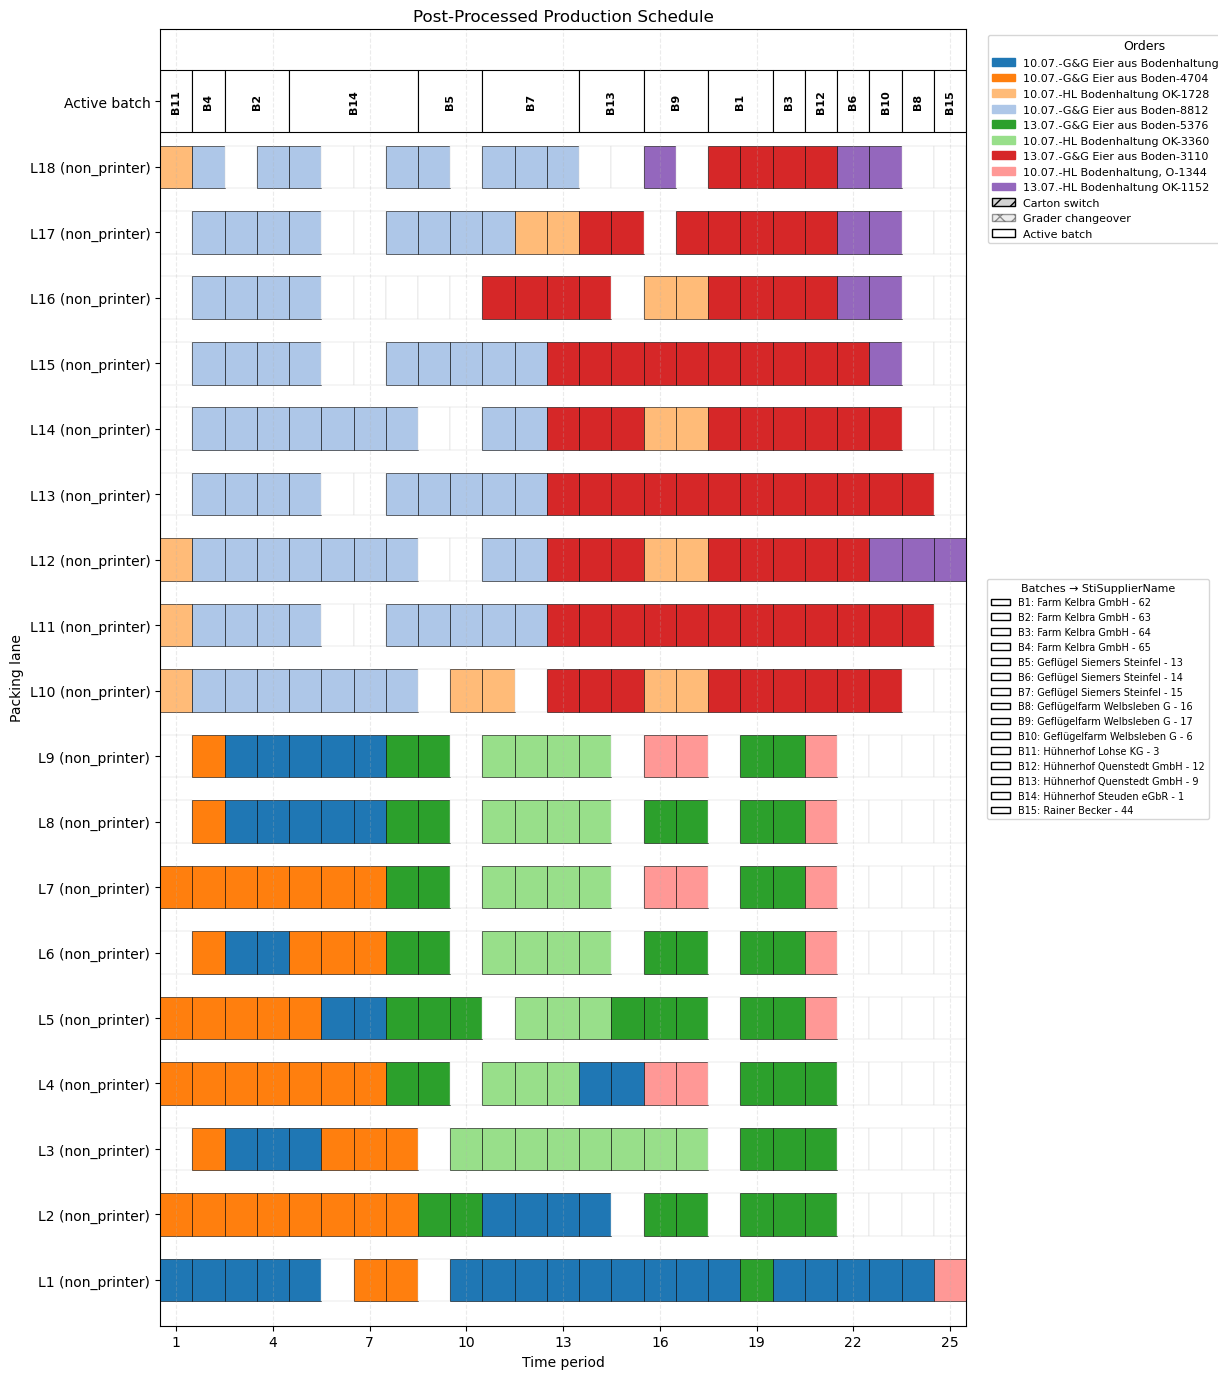


Created visualization objects:
  v2ls_polished_schedule_for_plot
  v2ls_order_colors


In [25]:
# ============================================================
# Visualization for V2 local-search polished schedule
# ============================================================
# Uses:
# - v2_local_lane_schedule
#
# Important:
# - This does NOT reconstruct the schedule again.
# - It directly plots the locally improved V2 lane-level schedule.
# - Do not run older reconstruction cells after this, or they may overwrite results.
# ============================================================

import os
import math
import copy
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    from matplotlib import colormaps
    TAB_CMAP = colormaps["tab20"]
except Exception:
    TAB_CMAP = plt.get_cmap("tab20")


# ============================================================
# Settings
# ============================================================

V2LS_VIS_EPS = 1e-6

SAVE_V2LS_VISUALIZATION = False
V2LS_VISUALIZATION_PATH = "Figures/1. Images/v2_local_search_schedule.png"

V2LS_VIS_TITLE = "Post-Processed Production Schedule"


# ============================================================
# Basic checks
# ============================================================

if "v2_local_lane_schedule" not in globals():
    raise RuntimeError(
        "v2_local_lane_schedule not found. "
        "Run the V2 local-search polishing cell first."
    )

required_objects = ["L", "T", "B", "G", "a_order"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise RuntimeError(f"Missing required objects: {missing_objects}")

print("\n" + "=" * 100)
print("V2 LOCAL-SEARCH POLISHED SCHEDULE VISUALIZATION")
print("=" * 100)
print("Plotting v2_local_lane_schedule directly.")
print("No additional reconstruction is performed.")


# ============================================================
# Helper functions
# ============================================================

def v2lsp_value_or_zero(value):
    if isinstance(value, (int, float)):
        return float(value)
    try:
        return float(value.X)
    except Exception:
        return 0.0


def v2lsp_lane_number(l):
    digits = "".join(ch for ch in str(l) if ch.isdigit())
    return int(digits) if digits else 999999


def v2lsp_order_number(o):
    digits = "".join(ch for ch in str(o) if ch.isdigit())
    return int(digits) if digits else 999999


def v2lsp_batch_number(b):
    digits = "".join(ch for ch in str(b) if ch.isdigit())
    return int(digits) if digits else 999999


def v2lsp_get_group_of_lane(l):
    if "L_g" in globals():
        for g, lanes_g in L_g.items():
            if l in lanes_g:
                return g

    if "lanes_by_group" in globals():
        for g, lanes_g in lanes_by_group.items():
            if l in lanes_g:
                return g

    if "lane_groups" in globals():
        for g, lanes_g in lane_groups.items():
            if l in lanes_g:
                return g

    if "pi" in globals() and l in pi:
        if v2lsp_value_or_zero(pi[l]) == 1:
            return "printer"
        return "non_printer"

    if (l, min(T)) in v2_local_lane_schedule:
        return v2_local_lane_schedule[(l, min(T))].get("group", "unknown")

    return "unknown"


def v2lsp_get_active_batch_in_period(t):
    if "active_batch_by_t2" in globals():
        return active_batch_by_t2.get(t, None)

    if "active_batch_by_t" in globals():
        return active_batch_by_t.get(t, None)

    if "active_batch_by_t_v2ls" in globals():
        return active_batch_by_t_v2ls.get(t, None)

    if "active_batch_pp4" in globals():
        return active_batch_pp4.get(t, None)

    if "s" in globals():
        active_batches = [
            b for b in B
            if (b, t) in s and v2lsp_value_or_zero(s[(b, t)]) > 0.5
        ]

        if len(active_batches) == 1:
            return active_batches[0]

    return None


def v2lsp_get_z_grader_value(t):
    if "z_grader" in globals() and t in z_grader:
        return v2lsp_value_or_zero(z_grader[t])
    return 0.0


def v2lsp_get_limited_xticks(T_values, max_ticks=12):
    T_values = list(T_values)

    if len(T_values) <= max_ticks:
        return T_values

    step = math.ceil(len(T_values) / max_ticks)
    first_t = min(T_values)

    ticks = [
        t for t in T_values
        if (t - first_t) % step == 0
    ]

    if max(T_values) not in ticks:
        ticks.append(max(T_values))

    return ticks[:max_ticks] if len(ticks) > max_ticks else ticks


def v2lsp_get_order_legend_label(o):
    """
    Return readable order description.
    Falls back to order name if no metadata is available.
    """

    def valid_value(value):
        return value is not None and str(value).strip() != ""

    def get_description_from_metadata(order, metadata):
        if order in metadata:
            description = metadata[order].get("description", None)
            if valid_value(description):
                return str(description)
        return None

    if "order_metadata" in globals():
        description = get_description_from_metadata(o, order_metadata)
        if description is not None:
            return description

    for backup_name in [
        "order_metadata_before_order_combination",
        "old_order_metadata",
        "original_order_metadata",
    ]:
        if backup_name in globals():
            description = get_description_from_metadata(o, globals()[backup_name])
            if description is not None:
                return description

    if "orders_on_day" in globals():
        if (
            "modelOrder" in orders_on_day.columns
            and "description" in orders_on_day.columns
        ):
            matches = orders_on_day.loc[
                orders_on_day["modelOrder"] == o,
                "description"
            ]

            if len(matches) > 0:
                description = matches.iloc[0]
                if valid_value(description):
                    return str(description)

    if "&" in str(o):
        original_orders = str(o).split("&")
        descriptions = []

        for original_o in original_orders:
            label = v2lsp_get_order_legend_label(original_o)

            if label != original_o:
                descriptions.append(label)

        descriptions = list(dict.fromkeys(descriptions))

        if len(descriptions) > 0:
            return " + ".join(descriptions)

    return str(o)


def v2lsp_get_batch_supplier_label(b):
    """
    Return supplier label for batch legend.
    Falls back to unknown supplier if metadata is unavailable.
    """

    if "batch_metadata" in globals() and b in batch_metadata:
        for key in [
            "RawSupplierName",
            "StiSupplierName",
            "StiSupplierNames",
            "RawSupplierNames",
            "SupplierName",
        ]:
            value = batch_metadata[b].get(key, None)

            if value is not None and str(value).strip() != "":
                return str(value)

    return "Unknown supplier"


def v2lsp_count_lane_order_switches(schedule, periods):
    total_switches = 0
    same_carton_switches = 0
    different_carton_switches = 0

    for l in L:
        previous_order = None

        for t in sorted(periods):
            current_order = schedule[(l, t)]["order"]

            if (
                previous_order is not None
                and current_order is not None
                and current_order != previous_order
            ):
                total_switches += 1

                if (
                    previous_order in a_order
                    and current_order in a_order
                    and a_order[previous_order] == a_order[current_order]
                ):
                    same_carton_switches += 1
                else:
                    different_carton_switches += 1

            previous_order = current_order

    return total_switches, same_carton_switches, different_carton_switches


def v2lsp_count_lane_runs(schedule, periods):
    total_runs = 0
    one_period_runs = 0
    run_lengths = []

    for l in L:
        current_order = None
        current_len = 0

        for t in sorted(periods):
            o = schedule[(l, t)]["order"]

            if o is not None and o == current_order:
                current_len += 1
            else:
                if current_order is not None:
                    total_runs += 1
                    run_lengths.append(current_len)

                    if current_len == 1:
                        one_period_runs += 1

                current_order = o
                current_len = 1 if o is not None else 0

        if current_order is not None:
            total_runs += 1
            run_lengths.append(current_len)

            if current_len == 1:
                one_period_runs += 1

    avg_run_length = (
        sum(run_lengths) / len(run_lengths)
        if len(run_lengths) > 0
        else 0.0
    )

    return total_runs, one_period_runs, avg_run_length


# ============================================================
# Optional expansion of combined model orders
# ============================================================

def v2lsp_expand_combined_orders_for_visualization(lane_schedule):
    """
    Expands combined model orders into original visible order labels if
    new_to_old_orders exists.

    This only changes a plotting copy.
    It does not change v2_local_lane_schedule.
    """

    expanded_schedule = copy.deepcopy(lane_schedule)

    if "new_to_old_orders" not in globals():
        print("No combined-order mapping found. Order labels are unchanged.")
        return expanded_schedule

    has_original_demands = "D_before_order_combination" in globals()
    expanded_count = 0

    for model_o, original_orders in new_to_old_orders.items():
        if len(original_orders) == 1:
            continue

        cells_for_model_order = []

        for (l, t), cell in expanded_schedule.items():
            if cell["order"] == model_o:
                cells_for_model_order.append((l, t, cell))

        if len(cells_for_model_order) == 0:
            continue

        cells_for_model_order = sorted(
            cells_for_model_order,
            key=lambda item: (item[1], v2lsp_lane_number(item[0]))
        )

        total_visual_qty = sum(
            cell.get("qty", 0.0)
            for _, _, cell in cells_for_model_order
        )

        if has_original_demands:
            target_qty_by_original_order = {
                original_o: D_before_order_combination[original_o]
                for original_o in original_orders
            }
        else:
            equal_target = total_visual_qty / len(original_orders)
            target_qty_by_original_order = {
                original_o: equal_target
                for original_o in original_orders
            }

        current_original_index = 0
        produced_for_current_original = 0.0

        for l, t, cell in cells_for_model_order:
            current_original_o = original_orders[current_original_index]
            current_target = target_qty_by_original_order[current_original_o]

            cell["modelOrder"] = model_o
            cell["order"] = current_original_o

            produced_for_current_original += cell.get("qty", 0.0)

            if (
                produced_for_current_original >= current_target
                and current_original_index < len(original_orders) - 1
            ):
                current_original_index += 1
                produced_for_current_original = 0.0

        expanded_count += 1

        print(
            f"Expanded {model_o} into {original_orders} "
            f"for visualization | visual qty = {total_visual_qty:,.0f}"
        )

    if expanded_count == 0:
        print("No combined orders needed expansion in the visible local-search schedule.")

    return expanded_schedule


# ============================================================
# Prepare schedule to plot
# ============================================================

v2ls_polished_schedule_for_plot = copy.deepcopy(v2_local_lane_schedule)

active_periods_in_v2ls_visual = [
    t
    for (l, t), cell in v2ls_polished_schedule_for_plot.items()
    if cell["order"] is not None
]

if len(active_periods_in_v2ls_visual) == 0:
    raise ValueError("No active production periods found in v2_local_lane_schedule.")

v2ls_visual_makespan = max(active_periods_in_v2ls_visual)

T_v2ls_vis = [
    t for t in T
    if t <= v2ls_visual_makespan
]

print("\nVisualization horizon:")
print(f"  Full model horizon:       {min(T)} to {max(T)}")
print(f"  Visual horizon:           {min(T_v2ls_vis)} to {max(T_v2ls_vis)}")
print(f"  Visual makespan:          {v2ls_visual_makespan}")


# ============================================================
# Diagnostics
# ============================================================

visible_active_cells = sum(
    1
    for (l, t), cell in v2ls_polished_schedule_for_plot.items()
    if t in T_v2ls_vis and cell["order"] is not None
)

visible_carton_switch_markers = sum(
    1
    for (l, t), cell in v2ls_polished_schedule_for_plot.items()
    if t in T_v2ls_vis and cell.get("carton_switch_boundary", False)
)

visible_grader_changeover_periods = [
    t for t in T_v2ls_vis
    if v2lsp_get_z_grader_value(t) > 0.5
]

(
    visible_order_switches,
    visible_same_carton_order_switches,
    visible_different_carton_order_switches,
) = v2lsp_count_lane_order_switches(
    v2ls_polished_schedule_for_plot,
    T_v2ls_vis
)

(
    visible_lane_runs,
    visible_one_period_lane_runs,
    visible_avg_lane_run,
) = v2lsp_count_lane_runs(
    v2ls_polished_schedule_for_plot,
    T_v2ls_vis
)

print("\nLocal-search visualization diagnostics:")
print(f"  Visible active lane-period cells:        {visible_active_cells:,}")
print(f"  Visible order switches on lanes:         {visible_order_switches:,}")
print(f"  Same-carton order switches:              {visible_same_carton_order_switches:,}")
print(f"  Different-carton order switches:         {visible_different_carton_order_switches:,}")
print(f"  Visible lane order runs:                 {visible_lane_runs:,}")
print(f"  Visible one-period lane runs:            {visible_one_period_lane_runs:,}")
print(f"  Average lane run length:                 {visible_avg_lane_run:.2f}")
print(f"  Visible carton-switch markers:           {visible_carton_switch_markers:,}")
print(f"  Visible grader changeover periods:       {len(visible_grader_changeover_periods):,}")

if len(visible_grader_changeover_periods) > 0:
    print(f"  Grader changeover periods:               {visible_grader_changeover_periods}")


# ============================================================
# Batch runs for active-batch row
# ============================================================

def v2lsp_get_batch_runs(T_vis):
    runs = []

    current_batch = None
    run_start = None

    for t in T_vis:
        b = v2lsp_get_active_batch_in_period(t)

        if b != current_batch:
            if current_batch is not None:
                runs.append((current_batch, run_start, t - 1))

            current_batch = b
            run_start = t if b is not None else None

    if current_batch is not None:
        runs.append((current_batch, run_start, max(T_vis)))

    return runs


# ============================================================
# Create colors for visible orders
# ============================================================

visible_orders = list(
    dict.fromkeys(
        cell["order"]
        for (l, t), cell in sorted(
            v2ls_polished_schedule_for_plot.items(),
            key=lambda item: (item[0][1], v2lsp_lane_number(item[0][0]))
        )
        if cell["order"] is not None
    )
)

# Reuse existing order colors if available
if "order_colors" in globals():
    v2ls_order_colors = dict(order_colors)
else:
    v2ls_order_colors = {}

for i, o in enumerate(visible_orders):
    if o not in v2ls_order_colors:
        v2ls_order_colors[o] = TAB_CMAP(i % TAB_CMAP.N)

print(f"  Visible orders:                          {len(visible_orders):,}")


# ============================================================
# Plot
# ============================================================

L_sorted = sorted(L, key=v2lsp_lane_number)

fig, ax = plt.subplots(figsize=(18, 0.55 * len(L_sorted) + 4))

bar_height = 0.65

lane_positions = {
    l: i
    for i, l in enumerate(L_sorted)
}

batch_y_pos = len(L_sorted)
all_y_positions = list(lane_positions.values()) + [batch_y_pos]


# ------------------------------------------------------------
# Draw lane rows
# ------------------------------------------------------------

for l in L_sorted:
    y_pos = lane_positions[l]

    for t in T_v2ls_vis:
        cell = v2ls_polished_schedule_for_plot[(l, t)]
        o = cell["order"]

        if o is not None:
            ax.barh(
                y=y_pos,
                width=1,
                left=t - 0.5,
                height=bar_height,
                color=v2ls_order_colors[o],
                edgecolor="black",
                linewidth=0.4
            )
        else:
            ax.barh(
                y=y_pos,
                width=1,
                left=t - 0.5,
                height=bar_height,
                color="white",
                edgecolor="lightgrey",
                linewidth=0.3
            )

        if cell.get("carton_switch_boundary", False):
            ax.barh(
                y=y_pos,
                width=0.12,
                left=t - 0.56,
                height=bar_height,
                color="lightgrey",
                edgecolor="black",
                hatch="//",
                linewidth=0.6
            )


# ------------------------------------------------------------
# Draw active-batch row
# ------------------------------------------------------------

batch_runs = v2lsp_get_batch_runs(T_v2ls_vis)

batch_bar_height = 0.95
batch_fontsize = 8

for b, start_t, end_t in batch_runs:
    if start_t is None:
        continue

    width = end_t - start_t + 1
    left = start_t - 0.5
    center_x = left + width / 2

    batch_patch = ax.barh(
        y=batch_y_pos,
        width=width,
        left=left,
        height=batch_bar_height,
        color="white",
        edgecolor="black",
        linewidth=0.8
    )[0]

    batch_text = ax.text(
        x=center_x,
        y=batch_y_pos,
        s=b,
        ha="center",
        va="center",
        fontsize=batch_fontsize,
        fontweight="bold",
        rotation=90,
        rotation_mode="anchor",
        clip_on=True
    )

    batch_text.set_clip_path(batch_patch)


# ------------------------------------------------------------
# Add grader-level changeover markers
# ------------------------------------------------------------

for t in T_v2ls_vis:
    if v2lsp_get_z_grader_value(t) > 0.5:
        ax.axvspan(
            t - 0.5,
            t + 0.5,
            facecolor="lightgrey",
            edgecolor="black",
            alpha=0.25,
            hatch="xx",
            linewidth=0.0
        )


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_yticks(all_y_positions)

ax.set_yticklabels(
    [
        f"{l} ({v2lsp_get_group_of_lane(l)})"
        for l in L_sorted
    ]
    + ["Active batch"]
)

xticks = v2lsp_get_limited_xticks(T_v2ls_vis, max_ticks=12)
ax.set_xticks(xticks)

ax.set_xlabel("Time period")
ax.set_ylabel("Packing lane")
ax.set_title(V2LS_VIS_TITLE)

ax.set_xlim(min(T_v2ls_vis) - 0.5, max(T_v2ls_vis) + 0.5)
ax.set_ylim(-0.7, batch_y_pos + 1.1)

ax.grid(axis="x", linestyle="--", alpha=0.25)


# ------------------------------------------------------------
# Legend 1: Orders and markers
# ------------------------------------------------------------

order_patches = [
    mpatches.Patch(
        color=v2ls_order_colors[o],
        label=v2lsp_get_order_legend_label(o)
    )
    for o in visible_orders
]

carton_switch_patch = mpatches.Patch(
    facecolor="lightgrey",
    edgecolor="black",
    hatch="//",
    label="Carton switch"
)

grader_changeover_patch = mpatches.Patch(
    facecolor="lightgrey",
    edgecolor="black",
    hatch="xx",
    alpha=0.4,
    label="Grader changeover"
)

active_batch_patch = mpatches.Patch(
    facecolor="white",
    edgecolor="black",
    label="Active batch"
)

main_legend_handles = order_patches + [
    carton_switch_patch,
    grader_changeover_patch,
    active_batch_patch
]

main_legend = ax.legend(
    handles=main_legend_handles,
    title="Orders",
    bbox_to_anchor=(1.02, 1.00),
    loc="upper left",
    fontsize=8,
    title_fontsize=9
)

ax.add_artist(main_legend)


# ------------------------------------------------------------
# Legend 2: Batches to supplier name
# ------------------------------------------------------------

batch_legend_handles = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        label=f"{b}: {v2lsp_get_batch_supplier_label(b)}"
    )
    for b in sorted(B, key=v2lsp_batch_number)
]

ax.legend(
    handles=batch_legend_handles,
    title="Batches → StiSupplierName",
    bbox_to_anchor=(1.02, 0.58),
    loc="upper left",
    fontsize=7,
    title_fontsize=8
)


# ------------------------------------------------------------
# Save / show
# ------------------------------------------------------------

plt.tight_layout(rect=[0, 0, 0.74, 1])

if SAVE_V2LS_VISUALIZATION:
    os.makedirs(os.path.dirname(V2LS_VISUALIZATION_PATH), exist_ok=True)
    plt.savefig(
        V2LS_VISUALIZATION_PATH,
        dpi=300,
        bbox_inches="tight"
    )
    print(f"\nSaved V2 local-search visualization to: {V2LS_VISUALIZATION_PATH}")

plt.show()


# ============================================================
# Output objects
# ============================================================

print("\nCreated visualization objects:")
print("  v2ls_polished_schedule_for_plot")
print("  v2ls_order_colors")